## Load the Zip file and un zip
##### Contains preproccesed gauge and SWOT data

In [99]:
import zipfile
import os

# Define paths
zip_file_path = '/work/nv25/Adnan/OFM/SPL_OFM/prior_learning/river_data/Results_iv.zip'  
extract_path = '/work/nv25/Adnan/OFM/SPL_OFM/prior_learning/river_data/data_extractedv2' 

# Create extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extracted files
print("Extracted files:", os.listdir(extract_path))


Extracted files: ['Results_iv', '__MACOSX']


# Load and Concatenate All merged.csv Files

In [3]:


# Define the root data folder Adnan/OFM/SPL_OFM/prior_learning/data_extracted/Results
data_folder = '/work/nv25/Adnan/OFM/SPL_OFM/prior_learning/river_data/data_extractedv2/Results_iv/'  # Adjust this path to your actual data directory
import pandas as pd
import glob
import os



# List to hold DataFrames
all_data = []

# Get list of state folders
state_folders = [f for f in os.listdir(data_folder) if os.path.isdir(os.path.join(data_folder, f))]

# Loop through each state folder
for state in state_folders:
    state_path = os.path.join(data_folder, state)
    # Find all files ending with 'merged.csv' in the state folder
    csv_files = glob.glob(os.path.join(state_path, '*merged.csv'))
    print(f"State {state}: Found {len(csv_files)} merged.csv files")
    
    # Load each CSV file
    for file_path in csv_files:
        try:
            df = pd.read_csv(file_path)
            # Optionally, add state column if not present
            if 'state' not in df.columns:
                df['state'] = state
            all_data.append(df)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Combine all data into one DataFrame
if all_data:
    data = pd.concat(all_data, ignore_index=True)
    print("Combined DataFrame shape:", data.shape)
    print("Columns:", data.columns.tolist())
else:
    raise FileNotFoundError("No valid merged.csv files found")

# Save combined data for inspection (optional)
data.to_csv('combined_data.csv', index=False)

State Texas: Found 63 merged.csv files
State Oklahoma: Found 49 merged.csv files
State Louisiana: Found 35 merged.csv files
Combined DataFrame shape: (11871, 52)
Columns: ['Unnamed: 0', 'datetime', 'tz_cd', 'swot_reach_id', 'latitude', 'longitude', 'swot_height_m', 'swot_height_u_m', 'swot_height_r_u', 'swot_width_m', 'swot_width_u_m', 'swot_slope', 'swot_slope_u', 'swot_slope_r_u', 'swot_slope2', 'swot_dark_frac', 'swot_n_good_nod', 'swot_reach_q_b', 'swot_xovr_cal_q', 'swot_xtrk_dist', 'ice_clim_f', 'data_quality', 'date_retrieved', 'swot_data_collection', 'sword_version', 'usgs_gage_link', 'river_name', 'site_no', '00065_cd', 'usgs_height_m', 'state', 'terrain_elevation_m', 'terrain_slope_deg', 'geoid', 'eht', 'oht', 'wse_corrected', 'inv_distance', 'lake_depth', 'lake_area', '00065_radar sensor_cd', '00065_primary sensor_cd', '00065_secondary sensor', '00065_secondary sensor_cd', '00065_15-minute update_cd', '00065_transducer_cd', '00065', '00065_bubbler_cd', '00065_2_cd', '00065_g

# Data Cleaning and Preprocessing

In [4]:
import numpy as np
# Check for missing values
print("Missing values:\n", data.isnull().sum())

# Drop rows where target is missing
data['usgs_height_m'] = data['usgs_height_m'].apply(lambda x: np.nan if x < -99 else x)
data = data.dropna(subset=['usgs_height_m'])


data['swot_height_m'] = data['swot_height_m'].apply(lambda x: np.nan if x < -99 else x)
data = data.dropna(subset=['swot_height_m'])
data["swot-terrain"]=data['swot_height_m']-data['terrain_elevation_m']


# Drop rivers with DAM or Lake nearby
DAM=['https://waterdata.usgs.gov/monitoring-location/07348000/',
    'https://waterdata.usgs.gov/monitoring-location/07347950/',
    'https://waterdata.usgs.gov/monitoring-location/07331290/',
    'https://waterdata.usgs.gov/monitoring-location/07185080/',
    'https://waterdata.usgs.gov/monitoring-location/08114100/']

data = data[~data['usgs_gage_link'].isin(DAM)]

print(f'Shape of data : {data.shape}')

# Fill missing predictor values with median for numerical columns
for col in data.columns:
    if col != 'usgs_height_m' and data[col].dtype in ['float64', 'int64']:
         data[col]=data[col].fillna(data[col].median())

# Define features and target
target = 'usgs_height_m'
exclude_cols = [target, 'usgs_flow_m3s', 'datetime', 'tz_cd', 'swot_reach_id',
                'date_retrieved', 'swot_data_collection', 'sword_version', 'usgs_gage_link', 'river_name', 'date','data_quality','ice_clim_f','state', '00065_radar sensor_cd', '00065_primary sensor_cd',
       '00065_secondary sensor', '00065_secondary sensor_cd',
       '00065_15-minute update_cd', '00065_transducer_cd', '00065',
       '00065_bubbler_cd', '00065_2_cd', '00065_gght.primary_cd',
       '00065_rq-30', '00065_rq-30_cd','Unnamed: 0','latitude','longitude','site_no']

features = [col for col in data.columns if col not in exclude_cols]
numerical_features = [col for col in features if col != 'state' and data[col].dtype in ['float64', 'int64']]
#categorical_features = ['state']


# Check categorical features
print("Ice_clim_f unique values:", data['ice_clim_f'].value_counts())
print("Data_quality unique values:", data['data_quality'].value_counts())

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
    ])

# Prepare X and y
X = data[features]
y = data[target]

Missing values:
 Unnamed: 0                       0
datetime                         0
tz_cd                            0
swot_reach_id                    0
latitude                         0
longitude                        0
swot_height_m                  165
swot_height_u_m                165
swot_height_r_u                165
swot_width_m                     0
swot_width_u_m                   0
swot_slope                     165
swot_slope_u                   165
swot_slope_r_u                 165
swot_slope2                    165
swot_dark_frac                   0
swot_n_good_nod                  0
swot_reach_q_b                   0
swot_xovr_cal_q                  0
swot_xtrk_dist                   2
ice_clim_f                       0
data_quality                     0
date_retrieved                   0
swot_data_collection             0
sword_version                    0
usgs_gage_link                   0
river_name                   11871
site_no                        863
000

/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [52]:
X_test_preprocessed.shape

(1047, 24)

#### import xgboost
print(xgboost.__version__)


Epoch 1, Validation Loss: 29.9125
Epoch 2, Validation Loss: 28.4579
Epoch 3, Validation Loss: 26.0270
Epoch 4, Validation Loss: 23.6248
Epoch 5, Validation Loss: 21.4436
Epoch 6, Validation Loss: 18.7724
Epoch 7, Validation Loss: 16.1506
Epoch 8, Validation Loss: 14.6573
Epoch 9, Validation Loss: 11.2571
Epoch 10, Validation Loss: 9.9532
Epoch 11, Validation Loss: 8.8547
Epoch 12, Validation Loss: 8.4093
Epoch 13, Validation Loss: 6.5662
Epoch 14, Validation Loss: 5.3704
Epoch 15, Validation Loss: 5.3696

Model Performance:
Linear Regression: MSE = 31.1421, MAE = 3.1963, R² = 0.1638
Random Forest: MSE = 0.5109, MAE = 0.3270, R² = 0.9863
Gradient Boosting: MSE = 2.1002, MAE = 0.8787, R² = 0.9436
Neural Network (PyTorch): MSE = 7.1872, MAE = 1.5587, R² = 0.8070

Best model (lowest MSE): Random Forest


/tmp/ipykernel_131/2638397270.py:145: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('random_best_model.pt'))


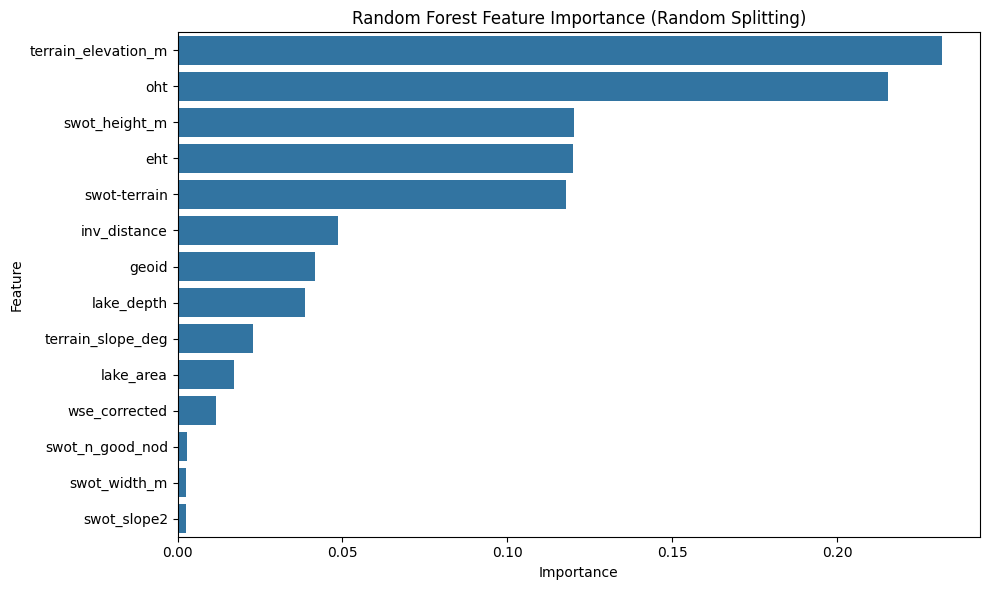

Feature Importance:
                Feature  Importance
14  terrain_elevation_m    0.231797
18                  oht    0.215539
0         swot_height_m    0.120121
17                  eht    0.119844
23         swot-terrain    0.117892
20         inv_distance    0.048554
16                geoid    0.041576
21           lake_depth    0.038543
15    terrain_slope_deg    0.022878
22            lake_area    0.016942
19        wse_corrected    0.011563
10      swot_n_good_nod    0.002740
3          swot_width_m    0.002654
8           swot_slope2    0.002443
Feature Importance:
                Feature  Importance
14  terrain_elevation_m    0.231797
18                  oht    0.215539
0         swot_height_m    0.120121
17                  eht    0.119844
23         swot-terrain    0.117892
20         inv_distance    0.048554
16                geoid    0.041576
21           lake_depth    0.038543
15    terrain_slope_deg    0.022878
22            lake_area    0.016942
19        wse_corrected 

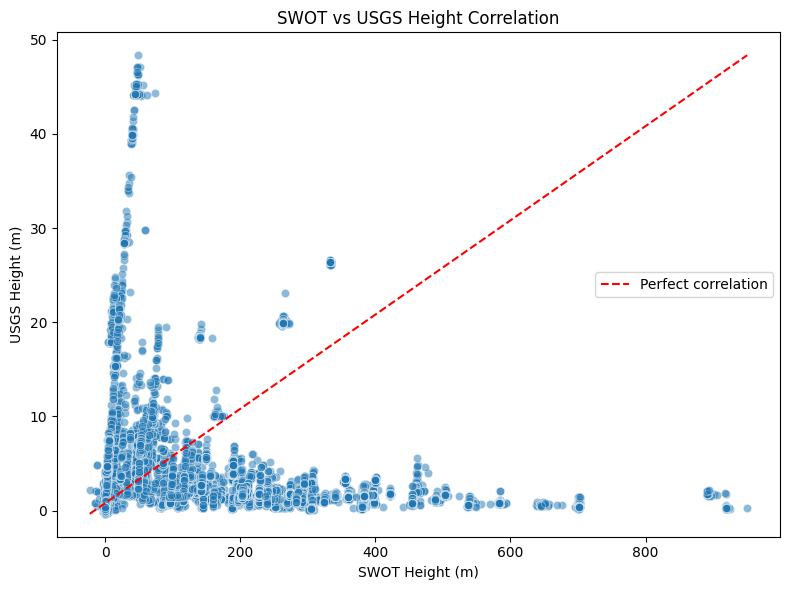

Pearson correlation between swot_height_m-terrain and usgs_height_m: -0.1675

Best model (lowest MAE): Random Forest
Percentage of test cases error under 20 cm (SWOT nominal accuracy) is 62.1%


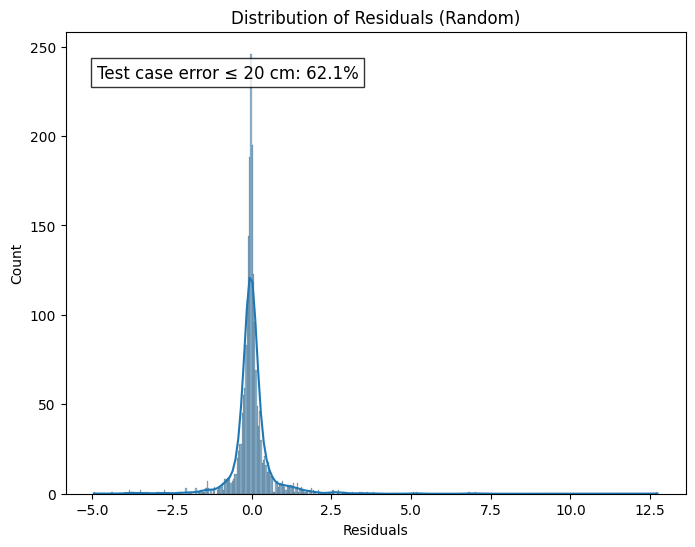

Pearson correlation between swot_height_m-terrain and usgs_height_m: -0.1675


In [5]:
from sklearn.model_selection import train_test_split
import seaborn as sns
import os
import zipfile
import pandas as pd
import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset




X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Convert data to numpy arrays for PyTorch
X_train_np = X_train_preprocessed
X_test_np = X_test_preprocessed
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

# Step 7: Define PyTorch Neural Network
class Net(nn.Module):
    def __init__(self, input_size):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x


# Step 7: Try multiple models
results = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_preprocessed, y_train)
y_pred_lr = lr.predict(X_test_preprocessed)
results['Linear Regression'] = {
    'MSE': mean_squared_error(y_test, y_pred_lr),
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'R2': r2_score(y_test, y_pred_lr)
}

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_preprocessed, y_train)
y_pred_rf = rf.predict(X_test_preprocessed)
results['Random Forest'] = {
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf)
}

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train_preprocessed, y_train)
y_pred_gb = gb.predict(X_test_preprocessed)
results['Gradient Boosting'] = {
    'MSE': mean_squared_error(y_test, y_pred_gb),
    'MAE': mean_absolute_error(y_test, y_pred_gb),
    'R2': r2_score(y_test, y_pred_gb)
}



# PyTorch Neural Network
# Convert data to tensors
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32).reshape(-1, 1)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).reshape(-1, 1)


# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


# Initialize model, loss, optimizer
model = Net(input_size=X_train_np.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Training loop with early stopping
epochs = 15
patience = 10
best_val_loss = float('inf')
patience_counter = 0
val_split = 0.2
n_val = int(len(X_train_tensor) * val_split)
X_train_sub, X_val = X_train_tensor[n_val:], X_train_tensor[:n_val]
y_train_sub, y_val = y_train_tensor[n_val:], y_train_tensor[:n_val]


for epoch in range(epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    
    # Validation loss
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
    
    print(f"Epoch {epoch+1}, Validation Loss: {val_loss.item():.4f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'random_best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

# Load best model
model.load_state_dict(torch.load('random_best_model.pt'))
model.eval()
with torch.no_grad():
    y_pred_nn = model(X_test_tensor).numpy().flatten()
results['Neural Network (PyTorch)'] = {
    'MSE': mean_squared_error(y_test_np, y_pred_nn),
    'MAE': mean_absolute_error(y_test_np, y_pred_nn),
    'R2': r2_score(y_test_np, y_pred_nn)
}

# Display results
print("\nModel Performance:")
for model, metrics in results.items():
    print(f"{model}: MSE = {metrics['MSE']:.4f}, MAE = {metrics['MAE']:.4f}, R² = {metrics['R2']:.4f}")

# Step 9: Explainability for the best model (lowest MSE)
best_model_name = min(results, key=lambda x: results[x]['MSE'])
print(f"\nBest model (lowest MSE): {best_model_name}")
best_model = {'Linear Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb,  'Neural Network (PyTorch)': model}[best_model_name]


# Feature Importance
num_feature_names = numerical_features
#cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(num_feature_names) #+ list(cat_feature_names)

if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)[:14]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
    plt.title(f'{best_model_name} Feature Importance (Random Splitting)')
    plt.tight_layout()
    plt.show()
    
elif best_model_name == 'Linear Regression':
    coefs = best_model.coef_
    feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefs})
    feature_importance_df['Abs_Coefficient'] = feature_importance_df['Coefficient'].abs()
    feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Abs_Coefficient', y='Feature', data=feature_importance_df)
    plt.title('Linear Regression Absolute Coefficients')
    plt.tight_layout()
    plt.show()
else:  # Neural Network
    print("Feature importance not directly available for Neural Network. Consider SHAP for detailed analysis.")

if best_model_name != 'Neural Network (PyTorch)':
    print("Feature Importance:")
    print(feature_importance_df)

print("Feature Importance:")
print(feature_importance_df)



# Step 9: Correlation Analysis (swot_height_m vs usgs_height_m)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['swot_height_m'], y=data['usgs_height_m'], alpha=0.5)
plt.plot([data['swot_height_m'].min(), data['swot_height_m'].max()], 
         [data['usgs_height_m'].min(), data['usgs_height_m'].max()], 'r--', label='Perfect correlation')
plt.xlabel('SWOT Height (m)')
plt.ylabel('USGS Height (m)')
plt.title('SWOT vs USGS Height Correlation')
plt.legend()
plt.tight_layout()
plt.show()

correlation = data['swot-terrain'].corr(data['usgs_height_m'])
print(f"Pearson correlation between swot_height_m-terrain and usgs_height_m: {correlation:.4f}")



# Best model (lowest MAE)
best_model_name = min(results, key=lambda x: results[x]['MAE'])
print(f"\nBest model (lowest MAE): {best_model_name}")
best_model = {'Linear Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}[best_model_name]
y_pred_best = {'Linear Regression': y_pred_lr, 'Random Forest': y_pred_rf, 'Gradient Boosting': y_pred_gb}[best_model_name]


# 3. Error Distribution
residuals = y_test - y_pred_best
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.title('Distribution of Residuals (Random)')

# Calculate percentage
error_percentage = round(100 * sum(abs(residuals) <= 0.2) / len(residuals), 2)

# Add text inside the graph (adjust x, y coordinates as needed)
plt.text(x=0.05, y=0.9, s=f'Test case error ≤ 20 cm: {error_percentage}%', 
         transform=plt.gca().transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

print(f'Percentage of test cases error under 20 cm (SWOT nominal accuracy) is {error_percentage}%')
plt.savefig('random_error_distribution.png')
plt.show()


correlation = data['swot-terrain'].corr(data['usgs_height_m'])
print(f"Pearson correlation between swot_height_m-terrain and usgs_height_m: {correlation:.4f}")



Best model (lowest MAE): Random Forest
Percentage of test cases error under 20 cm (SWOT nominal accuracy) is 62.1%


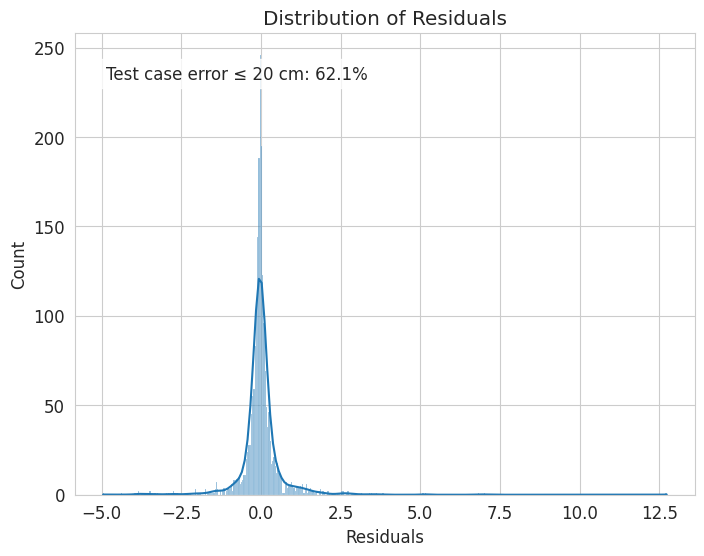

In [101]:
# Best model (lowest MAE)
best_model_name = min(results, key=lambda x: results[x]['MAE'])
print(f"\nBest model (lowest MAE): {best_model_name}")
best_model = {'Linear Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}[best_model_name]
y_pred_best = {'Linear Regression': y_pred_lr, 'Random Forest': y_pred_rf, 'Gradient Boosting': y_pred_gb}[best_model_name]

# 3. Error Distribution
residuals = y_test - y_pred_best
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.title('Distribution of Residuals')

# Calculate percentage
error_percentage = round(100 * sum(abs(residuals) <= 0.2) / len(residuals), 2)

# Add text inside the graph (adjust x, y coordinates as needed)
plt.text(x=0.05, y=0.9, s=f'Test case error ≤ 20 cm: {error_percentage}%', 
         transform=plt.gca().transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

print(f'Percentage of test cases error under 20 cm (SWOT nominal accuracy) is {error_percentage}%')
plt.savefig('error_distribution.png')
plt.show()

In [12]:
import pandas as pd
import numpy as np
import os
import pickle
import torch
from sklearn.compose import ColumnTransformer
from datetime import datetime

# Create directories for saving models and datasets
output_dir = 'experiment_results'
os.makedirs(os.path.join(output_dir, 'models'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'datasets'), exist_ok=True)

# Initialize global DataFrames to store results across all test setups
if 'performance_df' not in globals():
    performance_df = pd.DataFrame(columns=['split_type', 'fold', 'model', 'MSE', 'MAE', 'R2', 'model_path'])
if 'residuals_df' not in globals():
    residuals_df = pd.DataFrame(columns=['split_type', 'fold', 'residual', 'test_data_path'])
if 'feature_importance_df' not in globals():
    feature_importance_df = pd.DataFrame(columns=['split_type', 'fold', 'feature', 'importance'])


def save_results(split_type, results, X_train, X_test, y_train, y_test, y_pred_best, best_model_name, best_model, models, preprocessor, fold=None):
    """
    Save results, models, and train/test splits from a test setup.
    
    Parameters:
    - split_type: str, type of split ('random', 'river', 'time', 'state_loo')
    - results: dict, model performance metrics
    - X_train, X_test: DataFrame or array, raw train/test features
    - y_train, y_test: Series or array, train/test target
    - y_pred_best: array-like, predictions from the best model
    - best_model_name: str, name of the best model
    - best_model: trained model object
    - models: dict, all trained models {'model_name': model_object}
    - preprocessor: fitted ColumnTransformer object
    - fold: str or None, fold identifier (e.g., state name for state_loo)
    """
    global performance_df, residuals_df, feature_importance_df
    
    # Generate a timestamp for unique file naming
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # 1. Save train/test splits
    fold_str = f'_fold_{fold}' if fold else ''
    train_data_path = os.path.join(output_dir, 'datasets', f'{split_type}{fold_str}_train_{timestamp}.csv')
    test_data_path = os.path.join(output_dir, 'datasets', f'{split_type}{fold_str}_test_{timestamp}.csv')
    
    # Combine features and target into DataFrames
    train_df = pd.concat([pd.DataFrame(X_train, columns=X_train.columns), pd.Series(y_train, name='target')], axis=1)
    test_df = pd.concat([pd.DataFrame(X_test, columns=X_test.columns), pd.Series(y_test, name='target')], axis=1)
    
    # Save to CSV
    train_df.to_csv(train_data_path, index=False)
    test_df.to_csv(test_data_path, index=False)
    
    # 2. Save models
    model_paths = {}
    for model_name, model in models.items():
        model_filename = f'{split_type}{fold_str}_{model_name.replace(" ", "_")}_{timestamp}.pkl'
        model_path = os.path.join(output_dir, 'models', model_filename)
        
        if model_name == 'Neural Network (PyTorch)':
            # Save PyTorch model
            torch.save(model.state_dict(), model_path)
        else:
            # Save scikit-learn models
            with open(model_path, 'wb') as f:
                pickle.dump(model, f)
        model_paths[model_name] = model_path
    
    # 3. Save performance metrics
    perf_records = []
    for model, metrics in results.items():
        perf_records.append({
            'split_type': split_type,
            'fold': fold if split_type == 'state_loo' else None,
            'model': model,
            'MSE': metrics['MSE'],
            'MAE': metrics['MAE'],
            'R2': metrics['R2'],
            'model_path':None if model== 'Neural Network (PyTorch)' else model_paths[model]
        })
    performance_df = pd.concat([performance_df, pd.DataFrame(perf_records)], ignore_index=True)
    
    # 4. Save residuals for the best model
    residuals = y_test - y_pred_best
    res_df = pd.DataFrame({
        'split_type': split_type,
        'fold': fold if split_type == 'state_loo' else None,
        'residual': residuals,
        'test_data_path': test_data_path
    })

    
    residuals_df = pd.concat([residuals_df, res_df], ignore_index=True)
    
    # 5. Save feature importance for the best model
    # Get feature names from preprocessor
    numerical_features = preprocessor.transformers_[0][2]  # Assuming num features are first
    #categorical_transformer = preprocessor.named_transformers_['cat']
    #cat_feature_names = categorical_transformer.get_feature_names_out()
    all_feature_names = list(numerical_features) #+ list(cat_feature_names)
    
    if best_model_name in ['Random Forest', 'Gradient Boosting']:
        importances = best_model.feature_importances_
        fi_df = pd.DataFrame({
            'split_type': split_type,
            'fold': fold if split_type == 'state_loo' else None,
            'feature': all_feature_names,
            'importance': importances
        })
    elif best_model_name == 'Linear Regression':
        coefs = best_model.coef_
        fi_df = pd.DataFrame({
            'split_type': split_type,
            'fold': fold if split_type == 'state_loo' else None,
            'feature': all_feature_names,
            'importance': np.abs(coefs)  # Use absolute coefficients
        })
    elif best_model_name == 'Neural Network (PyTorch)':
        fi_df = pd.DataFrame({
            'split_type': split_type,
            'fold': fold if split_type == 'state_loo' else None,
            'feature': ['N/A'],
            'importance': [0]
        })
    else:
        fi_df = pd.DataFrame()
    
    if not fi_df.empty:
        feature_importance_df = pd.concat([feature_importance_df, fi_df], ignore_index=True)


# Example usage:
# For random, river, or time splits:
models = {'Linear Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}

save_results('random', results, X_train, X_test, y_train, y_test, y_pred_best, best_model_name, best_model, models, preprocessor)


# For state_loo:
# for state in unique_states:
#     # Run training/testing
#     # Then call:
#     save_results('state_loo', results, X_train, X_test, y_train, y_test, y_pred_best, best_model_name, best_model, models, preprocessor, fold=state)

# Save all results to CSV files
def save_all_results_to_files():
    performance_df.to_csv(os.path.join(output_dir, 'performance_results.csv'), index=False)
    residuals_df.to_csv(os.path.join(output_dir, 'residuals_results.csv'), index=False)
    feature_importance_df.to_csv(os.path.join(output_dir, 'feature_importance_results.csv'), index=False)

# Call this at the end to save DataFrames
# save_all_results_to_files()

/tmp/ipykernel_290/1848555312.py:84: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  performance_df = pd.concat([performance_df, pd.DataFrame(perf_records)], ignore_index=True)
/tmp/ipykernel_290/1848555312.py:94: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  residuals_df = pd.concat([residuals_df, res_df], ignore_index=True)


In [89]:
performance_df
#residuals_df
#feature_importance_df

,split_type,fold,model,MSE,MAE,R2,model_path
0,random,None,Linear Regression,3.114214e+01,3.196292,1.637591e-01,experiment_results/models/random_Linear_Regres...
1,random,None,Random Forest,5.109419e-01,0.326964,9.862800e-01,experiment_results/models/random_Random_Forest...
2,random,None,Gradient Boosting,2.100203e+00,0.878720,9.436045e-01,experiment_results/models/random_Gradient_Boos...
3,random,None,Neural Network (PyTorch),2.921420e+01,3.111365,2.155288e-01,None
4,Time,None,Linear Regression,1.005051e+08,112.781694,-2.437515e+06,experiment_results/models/Time_Linear_Regressi...
5,Time,None,Random Forest,2.264469e+00,0.716263,9.450806e-01,experiment_results/models/Time_Random_Forest_2...
6,Time,None,Gradient Boosting,1.332149e+01,1.974289,6.769185e-01,experiment_results/models/Time_Gradient_Boosti...
7,Time,None,Linear Regression,1.005051e+08,112.781694,-2.437515e+06,experiment_results/models/Time_Linear_Regressi...
8,Time,None,Random Forest,2.264469e+00,0.716263,9.450806e-01,experiment_results/models/Time_Random_Forest_2...
9,Time,None,Gradient Boosting,1.332149e+01,1.974289,6.769185e-01,experiment_results/models/Time_Gradient_Boosti...


                Feature  Importance
14  terrain_elevation_m    0.231797
18                  oht    0.215539
0         swot_height_m    0.120121
17                  eht    0.119844
23         swot-terrain    0.117892
20         inv_distance    0.048554
16                geoid    0.041576
21           lake_depth    0.038543
15    terrain_slope_deg    0.022878
22            lake_area    0.016942
19        wse_corrected    0.011563
10      swot_n_good_nod    0.002740
3          swot_width_m    0.002654
8           swot_slope2    0.002443
5            swot_slope    0.001570
9        swot_dark_frac    0.000915
4        swot_width_u_m    0.000906
11       swot_reach_q_b    0.000847
13       swot_xtrk_dist    0.000698
6          swot_slope_u    0.000462
7        swot_slope_r_u    0.000448
2       swot_height_r_u    0.000413
12      swot_xovr_cal_q    0.000329
1       swot_height_u_m    0.000324


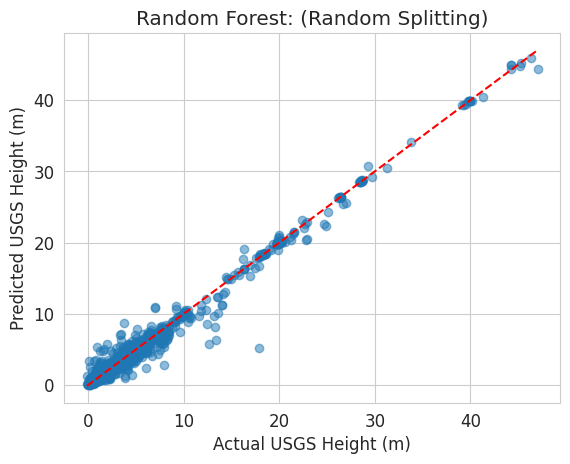

In [77]:
# Step 8: Feature importance and visualization
num_feature_names = numerical_features
#cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(num_feature_names) 
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
print(feature_importance_df.sort_values(by='Importance', ascending=False))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual USGS Height (m)')
plt.ylabel('Predicted USGS Height (m)')
plt.title('Random Forest: (Random Splitting)')
plt.savefig('predictedVsactual_random.png')
plt.show()

Gauge-Specific Performance:
                                                 Gauge       MSE  Correlation
54   https://waterdata.usgs.gov/monitoring-location...  0.002434     0.001860
92   https://waterdata.usgs.gov/monitoring-location...  0.003009     0.147921
65   https://waterdata.usgs.gov/monitoring-location...  0.003195     0.048423
93   https://waterdata.usgs.gov/monitoring-location...  0.003202     0.147840
40   https://waterdata.usgs.gov/monitoring-location...  0.003377    -0.125333
..                                                 ...       ...          ...
4    https://waterdata.usgs.gov/monitoring-location...  0.822432     0.553494
60   https://waterdata.usgs.gov/monitoring-location...  0.853790     0.359815
9    https://waterdata.usgs.gov/monitoring-location...  0.856101     0.796519
61   https://waterdata.usgs.gov/monitoring-location...  1.216120     0.645290
119  https://waterdata.usgs.gov/monitoring-location...  3.006976     0.615673

[142 rows x 3 columns]


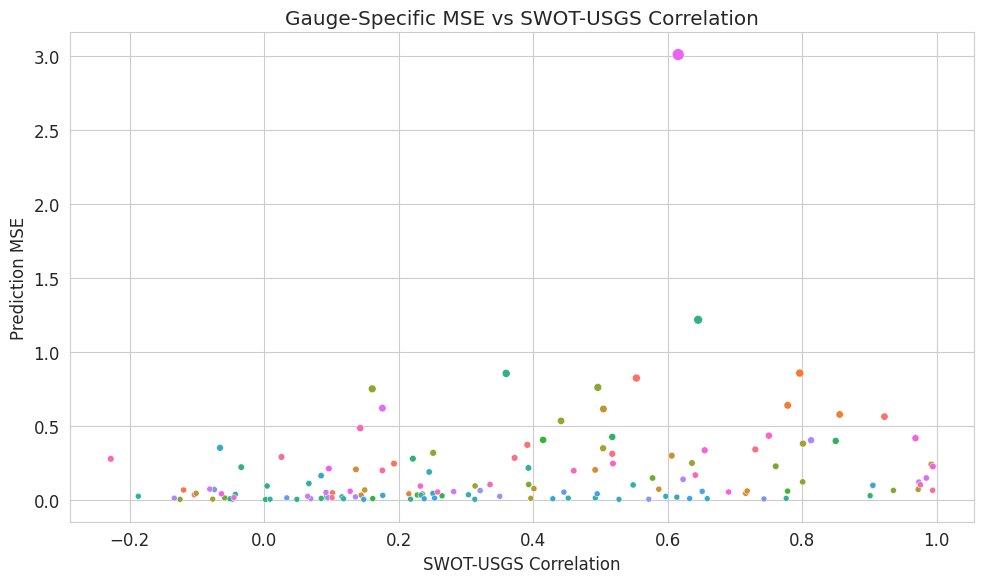

In [108]:
import seaborn as sns
# Assume gauges are identified by usgs_gage_link
if 'usgs_gage_link' in data.columns:
    gauge_errors = []
    for gauge in data['usgs_gage_link'].unique():
        mask = data['usgs_gage_link'] == gauge
        gauge_data = data[mask]
        X_gauge = gauge_data[features]
        y_gauge = gauge_data[target]
        if len(y_gauge) < 5:  # Skip small samples
            continue
        X_gauge_pre = preprocessor.transform(X_gauge)
        y_pred_gauge = rf.predict(X_gauge_pre)
        mse_gauge = mean_squared_error(y_gauge, y_pred_gauge)
        corr_gauge = gauge_data['swot_height_m'].corr(gauge_data['usgs_height_m'])
        gauge_errors.append({'Gauge': gauge, 'MSE': mse_gauge, 'Correlation': corr_gauge})
    
    gauge_df = pd.DataFrame(gauge_errors)
    print("Gauge-Specific Performance:")
    print(gauge_df.sort_values(by='MSE'))

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Correlation', y='MSE', size='MSE', hue='Gauge', data=gauge_df, legend=False)
    plt.title('Gauge-Specific MSE vs SWOT-USGS Correlation')
    plt.xlabel('SWOT-USGS Correlation')
    plt.ylabel('Prediction MSE')
    plt.tight_layout()
    plt.show()
else:
    print("No usgs_gage_link column found for gauge-specific analysis")

Gauge-Specific Performance:
                                                 Gauge       MAE  Correlation
54   https://waterdata.usgs.gov/monitoring-location...  0.021205     0.001860
64   https://waterdata.usgs.gov/monitoring-location...  0.028797     0.217542
93   https://waterdata.usgs.gov/monitoring-location...  0.028809     0.147840
33   https://waterdata.usgs.gov/monitoring-location...  0.029970    -0.076764
65   https://waterdata.usgs.gov/monitoring-location...  0.033057     0.048423
..                                                 ...       ...          ...
135  https://waterdata.usgs.gov/monitoring-location...  0.524710     0.142732
116  https://waterdata.usgs.gov/monitoring-location...  0.538162     0.175650
39   https://waterdata.usgs.gov/monitoring-location...  0.545510     0.496139
60   https://waterdata.usgs.gov/monitoring-location...  0.587458     0.359815
119  https://waterdata.usgs.gov/monitoring-location...  0.615272     0.615673

[142 rows x 3 columns]


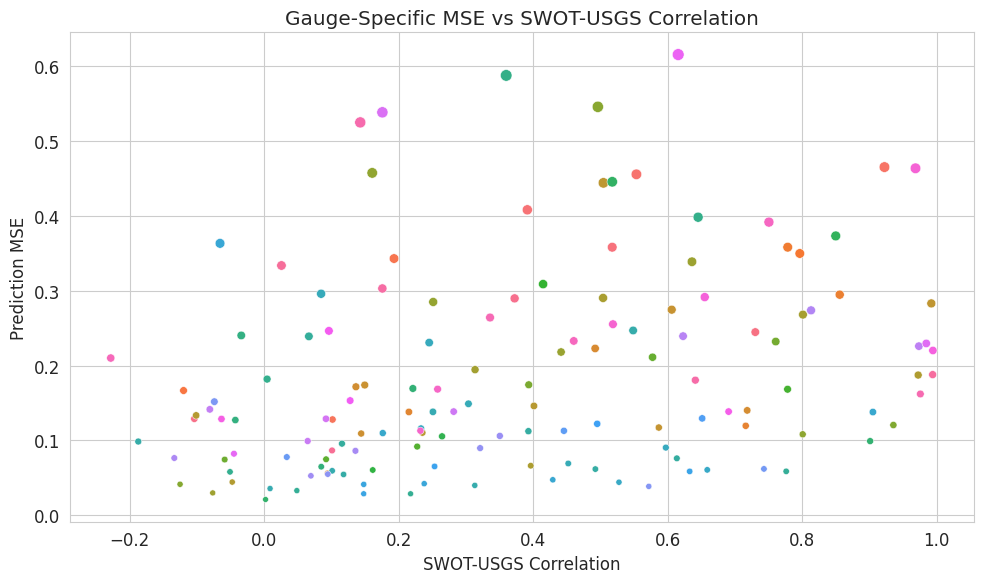

In [109]:
import seaborn as sns
# Assume gauges are identified by usgs_gage_link
if 'usgs_gage_link' in data.columns:
    gauge_errors = []
    for gauge in data['usgs_gage_link'].unique():
        mask = data['usgs_gage_link'] == gauge
        gauge_data = data[mask]
        X_gauge = gauge_data[features]
        y_gauge = gauge_data[target]
        if len(y_gauge) < 5:  # Skip small samples
            continue
        X_gauge_pre = preprocessor.transform(X_gauge)
        y_pred_gauge = rf.predict(X_gauge_pre)
        mse_gauge = mean_absolute_error(y_gauge, y_pred_gauge)
        corr_gauge = gauge_data['swot_height_m'].corr(gauge_data['usgs_height_m'])
        gauge_errors.append({'Gauge': gauge, 'MAE': mse_gauge, 'Correlation': corr_gauge})
    
    gauge_df = pd.DataFrame(gauge_errors)
    print("Gauge-Specific Performance:")
    print(gauge_df.sort_values(by='MAE'))

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Correlation', y='MAE', size='MAE', hue='Gauge', data=gauge_df, legend=False)
    plt.title('Gauge-Specific MSE vs SWOT-USGS Correlation')
    plt.xlabel('SWOT-USGS Correlation')
    plt.ylabel('Prediction MSE')
    plt.tight_layout()
    plt.show()
else:
    print("No usgs_gage_link column found for gauge-specific analysis")

## Split by reach

Fold 1
Early stopping triggered
Fold 2


/tmp/ipykernel_131/919821349.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_model_fold_{fold}.pt'))


Early stopping triggered
Fold 3


/tmp/ipykernel_131/919821349.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_model_fold_{fold}.pt'))


Early stopping triggered
Fold 4


...

/tmp/ipykernel_131/919821349.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_model_fold_{fold}.pt'))


Early stopping triggered
Fold 10


/tmp/ipykernel_131/919821349.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_model_fold_{fold}.pt'))


Early stopping triggered

Average Model Performance Across Folds:
Linear Regression: MSE = 53.2532, MAE = 3.7979, R² = -0.4989
Random Forest: MSE = 61.2465, MAE = 3.9529, R² = -0.9882
Gradient Boosting: MSE = 52.1495, MAE = 3.6414, R² = -0.6904
Neural Network (PyTorch): MSE = 74.3065, MAE = 3.7342, R² = -2.6370


/tmp/ipykernel_131/919821349.py:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_model_fold_{fold}.pt'))


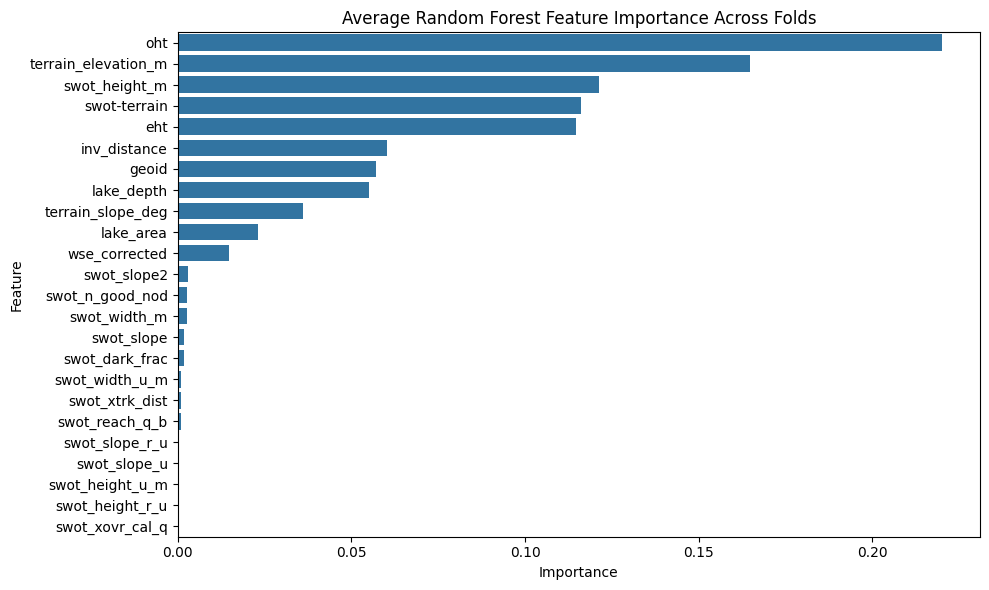

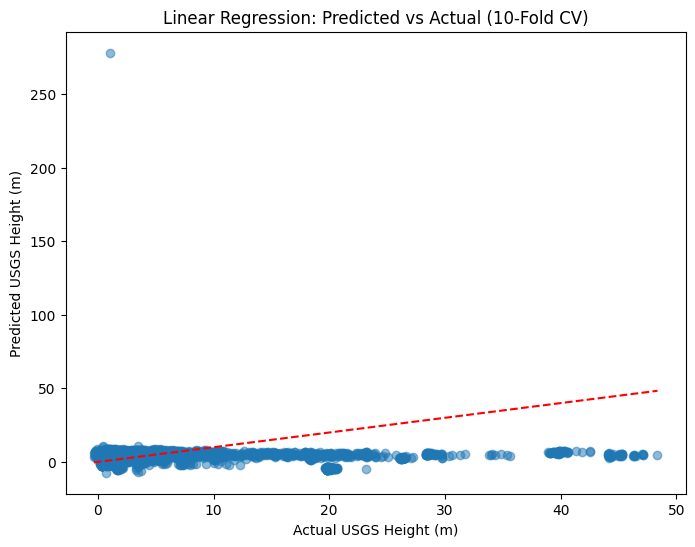

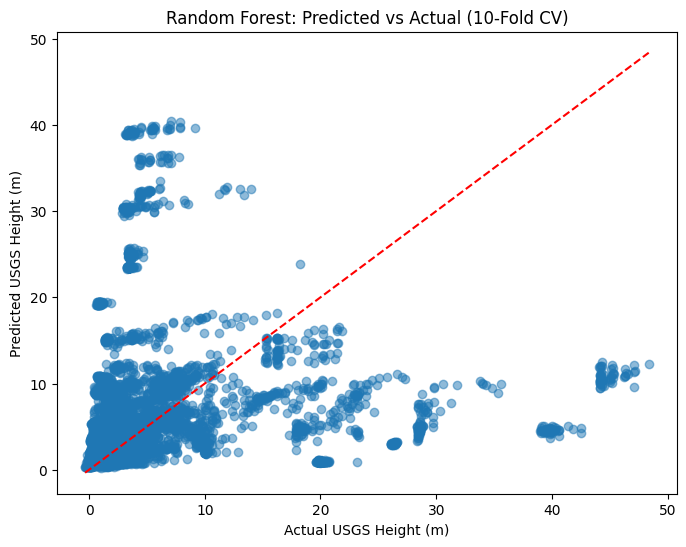

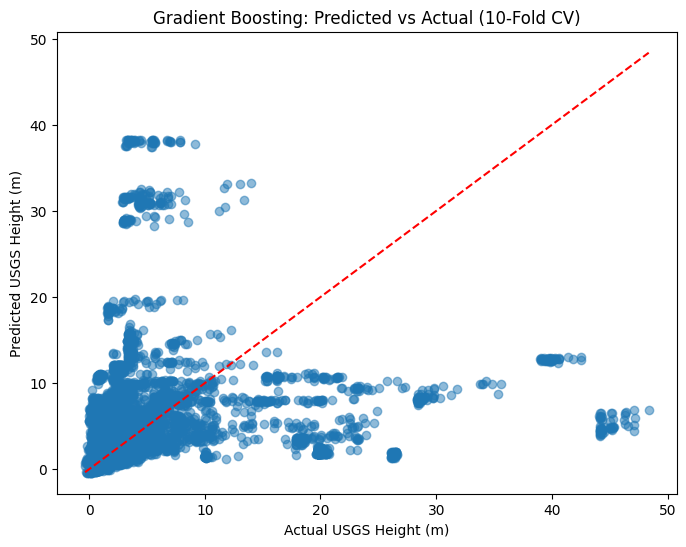

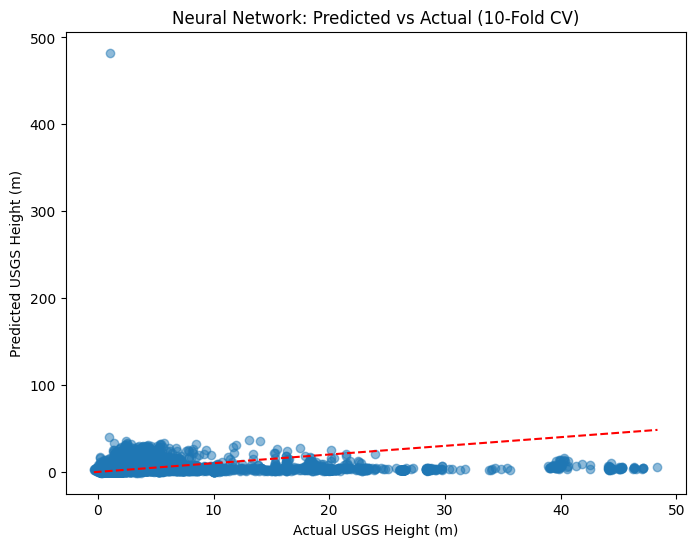

Percentage of test cases error under 20 cm (SWOT nominal accuracy) is 8.97%


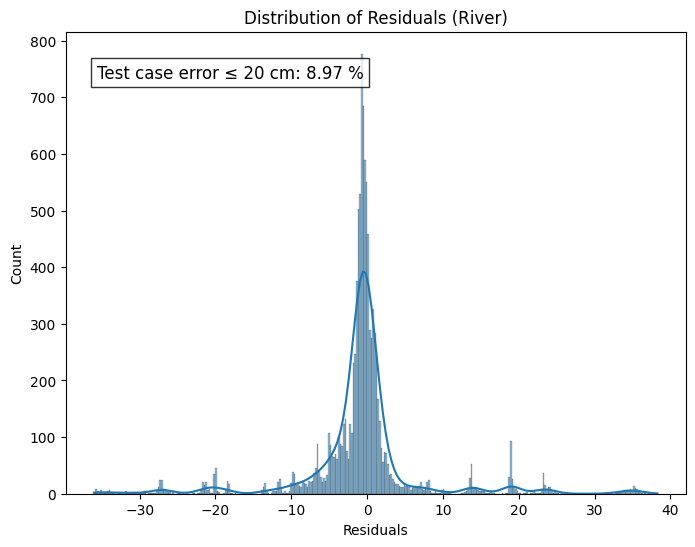

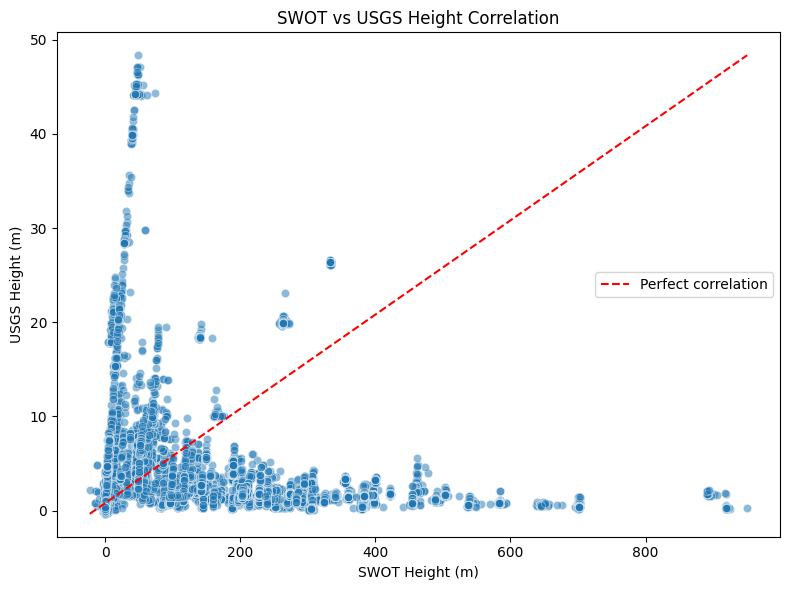

Pearson correlation between swot_height_m and usgs_height_m: -0.2530


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assuming X, y, data, preprocessor, numerical_features are defined elsewhere
# Replace with your actual data loading and preprocessing steps
# For example:
# data = pd.read_csv('your_data.csv')
# X = data.drop(columns=['usgs_height_m', 'swot_reach_id'])
# y = data['usgs_height_m']
# numerical_features = X.columns  # Adjust as needed
# from sklearn.preprocessing import StandardScaler
# from sklearn.compose import ColumnTransformer
# preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numerical_features)])

# Initialize DataFrame to store actual and predicted values
results_df = pd.DataFrame(index=y.index, columns=['actual', 'pred_lr', 'pred_rf', 'pred_gb', 'pred_nn'])
results_df['actual'] = y

# Set up 10-fold cross-validation based on reaches
gkf = GroupKFold(n_splits=10)
fold_results = []
rf_importances = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=data['swot_reach_id'])):
    print(f"Fold {fold+1}")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Preprocess the data
    X_train_preprocessed = preprocessor.fit_transform(X_train)
    X_test_preprocessed = preprocessor.transform(X_test)
    
    # Convert to numpy arrays
    X_train_np = X_train_preprocessed
    X_test_np = X_test_preprocessed
    y_train_np = y_train.to_numpy()
    y_test_np = y_test.to_numpy()
    
    # Store metrics for this fold
    fold_metrics = {}
    
    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train_np, y_train_np)
    y_pred_lr = lr.predict(X_test_np)
    fold_metrics['Linear Regression'] = {
        'MSE': mean_squared_error(y_test_np, y_pred_lr),
        'MAE': mean_absolute_error(y_test_np, y_pred_lr),
        'R2': r2_score(y_test_np, y_pred_lr)
    }
    results_df.loc[y.index[test_idx], 'pred_lr'] = y_pred_lr
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train_np, y_train_np)
    y_pred_rf = rf.predict(X_test_np)
    fold_metrics['Random Forest'] = {
        'MSE': mean_squared_error(y_test_np, y_pred_rf),
        'MAE': mean_absolute_error(y_test_np, y_pred_rf),
        'R2': r2_score(y_test_np, y_pred_rf)
    }
    results_df.loc[y.index[test_idx], 'pred_rf'] = y_pred_rf
    rf_importances.append(rf.feature_importances_)
    
    # Gradient Boosting
    gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb.fit(X_train_np, y_train_np)
    y_pred_gb = gb.predict(X_test_np)
    fold_metrics['Gradient Boosting'] = {
        'MSE': mean_squared_error(y_test_np, y_pred_gb),
        'MAE': mean_absolute_error(y_test_np, y_pred_gb),
        'R2': r2_score(y_test_np, y_pred_gb)
    }
    results_df.loc[y.index[test_idx], 'pred_gb'] = y_pred_gb
    
    # PyTorch Neural Network
    class Net(nn.Module):
        def __init__(self, input_size):
            super(Net, self).__init__()
            self.fc1 = nn.Linear(input_size, 64)
            self.fc2 = nn.Linear(64, 32)
            self.fc3 = nn.Linear(32, 16)
            self.fc4 = nn.Linear(16, 1)
            self.relu = nn.ReLU()
            
        def forward(self, x):
            x = self.relu(self.fc1(x))
            x = self.relu(self.fc2(x))
            x = self.relu(self.fc3(x))
            x = self.fc4(x)
            return x
    
    # Split training data into sub-training and validation sets
    X_train_sub, X_val, y_train_sub, y_val = train_test_split(
        X_train_np, y_train_np, test_size=0.2, random_state=42
    )
    
    # Convert to tensors
    X_train_sub_tensor = torch.tensor(X_train_sub, dtype=torch.float32)
    y_train_sub_tensor = torch.tensor(y_train_sub, dtype=torch.float32).reshape(-1, 1)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)
    X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).reshape(-1, 1)
    
    # Create DataLoader
    train_dataset = TensorDataset(X_train_sub_tensor, y_train_sub_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    # Initialize model, loss, optimizer
    model = Net(input_size=X_train_np.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training loop with early stopping
    epochs = 15
    patience = 1
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        
        # Validation loss
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'best_model_fold_{fold}.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
    
    # Load best model
    model.load_state_dict(torch.load(f'best_model_fold_{fold}.pt'))
    model.eval()
    with torch.no_grad():
        y_pred_nn = model(X_test_tensor).numpy().flatten()
    fold_metrics['Neural Network (PyTorch)'] = {
        'MSE': mean_squared_error(y_test_np, y_pred_nn),
        'MAE': mean_absolute_error(y_test_np, y_pred_nn),
        'R2': r2_score(y_test_np, y_pred_nn)
    }
    results_df.loc[y.index[test_idx], 'pred_nn'] = y_pred_nn
    
    fold_results.append(fold_metrics)

# Aggregate results
average_results = {}
for model_name in fold_results[0].keys():
    average_results[model_name] = {
        'MSE': np.mean([fold[model_name]['MSE'] for fold in fold_results]),
        'MAE': np.mean([fold[model_name]['MAE'] for fold in fold_results]),
        'R2': np.mean([fold[model_name]['R2'] for fold in fold_results])
    }

# Display average results
print("\nAverage Model Performance Across Folds:")
for model_name, metrics in average_results.items():
    print(f"{model_name}: MSE = {metrics['MSE']:.4f}, MAE = {metrics['MAE']:.4f}, R² = {metrics['R2']:.4f}")

# Average Random Forest feature importances across folds
all_feature_names = list(numerical_features)  # Adjust based on your features
avg_rf_importances = np.mean(rf_importances, axis=0)
feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': avg_rf_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Average Random Forest Feature Importance Across Folds')
plt.tight_layout()
plt.savefig('average_rf_feature_importance.png')
plt.show()

# Create scatter plots for each model
# Linear Regression
plt.figure(figsize=(8, 6))
plt.scatter(results_df['actual'], results_df['pred_lr'], alpha=0.5)
plt.plot([results_df['actual'].min(), results_df['actual'].max()], 
         [results_df['actual'].min(), results_df['actual'].max()], 'r--')
plt.xlabel('Actual USGS Height (m)')
plt.ylabel('Predicted USGS Height (m)')
plt.title('Linear Regression: Predicted vs Actual (10-Fold CV)')
plt.savefig('predictedVsactual_lr_cv.png')
plt.show()

# Random Forest
plt.figure(figsize=(8, 6))
plt.scatter(results_df['actual'], results_df['pred_rf'], alpha=0.5)
plt.plot([results_df['actual'].min(), results_df['actual'].max()], 
         [results_df['actual'].min(), results_df['actual'].max()], 'r--')
plt.xlabel('Actual USGS Height (m)')
plt.ylabel('Predicted USGS Height (m)')
plt.title('Random Forest: Predicted vs Actual (10-Fold CV)')
plt.savefig('predictedVsactual_random_cv.png')
plt.show()



# Gradient Boosting
plt.figure(figsize=(8, 6))
plt.scatter(results_df['actual'], results_df['pred_gb'], alpha=0.5)
plt.plot([results_df['actual'].min(), results_df['actual'].max()], 
         [results_df['actual'].min(), results_df['actual'].max()], 'r--')
plt.xlabel('Actual USGS Height (m)')
plt.ylabel('Predicted USGS Height (m)')
plt.title('Gradient Boosting: Predicted vs Actual (10-Fold CV)')
plt.savefig('predictedVsactual_gb_cv.png')
plt.show()

# Neural Network
plt.figure(figsize=(8, 6))
plt.scatter(results_df['actual'], results_df['pred_nn'], alpha=0.5)
plt.plot([results_df['actual'].min(), results_df['actual'].max()], 
         [results_df['actual'].min(), results_df['actual'].max()], 'r--')
plt.xlabel('Actual USGS Height (m)')
plt.ylabel('Predicted USGS Height (m)')
plt.title('Neural Network: Predicted vs Actual (10-Fold CV)')
plt.savefig('predictedVsactual_nn_cv.png')
plt.show()




# 3. Error Distribution
residuals = results_df['actual'] - results_df['pred_rf']
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.title('Distribution of Residuals (River)')

# Calculate percentage
error_percentage = round(100 * sum(abs(residuals) <= 0.2) / len(residuals), 2)

# Add text inside the graph (adjust x, y coordinates as needed)
plt.text(x=0.05, y=0.9, s=f'Test case error ≤ 20 cm: {error_percentage} %', 
         transform=plt.gca().transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

print(f'Percentage of test cases error under 20 cm (SWOT nominal accuracy) is {error_percentage}%')
plt.savefig('error_distribution.png')
plt.show()







# Correlation Analysis
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['swot_height_m'], y=data['usgs_height_m'], alpha=0.5)
plt.plot([data['swot_height_m'].min(), data['swot_height_m'].max()], 
         [data['usgs_height_m'].min(), data['usgs_height_m'].max()], 'r--', label='Perfect correlation')
plt.xlabel('SWOT Height (m)')
plt.ylabel('USGS Height (m)')
plt.title('SWOT vs USGS Height Correlation')
plt.legend()
plt.tight_layout()
plt.savefig('correlation_plot.png')
plt.show()

correlation = data['swot_height_m'].corr(data['usgs_height_m'])
print(f"Pearson correlation between swot_height_m and usgs_height_m: {correlation:.4f}")

ValueError: x and y must be the same size

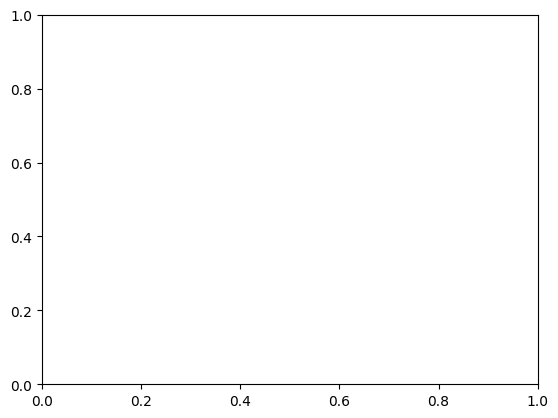

In [9]:
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual USGS Height (m)')
plt.ylabel('Predicted USGS Height (m)')
plt.title('Random Forest: (Reach based Splitting)')
plt.savefig('predictedVsactual_random.png')
plt.show()


In [8]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from datetime import datetime
import os
import pickle
import matplotlib.pyplot as plt

# Assuming X, y, data, preprocessor, numerical_features are defined
# Replace with your actual data loading and preprocessing steps

# Create directories for saving models, datasets, and plots
output_dir = 'experiment_results'
os.makedirs(os.path.join(output_dir, 'models'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'datasets'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'plots'), exist_ok=True)

# Initialize global DataFrames to store results across all test setups
if 'performance_df' not in globals():
    performance_df = pd.DataFrame(columns=['split_type', 'fold', 'model', 'MSE', 'MAE', 'R2', 'model_path'])
if 'residuals_df' not in globals():
    residuals_df = pd.DataFrame(columns=['split_type', 'fold', 'residual', 'test_data_path'])
if 'feature_importance_df' not in globals():
    feature_importance_df = pd.DataFrame(columns=['split_type', 'fold', 'feature', 'importance'])

# Set up 10-fold cross-validation based on reaches
gkf = GroupKFold(n_splits=10)
fold_results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=data['swot_reach_id'])):
    print(f"Fold {fold+1}")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Preprocess the data
    X_train_preprocessed = preprocessor.fit_transform(X_train)
    X_test_preprocessed = preprocessor.transform(X_test)
    
    # Convert to numpy arrays
    X_train_np = X_train_preprocessed
    X_test_np = X_test_preprocessed
    y_train_np = y_train.to_numpy()
    y_test_np = y_test.to_numpy()
    
    results = {}
    
    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train_np, y_train_np)
    y_pred_lr = lr.predict(X_test_np)
    results['Linear Regression'] = {
        'MSE': mean_squared_error(y_test_np, y_pred_lr),
        'MAE': mean_absolute_error(y_test_np, y_pred_lr),
        'R2': r2_score(y_test_np, y_pred_lr)
    }
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train_np, y_train_np)
    y_pred_rf = rf.predict(X_test_np)
    results['Random Forest'] = {
        'MSE': mean_squared_error(y_test_np, y_pred_rf),
        'MAE': mean_absolute_error(y_test_np, y_pred_rf),
        'R2': r2_score(y_test_np, y_pred_rf)
    }
    
    # Gradient Boosting
    gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb.fit(X_train_np, y_train_np)
    y_pred_gb = gb.predict(X_test_np)
    results['Gradient Boosting'] = {
        'MSE': mean_squared_error(y_test_np, y_pred_gb),
        'MAE': mean_absolute_error(y_test_np, y_pred_gb),
        'R2': r2_score(y_test_np, y_pred_gb)
    }
    
    # PyTorch Neural Network
    class Net(nn.Module):
        def __init__(self, input_size):
            super(Net, self).__init__()
            self.fc1 = nn.Linear(input_size, 64)
            self.fc2 = nn.Linear(64, 32)
            self.fc3 = nn.Linear(32, 16)
            self.fc4 = nn.Linear(16, 1)
            self.relu = nn.ReLU()
            
        def forward(self, x):
            x = self.relu(self.fc1(x))
            x = self.relu(self.fc2(x))
            x = self.relu(self.fc3(x))
            x = self.fc4(x)
            return x
    
    # Split training data into sub-training and validation sets
    X_train_sub, X_val, y_train_sub, y_val = train_test_split(
        X_train_np, y_train_np, test_size=0.2, random_state=42
    )
    
    # Convert to tensors
    X_train_sub_tensor = torch.tensor(X_train_sub, dtype=torch.float32)
    y_train_sub_tensor = torch.tensor(y_train_sub, dtype=torch.float32).reshape(-1, 1)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)
    X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).reshape(-1, 1)
    
    # Create DataLoader
    train_dataset = TensorDataset(X_train_sub_tensor, y_train_sub_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    # Initialize model, loss, optimizer
    model = Net(input_size=X_train_np.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training loop with early stopping
    epochs = 100
    patience = 10
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        
        # Validation loss
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
        
        print(f"Epoch {epoch+1}, Validation Loss: {val_loss.item():.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'best_model_fold_{fold}.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
    
    # Load best model
    model.load_state_dict(torch.load(f'best_model_fold_{fold}.pt'))
    model.eval()
    with torch.no_grad():
        y_pred_nn = model(X_test_tensor).numpy().flatten()
    results['Neural Network (PyTorch)'] = {
        'MSE': mean_squared_error(y_test_np, y_pred_nn),
        'MAE': mean_absolute_error(y_test_np, y_pred_nn),
        'R2': r2_score(y_test_np, y_pred_nn)
    }
    
    # Determine best model based on lowest MSE
    best_model_name = min(results, key=lambda x: results[x]['MSE'])
    print(f"Best model for fold {fold+1}: {best_model_name}")
    
    # Get predictions from the best model
    if best_model_name == 'Linear Regression':
        y_pred_best = y_pred_lr
    elif best_model_name == 'Random Forest':
        y_pred_best = y_pred_rf
    elif best_model_name == 'Gradient Boosting':
        y_pred_best = y_pred_gb
    elif best_model_name == 'Neural Network (PyTorch)':
        y_pred_best = y_pred_nn
    
    # Calculate residuals for the best model
    residuals = y_test_np - y_pred_best
    
    # Generate residual distribution plot
    plt.figure(figsize=(8, 6))
    plt.hist(residuals, bins=30, edgecolor='black')
    plt.title(f'Residual Distribution for {best_model_name} (Fold {fold+1})')
    plt.xlabel('Residual')
    plt.ylabel('Frequency')
    plt.grid(True)
    residual_plot_path = os.path.join(output_dir, 'plots', f'residuals_fold_{fold+1}_{best_model_name.replace(" ", "_")}.png')
    plt.savefig(residual_plot_path)
    plt.close()
    
    # Create models dictionary
    models = {
        'Linear Regression': lr,
        'Random Forest': rf,
        'Gradient Boosting': gb,
        'Neural Network (PyTorch)': model
    }
    
    # Call save_results (defined below)
    save_results(
        split_type='reach_10fold',
        results=results,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        y_pred_best=y_pred_best,
        best_model_name=best_model_name,
        best_model=models[best_model_name],
        models=models,
        preprocessor=preprocessor,
        fold=fold
    )
    
    # Collect fold results for averaging
    fold_results.append(results)

# Compute average performance across folds
average_results = {}
for model_name in results.keys():
    mse_list = [fold_result[model_name]['MSE'] for fold_result in fold_results]
    mae_list = [fold_result[model_name]['MAE'] for fold_result in fold_results]
    r2_list = [fold_result[model_name]['R2'] for fold_result in fold_results]
    average_results[model_name] = {
        'MSE': np.mean(mse_list),
        'MAE': np.mean(mae_list),
        'R2': np.mean(r2_list)
    }

print("\nAverage Model Performance Across Folds:")
for model_name, metrics in average_results.items():
    print(f"{model_name}: MSE = {metrics['MSE']:.4f}, MAE = {metrics['MAE']:.4f}, R² = {metrics['R2']:.4f}")

# Define save_results function
def save_results(split_type, results, X_train, X_test, y_train, y_test, y_pred_best, best_model_name, best_model, models, preprocessor, fold=None):
    global performance_df, residuals_df, feature_importance_df
    
    # Generate a timestamp for unique file naming
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # 1. Save train/test splits
    fold_str = f'_fold_{fold}' if fold is not None else ''
    train_data_path = os.path.join(output_dir, 'datasets', f'{split_type}{fold_str}_train_{timestamp}.csv')
    test_data_path = os.path.join(output_dir, 'datasets', f'{split_type}{fold_str}_test_{timestamp}.csv')
    
    # Combine features and target into DataFrames
    train_df = pd.concat([pd.DataFrame(X_train, columns=X_train.columns), pd.Series(y_train, name='target')], axis=1)
    test_df = pd.concat([pd.DataFrame(X_test, columns=X_test.columns), pd.Series(y_test, name='target')], axis=1)
    
    # Save to CSV
    train_df.to_csv(train_data_path, index=False)
    test_df.to_csv(test_data_path, index=False)
    
    # 2. Save models
    model_paths = {}
    for model_name, model in models.items():
        model_filename = f'{split_type}{fold_str}_{model_name.replace(" ", "_")}_{timestamp}.pkl'
        model_path = os.path.join(output_dir, 'models', model_filename)
        
        if model_name == 'Neural Network (PyTorch)':
            torch.save(model.state_dict(), model_path)
        else:
            with open(model_path, 'wb') as f:
                pickle.dump(model, f)
        model_paths[model_name] = model_path
    
    # 3. Save performance metrics
    perf_records = []
    for model, metrics in results.items():
        perf_records.append({
            'split_type': split_type,
            'fold': fold,  # Record fold number for all split types if provided
            'model': model,
            'MSE': metrics['MSE'],
            'MAE': metrics['MAE'],
            'R2': metrics['R2'],
            'model_path': None if model == 'Neural Network (PyTorch)' else model_paths[model]
        })
    performance_df = pd.concat([performance_df, pd.DataFrame(perf_records)], ignore_index=True)
    
    # 4. Save residuals for the best model
    residuals = y_test - y_pred_best
    res_df = pd.DataFrame({
        'split_type': split_type,
        'fold': fold,
        'residual': residuals,
        'test_data_path': test_data_path
    })
    residuals_df = pd.concat([residuals_df, res_df], ignore_index=True)
    
    # 5. Save feature importance for the best model
    numerical_features = preprocessor.transformers_[0][2]  # Assuming numerical features are first
    all_feature_names = list(numerical_features)
    
    if best_model_name in ['Random Forest', 'Gradient Boosting']:
        importances = best_model.feature_importances_
        fi_df = pd.DataFrame({
            'split_type': split_type,
            'fold': fold,
            'feature': all_feature_names,
            'importance': importances
        })
    elif best_model_name == 'Linear Regression':
        coefs = best_model.coef_
        fi_df = pd.DataFrame({
            'split_type': split_type,
            'fold': fold,
            'feature': all_feature_names,
            'importance': np.abs(coefs)
        })
    elif best_model_name == 'Neural Network (PyTorch)':
        fi_df = pd.DataFrame({
            'split_type': split_type,
            'fold': fold,
            'feature': ['N/A'],
            'importance': [0]
        })
    else:
        fi_df = pd.DataFrame()
    
    if not fi_df.empty:
        feature_importance_df = pd.concat([feature_importance_df, fi_df], ignore_index=True)

# Optionally save all results to files (uncomment if needed)
# def save_all_results_to_files():
#     performance_df.to_csv(os.path.join(output_dir, 'performance_results.csv'), index=False)
#     residuals_df.to_csv(os.path.join(output_dir, 'residuals_results.csv'), index=False)
#     feature_importance_df.to_csv(os.path.join(output_dir, 'feature_importance_results.csv'), index=False)
# save_all_results_to_files()

Fold 1


KeyboardInterrupt: 

In [47]:
average_results

{'Linear Regression': {'MSE': 47.77777124371649,
  'MAE': 3.4776730006912073,
  'R2': -0.38042504730595667},
 'Random Forest': {'MSE': 23.655659680603215,
  'MAE': 1.6827129166420385,
  'R2': -0.32130961000460057},
 'Gradient Boosting': {'MSE': 23.630710825652653,
  'MAE': 2.0847902956932147,
  'R2': 0.1380801998582472},
 'Neural Network (PyTorch)': {'MSE': 252.71311849098387,
  'MAE': 3.375771775412858,
  'R2': -6.971578813983273}}

## split by time


In [44]:
data.columns

Index(['datetime', 'tz_cd', 'swot_reach_id', 'latitude', 'longitude',
       'swot_height_m', 'swot_height_u_m', 'swot_height_r_u', 'swot_width_m',
       'swot_width_u_m', 'swot_slope', 'swot_slope_u', 'swot_slope_r_u',
       'swot_slope2', 'swot_dark_frac', 'swot_n_good_nod', 'swot_reach_q_b',
       'swot_xovr_cal_q', 'swot_xtrk_dist', 'ice_clim_f', 'data_quality',
       'date_retrieved', 'swot_data_collection', 'sword_version',
       'usgs_gage_link', 'river_name', 'date', 'usgs_height_m', 'state',
       'terrain_elevation_m', 'terrain_slope_deg', 'wse_corrected', 'geoid',
       'eht', 'oht', 'deltah', 'usgs_flow_m3s', 'swot-train', 'cumcount',
       'group_size', 'train_size', 'is_train'],
      dtype='object')

Epoch 1, Validation Loss: 50.3840

Model Performance:
Linear Regression: MSE = 100505119.9295, MAE = 112.7817, R² = -2437515.1080
Random Forest: MSE = 2.2645, MAE = 0.7163, R² = 0.9451
Gradient Boosting: MSE = 13.3215, MAE = 1.9743, R² = 0.6769
Neural Network (PyTorch): MSE = 1439117705.2349, MAE = 417.7575, R² = -34902425.7642

Best model (lowest MSE): Random Forest


/tmp/ipykernel_131/834941548.py:154: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('time_best_model.pt'))


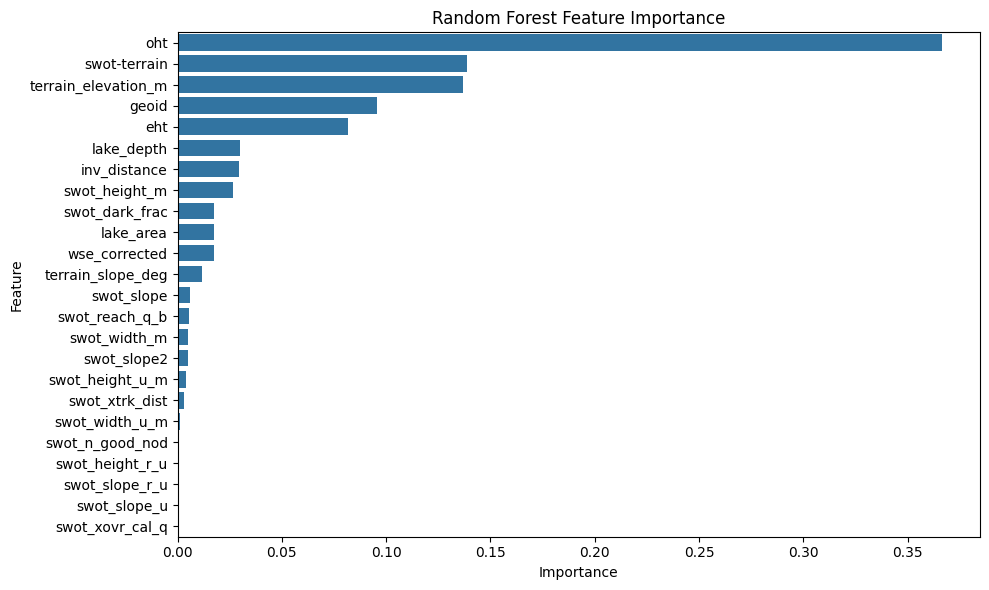

Feature Importance:
                Feature  Importance
18                  oht    0.366388
23         swot-terrain    0.138663
14  terrain_elevation_m    0.136848
16                geoid    0.095744
17                  eht    0.081739
21           lake_depth    0.029860
20         inv_distance    0.029503
0         swot_height_m    0.026696
9        swot_dark_frac    0.017513
22            lake_area    0.017259
19        wse_corrected    0.017228
15    terrain_slope_deg    0.011525
5            swot_slope    0.005713
11       swot_reach_q_b    0.005631
3          swot_width_m    0.004875
8           swot_slope2    0.004760
1       swot_height_u_m    0.003900
13       swot_xtrk_dist    0.003128
4        swot_width_u_m    0.001254
10      swot_n_good_nod    0.000813
2       swot_height_r_u    0.000605
7        swot_slope_r_u    0.000210
6          swot_slope_u    0.000116
12      swot_xovr_cal_q    0.000030


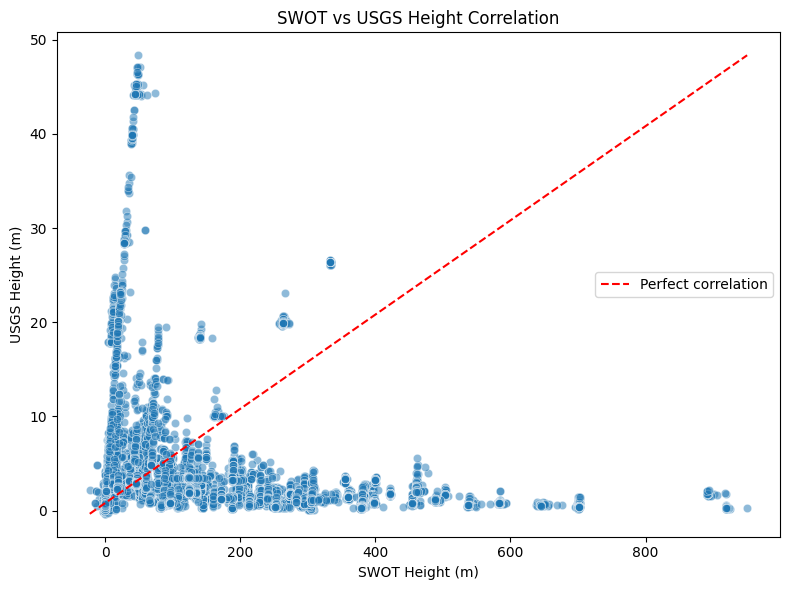

Pearson correlation between swot_height_m-terrain and usgs_height_m: -0.1675

Best model (lowest MAE): Random Forest
Percentage of test cases error under 20 cm (SWOT nominal accuracy) is 47.62%


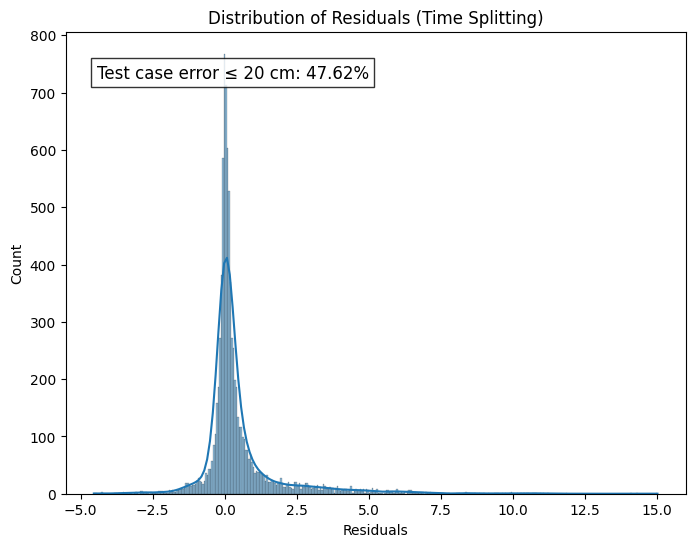

Precentage of test cases error under 20 cm (SWOT nominal accuracy) is 47.62 %


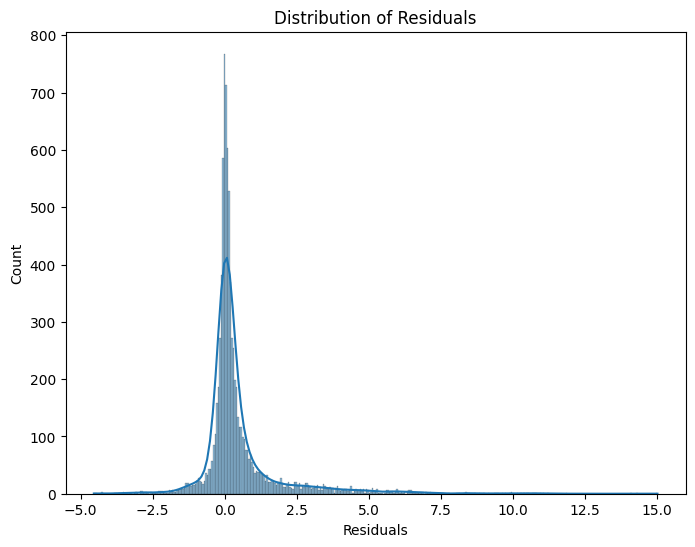

In [16]:

# Sort data by 'swot_reach_id' and 'datetime' for time-series splitting
data = data.sort_values(by=['swot_reach_id', 'datetime'])

# Time-series split: 80% train, 20% test for each gauge
data['cumcount'] = data.groupby('swot_reach_id').cumcount()
data['group_size'] = data.groupby('swot_reach_id')['cumcount'].transform('size')
data['train_size'] = (data['group_size'] * 0.2).astype(int)
data['is_train'] = data['cumcount'] < data['train_size']



# Split into training and testing sets
train_data = data[data['is_train']]
test_data = data[~data['is_train']]

# Prepare X and y
X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

# Apply preprocessing
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Convert data to numpy arrays for PyTorch
X_train_np = X_train_preprocessed
X_test_np = X_test_preprocessed
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

# Define PyTorch Neural Network
class Net(nn.Module):
    def __init__(self, input_size):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Try multiple models
results = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_preprocessed, y_train)
y_pred_lr = lr.predict(X_test_preprocessed)
results['Linear Regression'] = {
    'MSE': mean_squared_error(y_test, y_pred_lr),
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'R2': r2_score(y_test, y_pred_lr)
}

# Random Forest
rf = RandomForestRegressor(n_estimators=20, random_state=42)
rf.fit(X_train_preprocessed, y_train)
y_pred_rf = rf.predict(X_test_preprocessed)
results['Random Forest'] = {
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf)

}




# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=20, random_state=42)
gb.fit(X_train_preprocessed, y_train)
y_pred_gb = gb.predict(X_test_preprocessed)
results['Gradient Boosting'] = {
    'MSE': mean_squared_error(y_test, y_pred_gb),
    'MAE': mean_absolute_error(y_test, y_pred_gb),
    'R2': r2_score(y_test, y_pred_gb)
}

'''
# XGBoost
xgb = XGBRegressor(n_estimators=20, random_state=42)
xgb.fit(X_train_preprocessed, y_train)
y_pred_xgb = xgb.predict(X_test_preprocessed)
results['XGBoost'] = {
    'MSE': mean_squared_error(y_test, y_pred_xgb),
    'MAE': mean_absolute_error(y_test, y_pred_xgb),
    'R2': r2_score(y_test, y_pred_xgb)
}


'''
# PyTorch Neural Network
# Convert data to tensors
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32).reshape(-1, 1)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).reshape(-1, 1)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize model, loss, optimizer
model = Net(input_size=X_train_np.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop with early stopping
epochs = 1
patience = 10
best_val_loss = float('inf')
patience_counter = 0
val_split = 0.2
n_val = int(len(X_train_tensor) * val_split)
X_train_sub, X_val = X_train_tensor[n_val:], X_train_tensor[:n_val]
y_train_sub, y_val = y_train_tensor[n_val:], y_train_tensor[:n_val]

for epoch in range(epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    
    # Validation loss
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
    
    print(f"Epoch {epoch+1}, Validation Loss: {val_loss.item():.4f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'time_best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

# Load best model
model.load_state_dict(torch.load('time_best_model.pt'))
model.eval()
with torch.no_grad():
    y_pred_nn = model(X_test_tensor).numpy().flatten()
results['Neural Network (PyTorch)'] = {
    'MSE': mean_squared_error(y_test_np, y_pred_nn),
    'MAE': mean_absolute_error(y_test_np, y_pred_nn),
    'R2': r2_score(y_test_np, y_pred_nn)
}



# Display results
print("\nModel Performance:")
for model, metrics in results.items():
    print(f"{model}: MSE = {metrics['MSE']:.4f}, MAE = {metrics['MAE']:.4f}, R² = {metrics['R2']:.4f}")

# Explainability for the best model (lowest MSE)
best_model_name = min(results, key=lambda x: results[x]['MSE'])
print(f"\nBest model (lowest MSE): {best_model_name}")
best_model = {'Linear Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}[best_model_name]

# Feature Importance
num_feature_names = numerical_features
all_feature_names = list(num_feature_names)

if best_model_name in ['Random Forest', 'Gradient Boosting']:
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
    plt.title(f'{best_model_name} Feature Importance')
    plt.tight_layout()
    plt.show()
elif best_model_name == 'Linear Regression':
    coefs = best_model.coef_
    feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefs})
    feature_importance_df['Abs_Coefficient'] = feature_importance_df['Coefficient'].abs()
    feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Abs_Coefficient', y='Feature', data=feature_importance_df)
    plt.title('Linear Regression Absolute Coefficients')
    plt.tight_layout()
    plt.show()
else:  # Neural Network
    print("Feature importance not directly available for Neural Network. Consider SHAP for detailed analysis.")

if best_model_name != 'Neural Network (PyTorch)':
    print("Feature Importance:")
    print(feature_importance_df)

# Correlation Analysis (swot_height_m vs usgs_height_m)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['swot_height_m'], y=data['usgs_height_m'], alpha=0.5)
plt.plot([data['swot_height_m'].min(), data['swot_height_m'].max()], 
         [data['usgs_height_m'].min(), data['usgs_height_m'].max()], 'r--', label='Perfect correlation')
plt.xlabel('SWOT Height (m)')
plt.ylabel('USGS Height (m)')
plt.title('SWOT vs USGS Height Correlation')
plt.legend()
plt.tight_layout()
plt.show()

correlation = data['swot-terrain'].corr(data['usgs_height_m'])
print(f"Pearson correlation between swot_height_m-terrain and usgs_height_m: {correlation:.4f}")


# Best model (lowest MAE)
best_model_name = min(results, key=lambda x: results[x]['MAE'])
print(f"\nBest model (lowest MAE): {best_model_name}")
best_model = {'Linear Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}[best_model_name]
y_pred_best = {'Linear Regression': y_pred_lr, 'Random Forest': y_pred_rf, 'Gradient Boosting': y_pred_gb}[best_model_name]






# 3. Error Distribution
residuals = y_test - y_pred_best
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.title('Distribution of Residuals (Time Splitting)')

# Calculate percentage
error_percentage = round(100 * sum(abs(residuals) <= 0.2) / len(residuals), 2)

# Add text inside the graph (adjust x, y coordinates as needed)
plt.text(x=0.05, y=0.9, s=f'Test case error ≤ 20 cm: {error_percentage}%', 
         transform=plt.gca().transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

print(f'Percentage of test cases error under 20 cm (SWOT nominal accuracy) is {error_percentage}%')
plt.savefig('time_error_distribution.png')
plt.show()


# 3. Error Distribution
residuals = y_test - y_pred_best
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')
print(f'Precentage of test cases error under 20 cm (SWOT nominal accuracy) is {round(100*sum(abs(residuals)<=0.2)/len(residuals),2)} %')

                Feature  Importance
18                  oht    0.366388
23         swot-terrain    0.138663
14  terrain_elevation_m    0.136848
16                geoid    0.095744
17                  eht    0.081739
21           lake_depth    0.029860
20         inv_distance    0.029503
0         swot_height_m    0.026696
9        swot_dark_frac    0.017513
22            lake_area    0.017259
19        wse_corrected    0.017228
15    terrain_slope_deg    0.011525
5            swot_slope    0.005713
11       swot_reach_q_b    0.005631
3          swot_width_m    0.004875
8           swot_slope2    0.004760
1       swot_height_u_m    0.003900
13       swot_xtrk_dist    0.003128
4        swot_width_u_m    0.001254
10      swot_n_good_nod    0.000813
2       swot_height_r_u    0.000605
7        swot_slope_r_u    0.000210
6          swot_slope_u    0.000116
12      swot_xovr_cal_q    0.000030


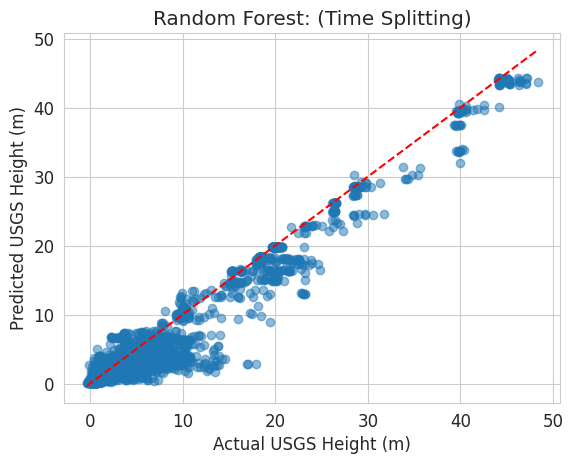

In [83]:
# Step 8: Feature importance and visualization
num_feature_names = numerical_features
#cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(num_feature_names) 
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
print(feature_importance_df.sort_values(by='Importance', ascending=False))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual USGS Height (m)')
plt.ylabel('Predicted USGS Height (m)')
plt.title('Random Forest: (Time Splitting)')
plt.savefig('predictedVsactual_time.png')
plt.show()

In [36]:
import pandas as pd
import numpy as np
import os
import pickle
import torch
from sklearn.compose import ColumnTransformer
from datetime import datetime

# Create directories for saving models and datasets
output_dir = 'experiment_results'
os.makedirs(os.path.join(output_dir, 'models'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'datasets'), exist_ok=True)

# Initialize global DataFrames to store results across all test setups
if 'performance_df' not in globals():
    performance_df = pd.DataFrame(columns=['split_type', 'fold', 'model', 'MSE', 'MAE', 'R2', 'model_path'])
if 'residuals_df' not in globals():
    residuals_df = pd.DataFrame(columns=['split_type', 'fold', 'residual', 'test_data_path'])
if 'feature_importance_df' not in globals():
    feature_importance_df = pd.DataFrame(columns=['split_type', 'fold', 'feature', 'importance'])


def save_results(split_type, results, X_train, X_test, y_train, y_test, y_pred_best, best_model_name, best_model, models, preprocessor, fold=None):
    """
    Save results, models, and train/test splits from a test setup.
    
    Parameters:
    - split_type: str, type of split ('random', 'river', 'time', 'state_loo')
    - results: dict, model performance metrics
    - X_train, X_test: DataFrame or array, raw train/test features
    - y_train, y_test: Series or array, train/test target
    - y_pred_best: array-like, predictions from the best model
    - best_model_name: str, name of the best model
    - best_model: trained model object
    - models: dict, all trained models {'model_name': model_object}
    - preprocessor: fitted ColumnTransformer object
    - fold: str or None, fold identifier (e.g., state name for state_loo)
    """
    global performance_df, residuals_df, feature_importance_df
    
    # Generate a timestamp for unique file naming
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # 1. Save train/test splits
    fold_str = f'_fold_{fold}' if fold else ''
    train_data_path = os.path.join(output_dir, 'datasets', f'{split_type}{fold_str}_train_{timestamp}.csv')
    test_data_path = os.path.join(output_dir, 'datasets', f'{split_type}{fold_str}_test_{timestamp}.csv')
    
    # Combine features and target into DataFrames
    train_df = pd.concat([pd.DataFrame(X_train, columns=X_train.columns), pd.Series(y_train, name='target')], axis=1)
    test_df = pd.concat([pd.DataFrame(X_test, columns=X_test.columns), pd.Series(y_test, name='target')], axis=1)
    
    # Save to CSV
    train_df.to_csv(train_data_path, index=False)
    test_df.to_csv(test_data_path, index=False)
    
    # 2. Save models
    model_paths = {}
    for model_name, model in models.items():
        model_filename = f'{split_type}{fold_str}_{model_name.replace(" ", "_")}_{timestamp}.pkl'
        model_path = os.path.join(output_dir, 'models', model_filename)
        
        if model_name == 'Neural Network (PyTorch)':
            # Save PyTorch model
            torch.save(model.state_dict(), model_path)
        else:
            # Save scikit-learn models
            with open(model_path, 'wb') as f:
                pickle.dump(model, f)
        model_paths[model_name] = model_path
    
    # 3. Save performance metrics
    perf_records = []
    for model, metrics in results.items():
        perf_records.append({
            'split_type': split_type,
            'fold': fold if split_type == 'state_loo' else None,
            'model': model,
            'MSE': metrics['MSE'],
            'MAE': metrics['MAE'],
            'R2': metrics['R2'],
            'model_path':None if model== 'Neural Network (PyTorch)' else model_paths[model]
        })
    performance_df = pd.concat([performance_df, pd.DataFrame(perf_records)], ignore_index=True)
    
    # 4. Save residuals for the best model
    residuals = y_test - y_pred_best
    res_df = pd.DataFrame({
        'split_type': split_type,
        'fold': fold if split_type == 'state_loo' else None,
        'residual': residuals,
        'test_data_path': test_data_path
    })
    residuals_df = pd.concat([residuals_df, res_df], ignore_index=True)
    
    # 5. Save feature importance for the best model
    # Get feature names from preprocessor
    numerical_features = preprocessor.transformers_[0][2]  # Assuming num features are first
    #categorical_transformer = preprocessor.named_transformers_['cat']
    #cat_feature_names = categorical_transformer.get_feature_names_out()
    all_feature_names = list(numerical_features) #+ list(cat_feature_names)
    
    if best_model_name in ['Random Forest', 'Gradient Boosting']:
        importances = best_model.feature_importances_
        fi_df = pd.DataFrame({
            'split_type': split_type,
            'fold': fold if split_type == 'state_loo' else None,
            'feature': all_feature_names,
            'importance': importances
        })
    elif best_model_name == 'Linear Regression':
        coefs = best_model.coef_
        fi_df = pd.DataFrame({
            'split_type': split_type,
            'fold': fold if split_type == 'state_loo' else None,
            'feature': all_feature_names,
            'importance': np.abs(coefs)  # Use absolute coefficients
        })
    elif best_model_name == 'Neural Network (PyTorch)':
        fi_df = pd.DataFrame({
            'split_type': split_type,
            'fold': fold if split_type == 'state_loo' else None,
            'feature': ['N/A'],
            'importance': [0]
        })
    else:
        fi_df = pd.DataFrame()
    
    if not fi_df.empty:
        feature_importance_df = pd.concat([feature_importance_df, fi_df], ignore_index=True)


# Example usage:
# For random, river, or time splits:
models = {'Linear Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}

save_results('Time', results, X_train, X_test, y_train, y_test, y_pred_best, best_model_name, best_model, models, preprocessor)


# For state_loo:
# for state in unique_states:
#     # Run training/testing
#     # Then call:
#     save_results('state_loo', results, X_train, X_test, y_train, y_test, y_pred_best, best_model_name, best_model, models, preprocessor, fold=state)

'''
# Save all results to CSV files
def save_all_results_to_files():
    performance_df.to_csv(os.path.join(output_dir, 'performance_results.csv'), index=False)
    residuals_df.to_csv(os.path.join(output_dir, 'residuals_results.csv'), index=False)
    feature_importance_df.to_csv(os.path.join(output_dir, 'feature_importance_results.csv'), index=False)
'''
# Call this at the end to save DataFrames
# save_all_results_to_files()

"\n# Save all results to CSV files\ndef save_all_results_to_files():\n    performance_df.to_csv(os.path.join(output_dir, 'performance_results.csv'), index=False)\n    residuals_df.to_csv(os.path.join(output_dir, 'residuals_results.csv'), index=False)\n    feature_importance_df.to_csv(os.path.join(output_dir, 'feature_importance_results.csv'), index=False)\n"

In [38]:
performance_df

,split_type,fold,model,MSE,MAE,R2,model_path
0,random,None,Linear Regression,3.114214e+01,3.196292,1.637591e-01,experiment_results/models/random_Linear_Regres...
1,random,None,Random Forest,5.109419e-01,0.326964,9.862800e-01,experiment_results/models/random_Random_Forest...
2,random,None,Gradient Boosting,2.100203e+00,0.878720,9.436045e-01,experiment_results/models/random_Gradient_Boos...
3,random,None,Neural Network (PyTorch),2.921420e+01,3.111365,2.155288e-01,None
4,Time,None,Linear Regression,1.005051e+08,112.781694,-2.437515e+06,experiment_results/models/Time_Linear_Regressi...
5,Time,None,Random Forest,2.264469e+00,0.716263,9.450806e-01,experiment_results/models/Time_Random_Forest_2...
6,Time,None,Gradient Boosting,1.332149e+01,1.974289,6.769185e-01,experiment_results/models/Time_Gradient_Boosti...
7,Time,None,Linear Regression,1.005051e+08,112.781694,-2.437515e+06,experiment_results/models/Time_Linear_Regressi...
8,Time,None,Random Forest,2.264469e+00,0.716263,9.450806e-01,experiment_results/models/Time_Random_Forest_2...
9,Time,None,Gradient Boosting,1.332149e+01,1.974289,6.769185e-01,experiment_results/models/Time_Gradient_Boosti...


Gauge-Specific Performance:


,Gauge,MSE,Correlation
144,https://waterdata.usgs.gov/monitoring-location...,0.013055,-0.125333
68,https://waterdata.usgs.gov/monitoring-location...,0.016036,0.147840
39,https://waterdata.usgs.gov/monitoring-location...,0.018921,-0.051036
69,https://waterdata.usgs.gov/monitoring-location...,0.020153,0.048423
46,https://waterdata.usgs.gov/monitoring-location...,0.020369,-0.047727
...,...,...,...
88,https://waterdata.usgs.gov/monitoring-location...,10.616660,0.801222
59,https://waterdata.usgs.gov/monitoring-location...,11.215286,0.905260
138,https://waterdata.usgs.gov/monitoring-location...,13.868066,0.144076
116,https://waterdata.usgs.gov/monitoring-location...,14.001764,0.778565


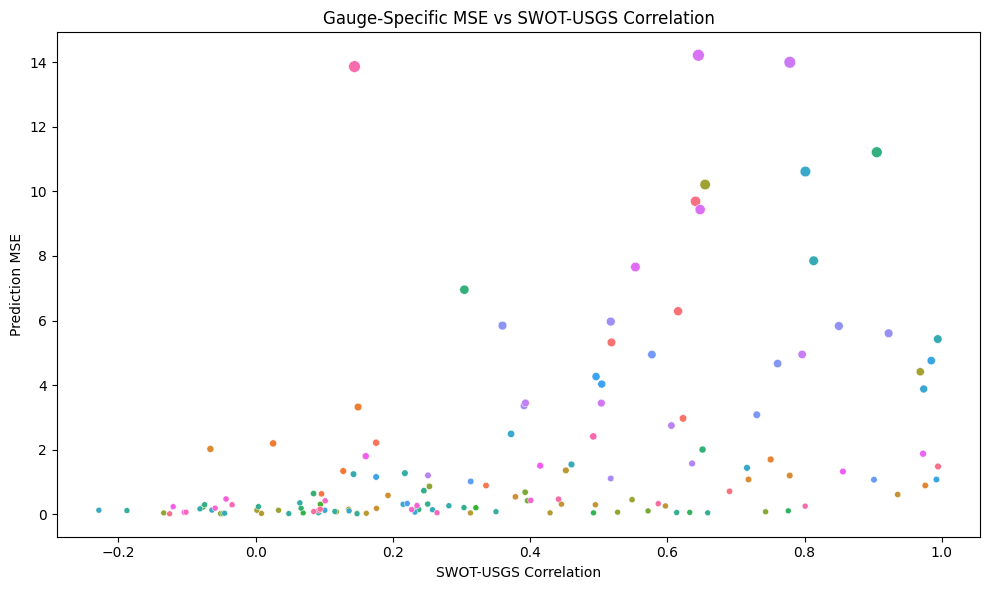

In [49]:
import seaborn as sns
from IPython.display import display
# Assume gauges are identified by usgs_gage_link
if 'usgs_gage_link' in data.columns:
    gauge_errors = []
    for gauge in data['usgs_gage_link'].unique():
        mask = data['usgs_gage_link'] == gauge
        gauge_data = data[mask]
        X_gauge = gauge_data[features]
        y_gauge = gauge_data[target]
        if len(y_gauge) < 5:  # Skip small samples
            continue
        X_gauge_pre = preprocessor.transform(X_gauge)
        y_pred_gauge = rf.predict(X_gauge_pre)
        mse_gauge = mean_squared_error(y_gauge, y_pred_gauge)
        corr_gauge = gauge_data['swot_height_m'].corr(gauge_data['usgs_height_m'])
        gauge_errors.append({'Gauge': gauge, 'MSE': mse_gauge, 'Correlation': corr_gauge})
    
    gauge_df = pd.DataFrame(gauge_errors)
    print("Gauge-Specific Performance:")
    display(gauge_df.sort_values(by='MSE'))

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Correlation', y='MSE', size='MSE', hue='Gauge', data=gauge_df, legend=False)
    plt.title('Gauge-Specific MSE vs SWOT-USGS Correlation')
    plt.xlabel('SWOT-USGS Correlation')
    plt.ylabel('Prediction MSE')
    plt.tight_layout()
    plt.show()
else:
    print("No usgs_gage_link column found for gauge-specific analysis")

Gauge-Specific Performance:


,Gauge,MAE,Correlation
144,https://waterdata.usgs.gov/monitoring-location...,0.013055,-0.125333
68,https://waterdata.usgs.gov/monitoring-location...,0.016036,0.147840
39,https://waterdata.usgs.gov/monitoring-location...,0.018921,-0.051036
69,https://waterdata.usgs.gov/monitoring-location...,0.020153,0.048423
46,https://waterdata.usgs.gov/monitoring-location...,0.020369,-0.047727
...,...,...,...
88,https://waterdata.usgs.gov/monitoring-location...,10.616660,0.801222
59,https://waterdata.usgs.gov/monitoring-location...,11.215286,0.905260
138,https://waterdata.usgs.gov/monitoring-location...,13.868066,0.144076
116,https://waterdata.usgs.gov/monitoring-location...,14.001764,0.778565


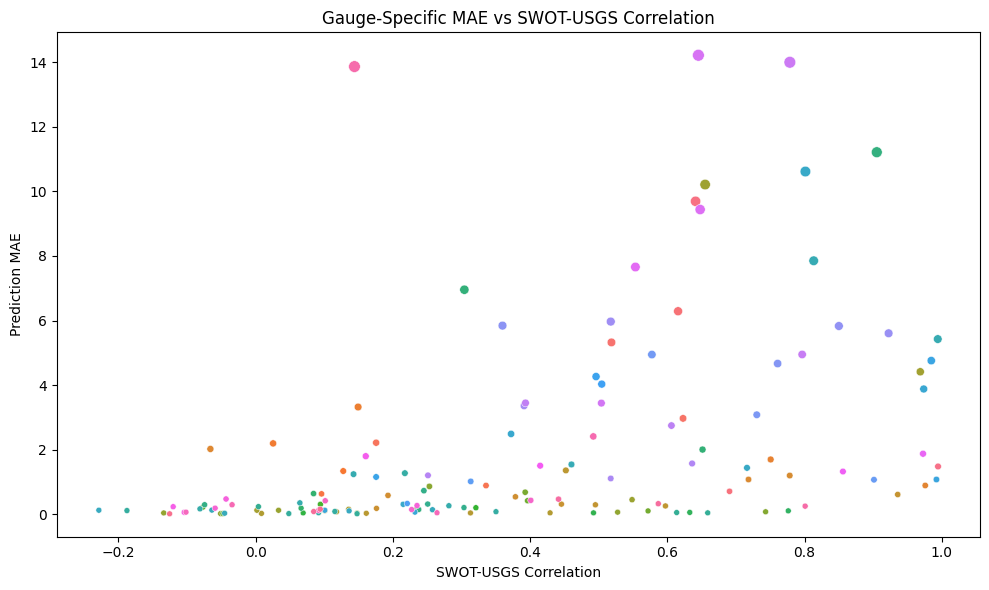

In [50]:
import seaborn as sns
from IPython.display import display
# Assume gauges are identified by usgs_gage_link
if 'usgs_gage_link' in data.columns:
    gauge_errors = []
    for gauge in data['usgs_gage_link'].unique():
        mask = data['usgs_gage_link'] == gauge
        gauge_data = data[mask]
        X_gauge = gauge_data[features]
        y_gauge = gauge_data[target]
        if len(y_gauge) < 5:  # Skip small samples
            continue
        X_gauge_pre = preprocessor.transform(X_gauge)
        y_pred_gauge = rf.predict(X_gauge_pre)
        mae_gauge = mean_squared_error(y_gauge, y_pred_gauge)
        corr_gauge = gauge_data['swot_height_m'].corr(gauge_data['usgs_height_m'])
        gauge_errors.append({'Gauge': gauge, 'MAE': mae_gauge, 'Correlation': corr_gauge})
    
    gauge_df = pd.DataFrame(gauge_errors)
    print("Gauge-Specific Performance:")
    display(gauge_df.sort_values(by='MAE'))

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Correlation', y='MAE', size='MAE', hue='Gauge', data=gauge_df, legend=False)
    plt.title('Gauge-Specific MAE vs SWOT-USGS Correlation')
    plt.xlabel('SWOT-USGS Correlation')
    plt.ylabel('Prediction MAE')
    plt.tight_layout()
    plt.show()
else:
    print("No usgs_gage_link column found for gauge-specific analysis")



In [22]:
list(gauge_df.sort_values(by='MAE')['Gauge'])[-2]

'https://waterdata.usgs.gov/monitoring-location/08116650/'


Model Performance:
Linear Regression: MSE = 35.7071, MAE = 3.3553, R² = 0.1461,
Random Forest: MSE = 0.3486, MAE = 0.2923, R² = 0.9917,
Gradient Boosting: MSE = 1.7508, MAE = 0.8443, R² = 0.9581,
Neural Network (PyTorch): MSE = 32.4115, MAE = 3.0207, R² = 0.2249,
XGBoost: MSE = 0.6063, MAE = 0.3579, R² = 0.9855,

Best model (lowest MAE): Random Forest
Precentage of test cases error under 20 cm (SWOT nominal accuracy) is 64.39 %
Pearson correlation between swot-terrain and usgs_height_m: -0.1675


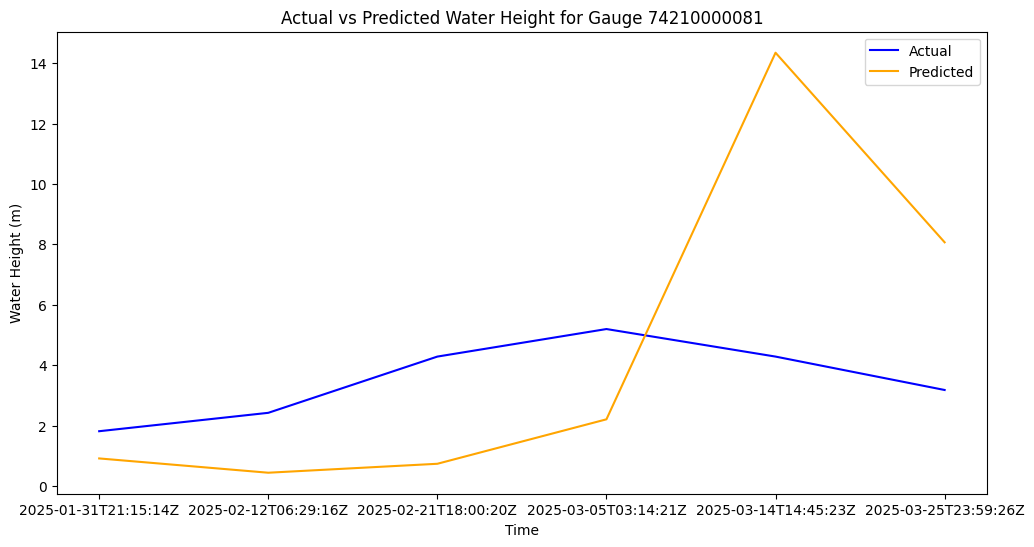

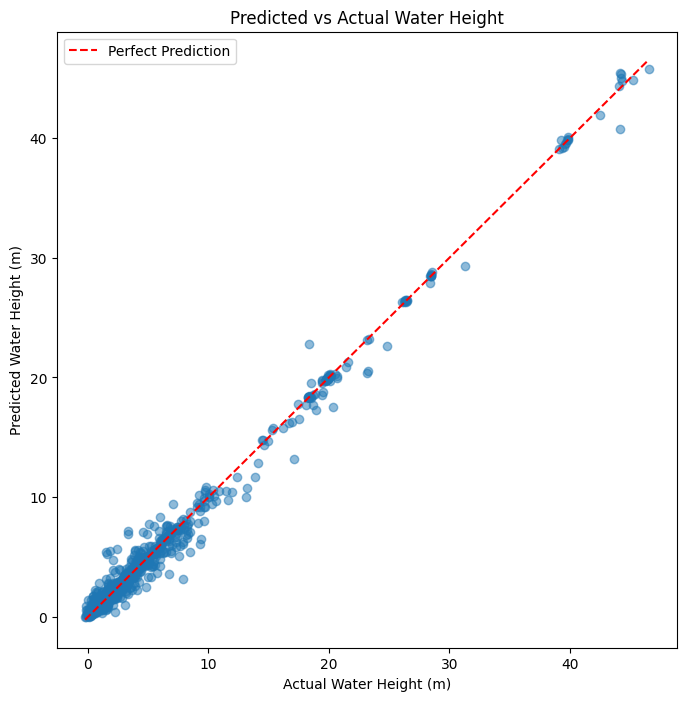

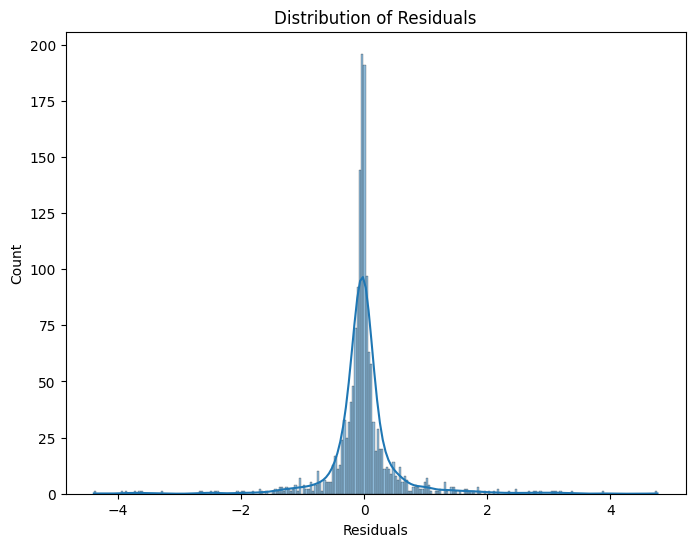

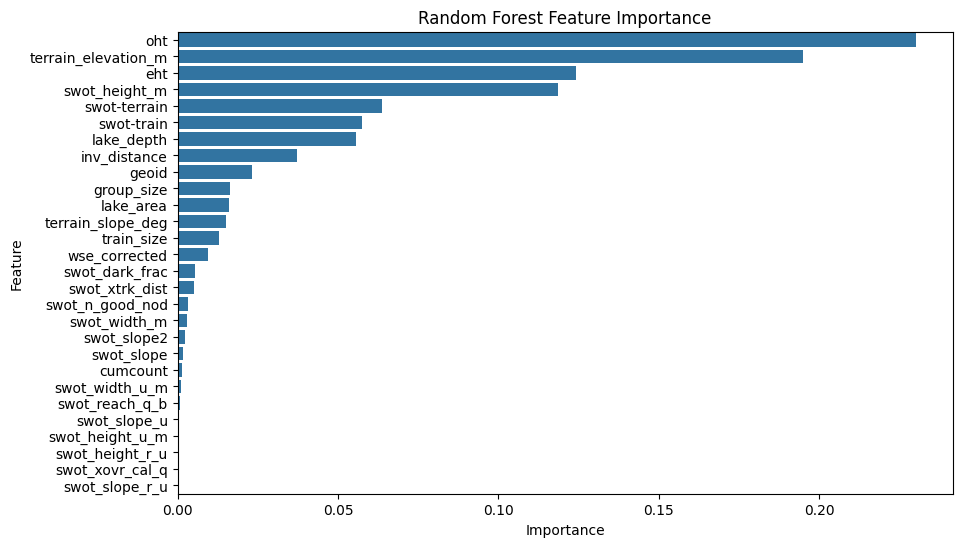

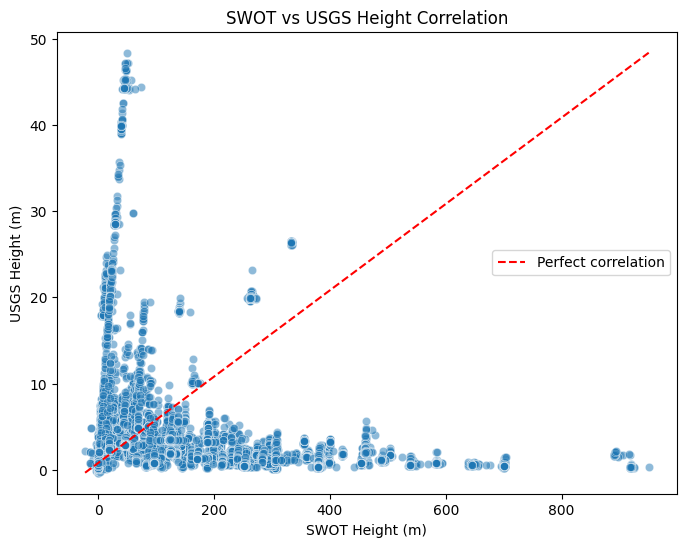

In [94]:

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_preprocessed, y_train)
y_pred_lr = lr.predict(X_test_preprocessed)
results['Linear Regression'] = {
    'MSE': mean_squared_error(y_test, y_pred_lr),
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'R2': r2_score(y_test, y_pred_lr),
   # 'NSE': nse(y_pred_lr, y_test),
   # 'KGE': kge(y_pred_lr, y_test)[0]
}

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_preprocessed, y_train)
y_pred_rf = rf.predict(X_test_preprocessed)
results['Random Forest'] = {
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf),
   # 'NSE': nse(y_pred_rf, y_test),
   # 'KGE': kge(y_pred_rf, y_test)[0]
}

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train_preprocessed, y_train)
y_pred_gb = gb.predict(X_test_preprocessed)
results['Gradient Boosting'] = {
    'MSE': mean_squared_error(y_test, y_pred_gb),
    'MAE': mean_absolute_error(y_test, y_pred_gb),
    'R2': r2_score(y_test, y_pred_gb),
  #  'NSE': nse(y_pred_gb, y_test),
   # 'KGE': kge(y_pred_gb, y_test)[0]
}


# XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train_preprocessed, y_train)
y_pred_xgb = xgb.predict(X_test_preprocessed)
results['XGBoost'] = {
    'MSE': mean_squared_error(y_test, y_pred_xgb),
    'MAE': mean_absolute_error(y_test, y_pred_xgb),
    'R2': r2_score(y_test, y_pred_xgb),
   # 'NSE': nse(y_pred_xgb, y_test),
    #'KGE': kge(y_pred_xgb, y_test)[0]
}

# Display results
print("\nModel Performance:")
for model, metrics in results.items():
    print(f"{model}: MSE = {metrics['MSE']:.4f}, MAE = {metrics['MAE']:.4f}, R² = {metrics['R2']:.4f},")

# Best model (lowest MAE)
best_model_name = min(results, key=lambda x: results[x]['MAE'])
print(f"\nBest model (lowest MAE): {best_model_name}")
best_model = {'Linear Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}[best_model_name]
y_pred_best = {'Linear Regression': y_pred_lr, 'Random Forest': y_pred_rf, 'Gradient Boosting': y_pred_gb}[best_model_name]


# Visualizations
# 1. Time Series Plot for a Sample Gauge
sample_gauge = test_data['swot_reach_id'].iloc[0]
gauge_data = test_data[test_data['swot_reach_id'] == sample_gauge]
gauge_indices = gauge_data.index
plt.figure(figsize=(12, 6))
plt.plot(gauge_data['datetime'], gauge_data['usgs_height_m'], label='Actual', color='blue')
plt.plot(gauge_data['datetime'], y_pred_best[gauge_data.index - test_data.index[0]], label='Predicted', color='orange')
plt.xlabel('Time')
plt.ylabel('Water Height (m)')
plt.title(f'Actual vs Predicted Water Height for Gauge {sample_gauge}')
plt.legend()
plt.savefig('time_series_plot.png')

# 2. Scatter Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Water Height (m)')
plt.ylabel('Predicted Water Height (m)')
plt.title('Predicted vs Actual Water Height')
plt.legend()
plt.savefig('scatter_plot.png')

# 3. Error Distribution
residuals = y_test - y_pred_best
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')
print(f'Precentage of test cases error under 20 cm (SWOT nominal accuracy) is {round(100*sum(abs(residuals)<=0.2)/len(residuals),2)} %')
plt.savefig('error_distribution.png')

# 4. Feature Importance
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': numerical_features, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
    plt.title(f'{best_model_name} Feature Importance')
    plt.savefig('feature_importance.png')
elif best_model_name == 'Linear Regression':
    coefs = best_model.coef_
    feature_importance_df = pd.DataFrame({'Feature': numerical_features, 'Coefficient': coefs})
    feature_importance_df['Abs_Coefficient'] = feature_importance_df['Coefficient'].abs()
    feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Abs_Coefficient', y='Feature', data=feature_importance_df)
    plt.title('Linear Regression Absolute Coefficients')
    plt.savefig('feature_coefficients.png')


# Correlation Analysis
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['swot_height_m'], y=data['usgs_height_m'], alpha=0.5)
plt.plot([data['swot_height_m'].min(), data['swot_height_m'].max()], 
         [data['usgs_height_m'].min(), data['usgs_height_m'].max()], 'r--', label='Perfect correlation')
plt.xlabel('SWOT Height (m)')
plt.ylabel('USGS Height (m)')
plt.title('SWOT vs USGS Height Correlation')
plt.legend()
plt.savefig('correlation_plot.png')

correlation = data['swot-terrain'].corr(data['usgs_height_m'])
print(f"Pearson correlation between swot-terrain and usgs_height_m: {correlation:.4f}")



/tmp/ipykernel_131/2077995059.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['datetime'] = pd.to_datetime(test_data['datetime'])


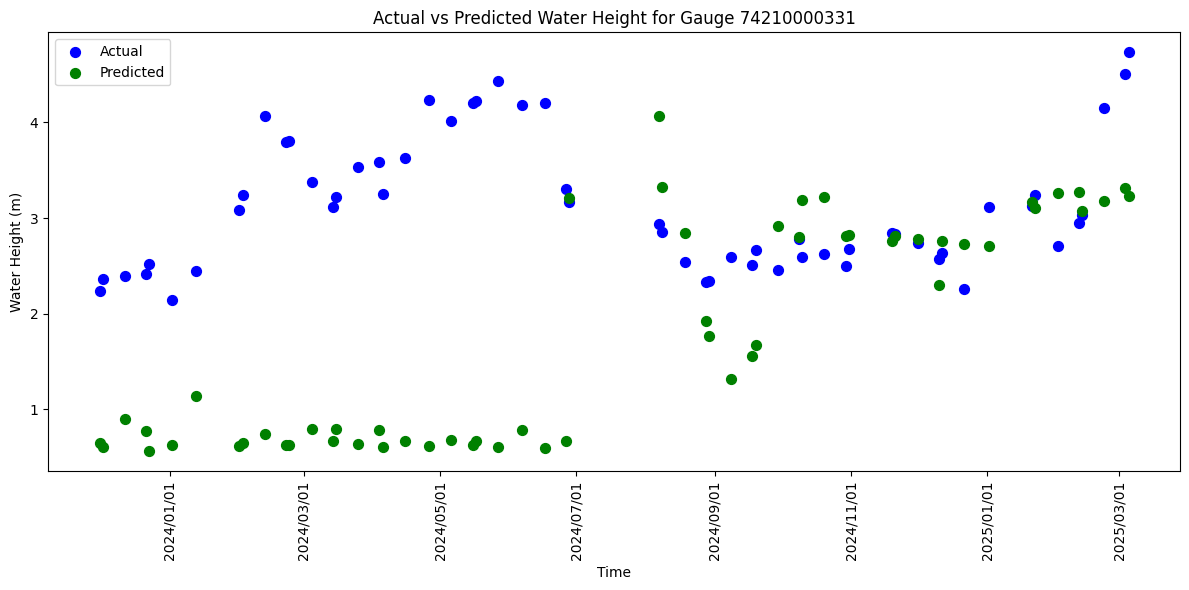

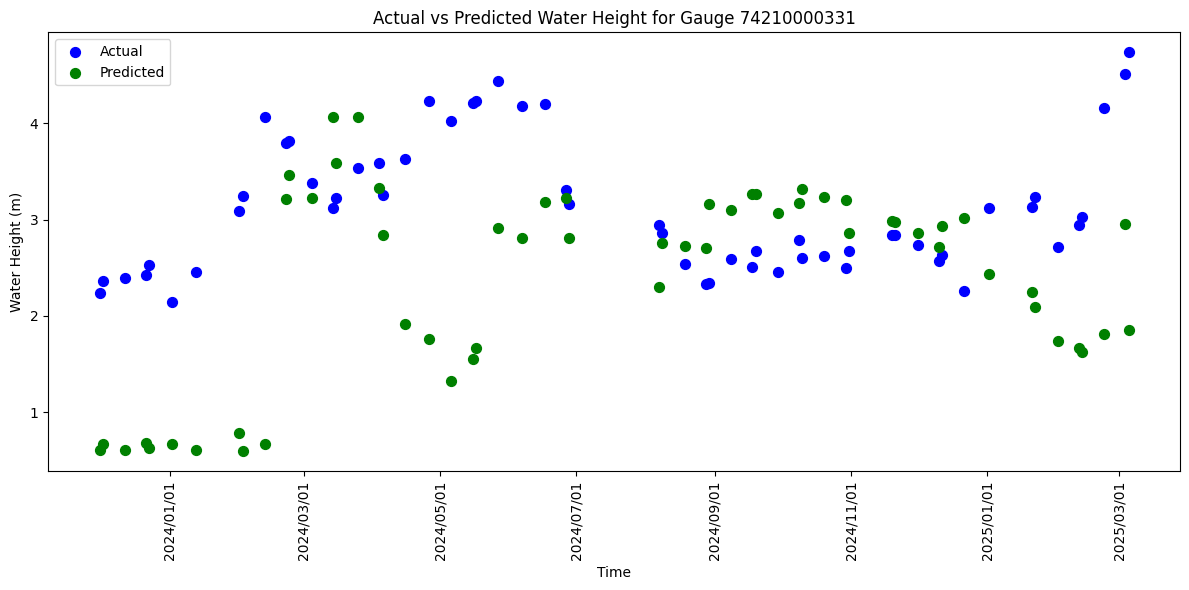

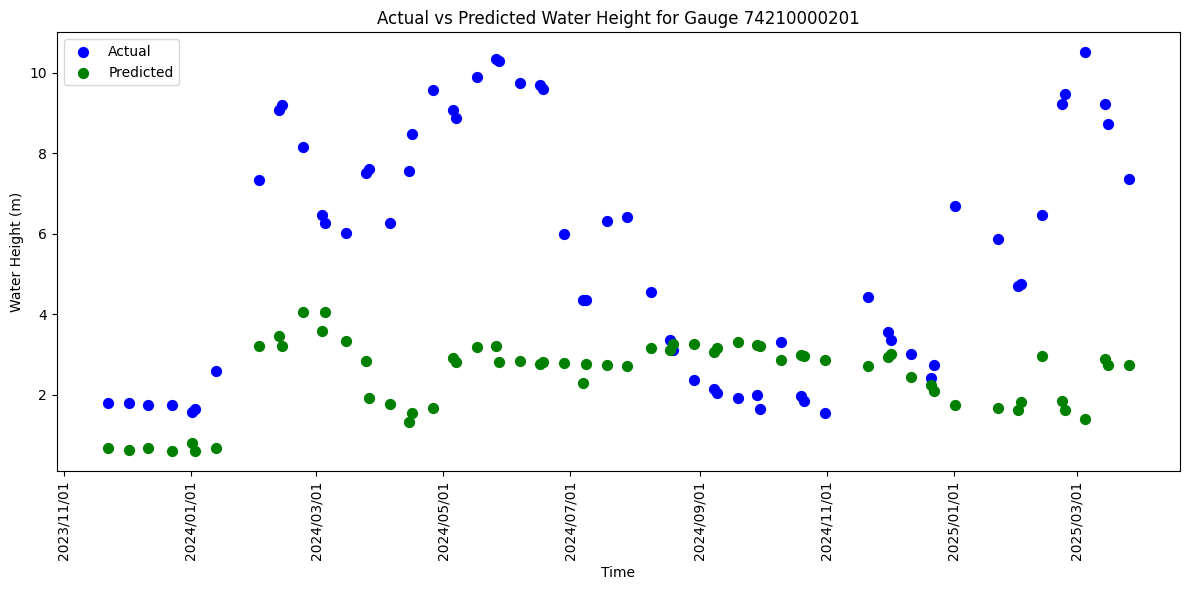

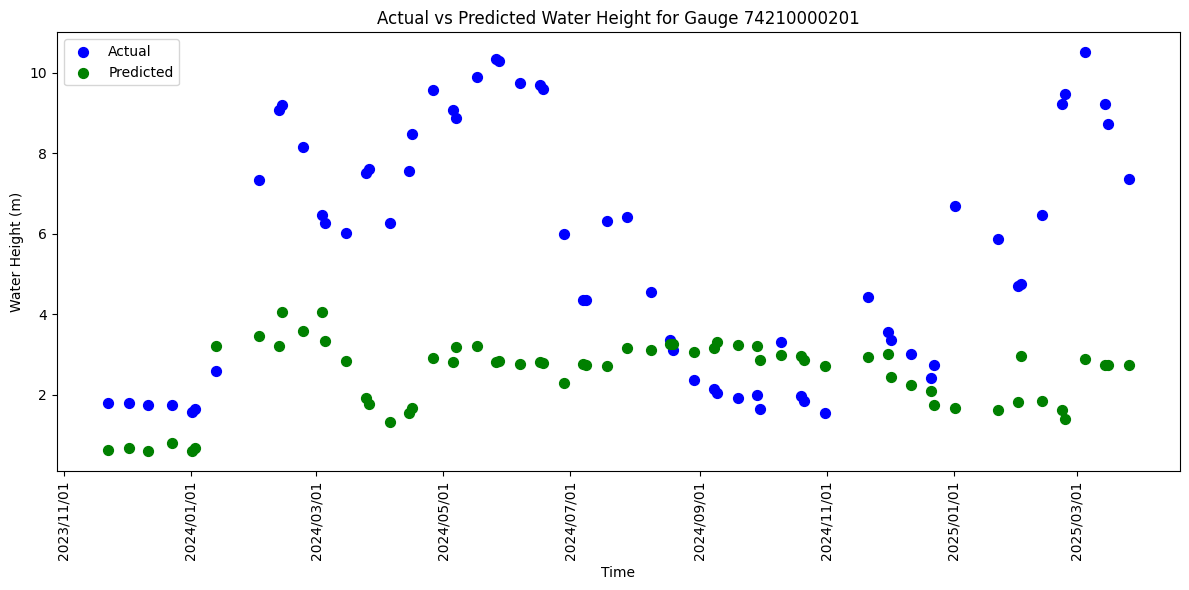

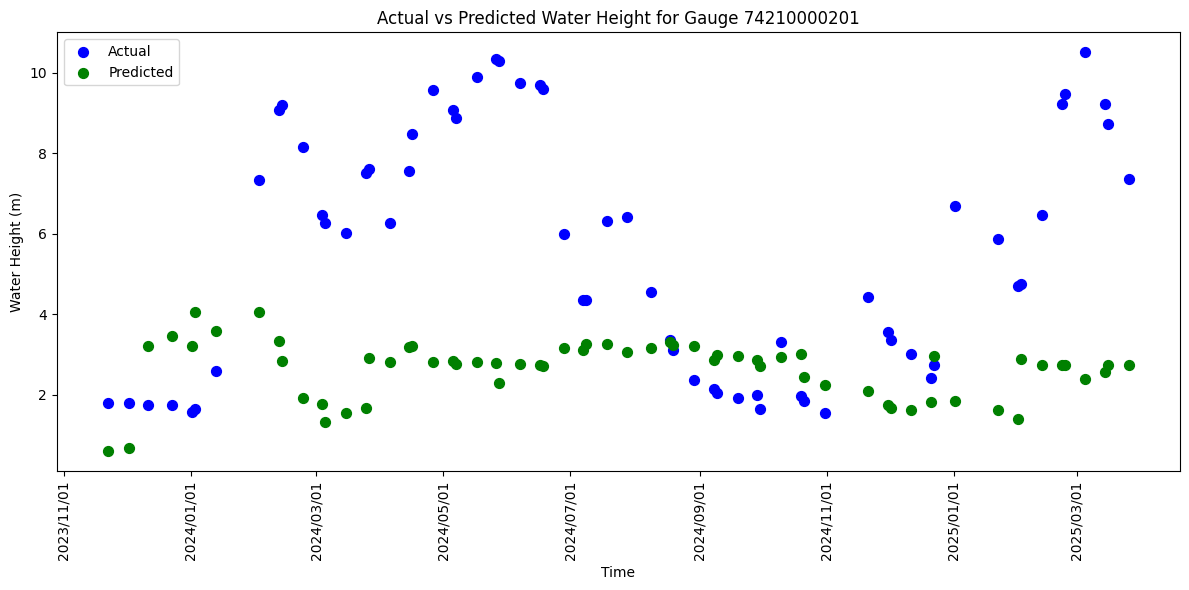

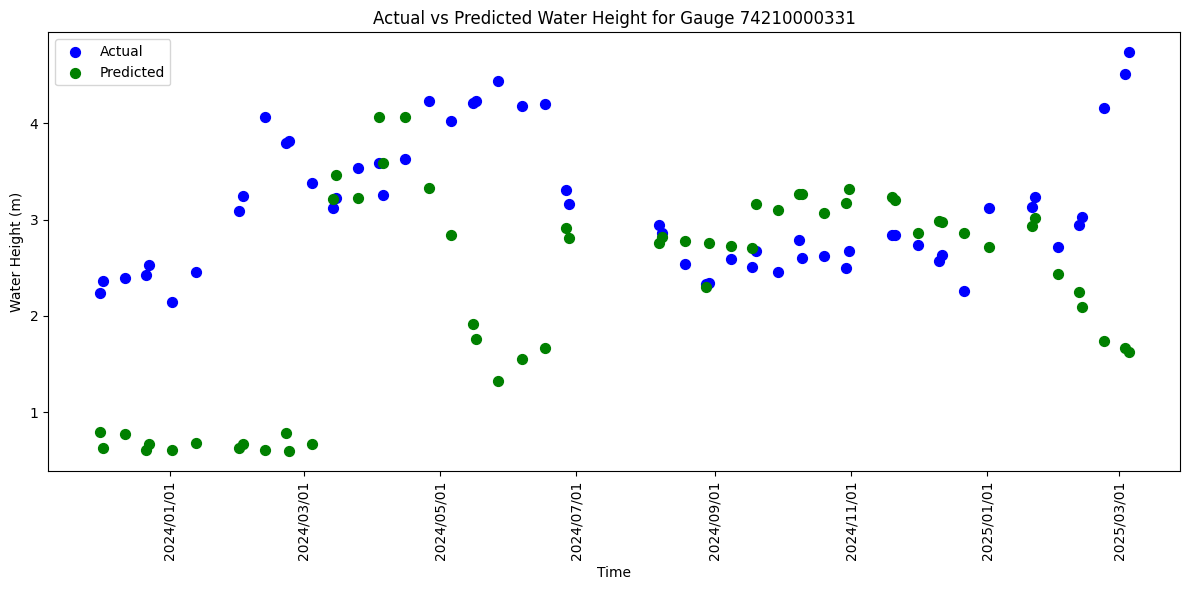

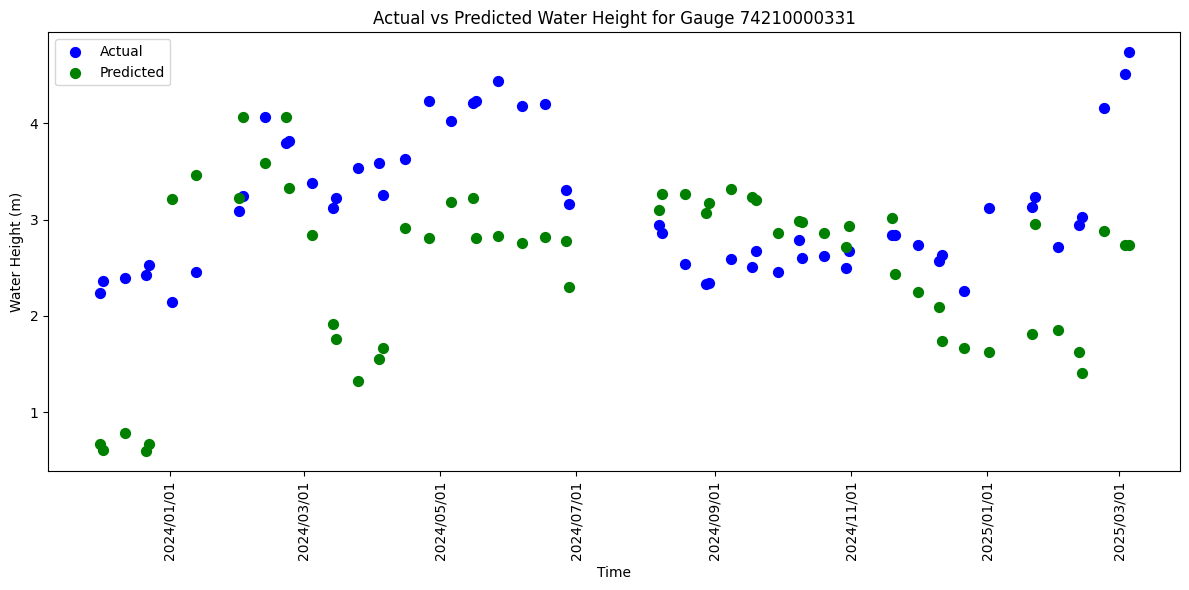

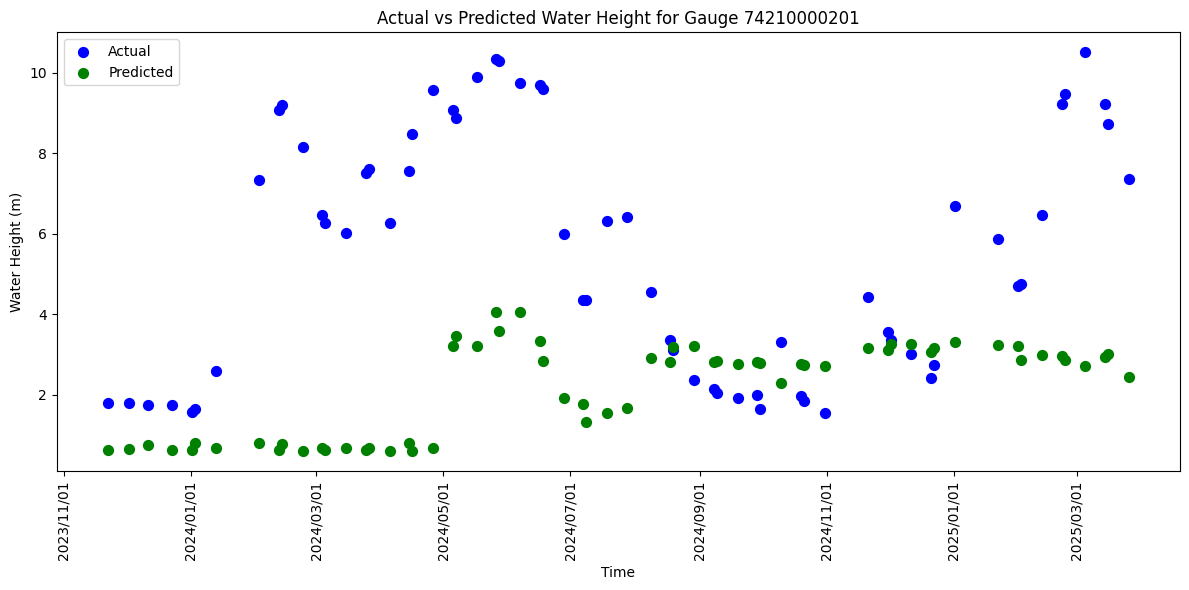

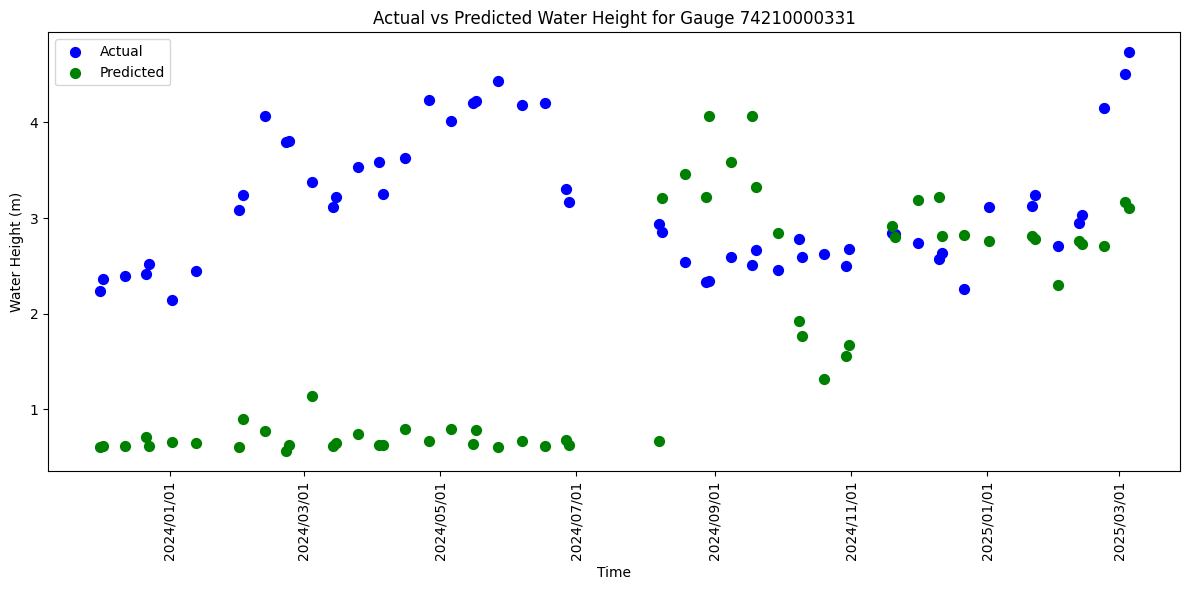

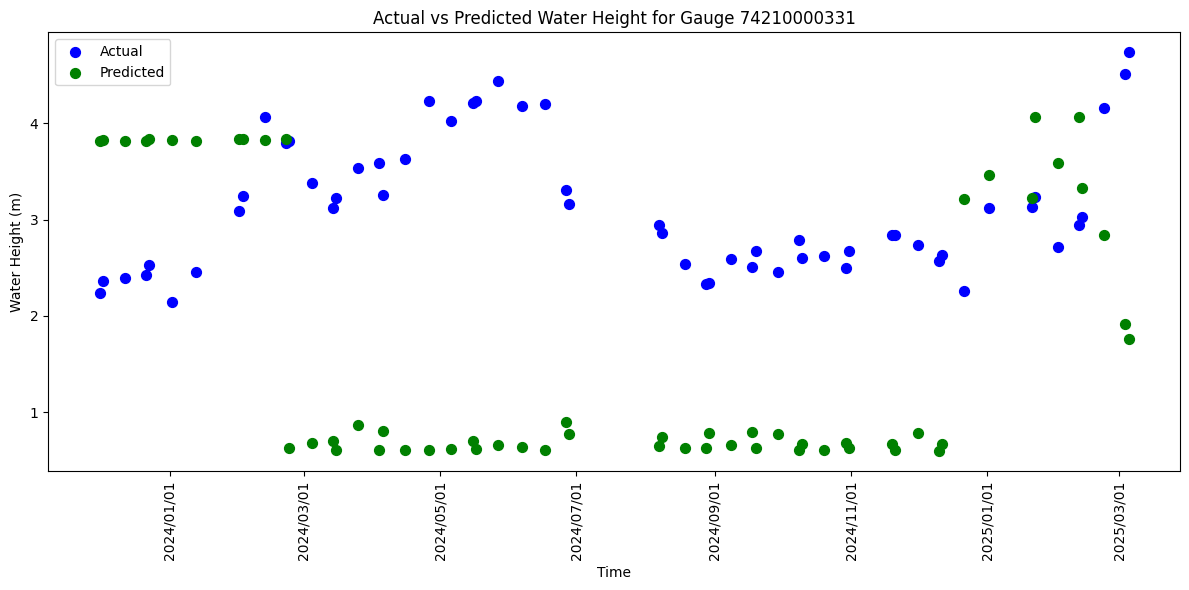

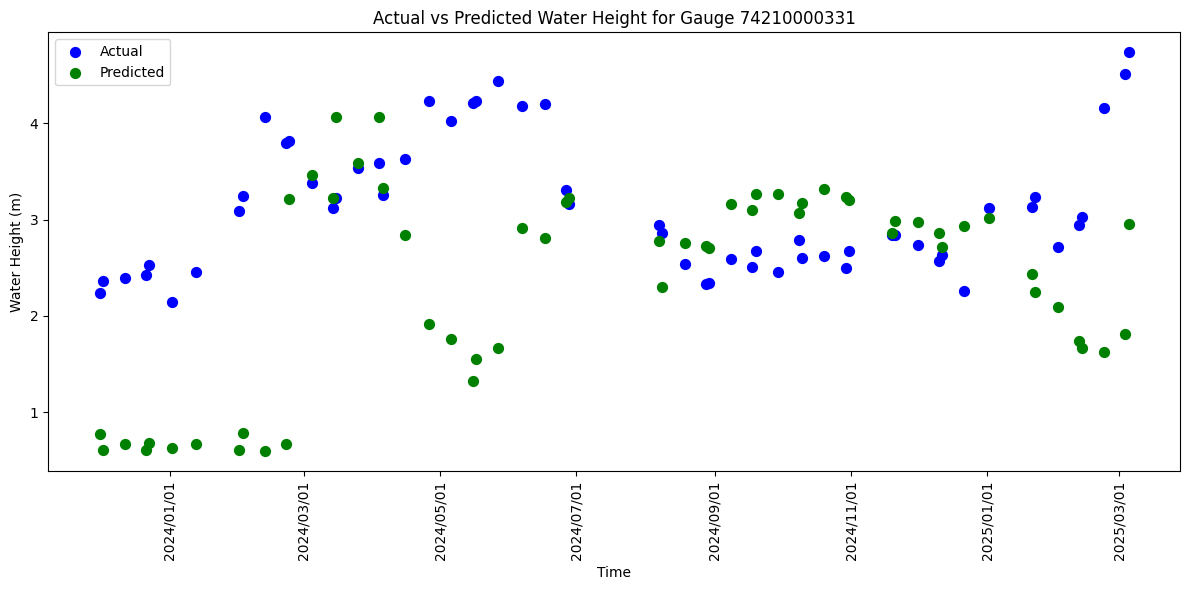

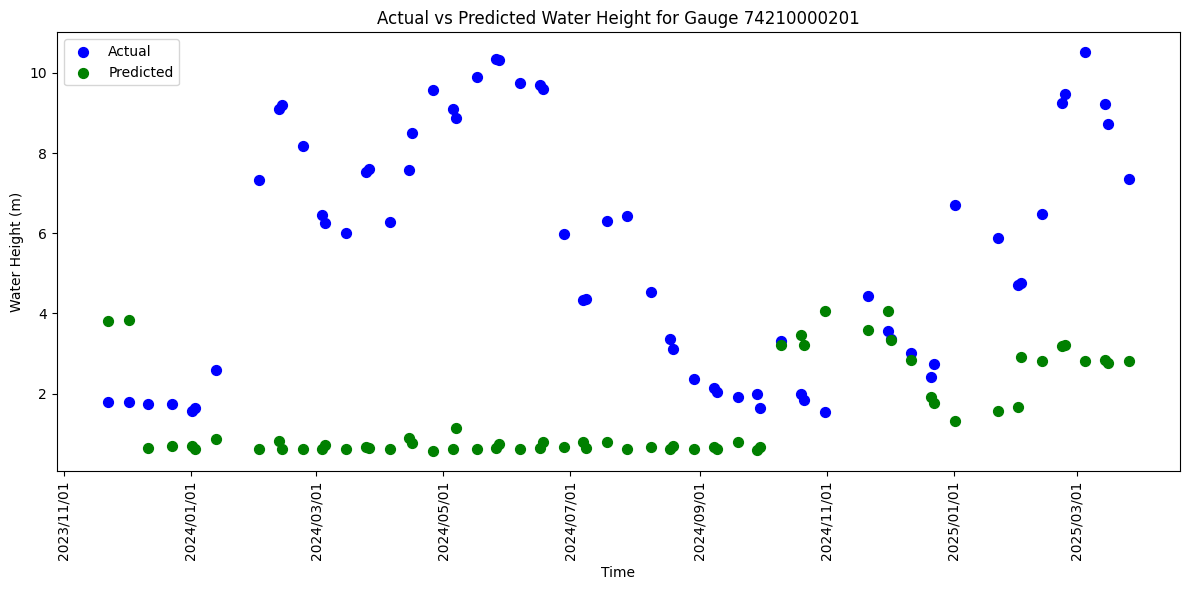

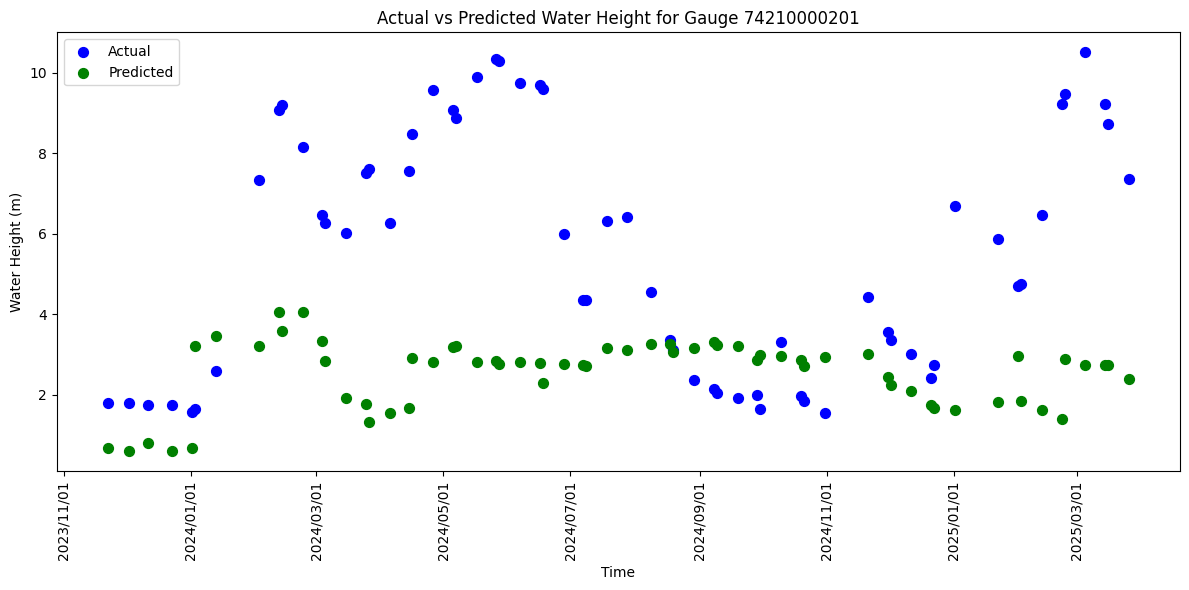

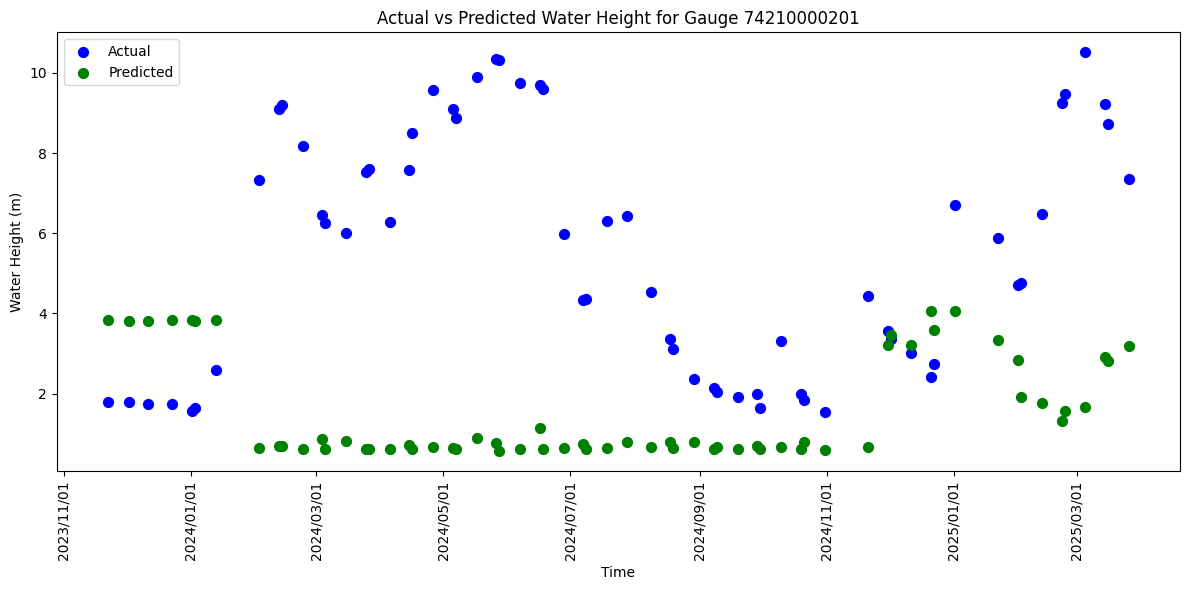

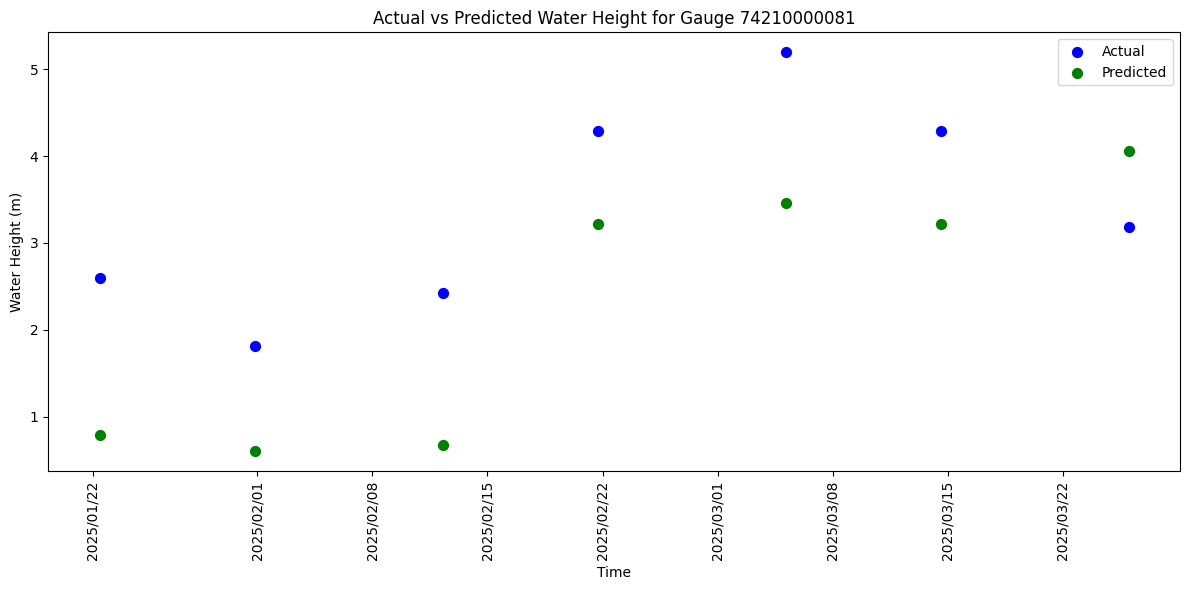

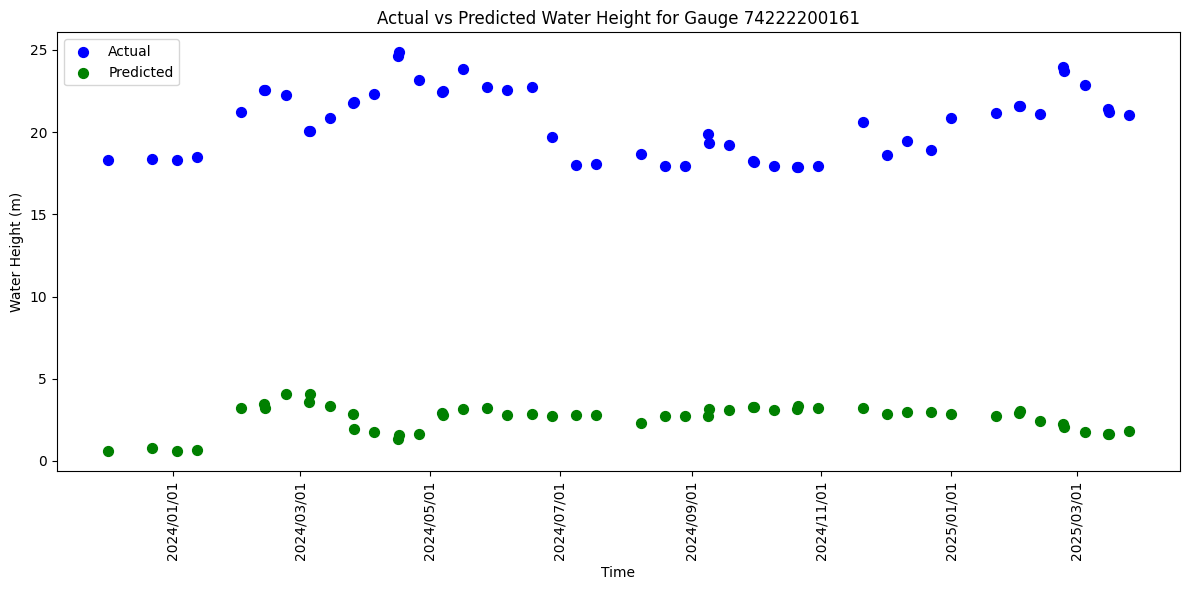

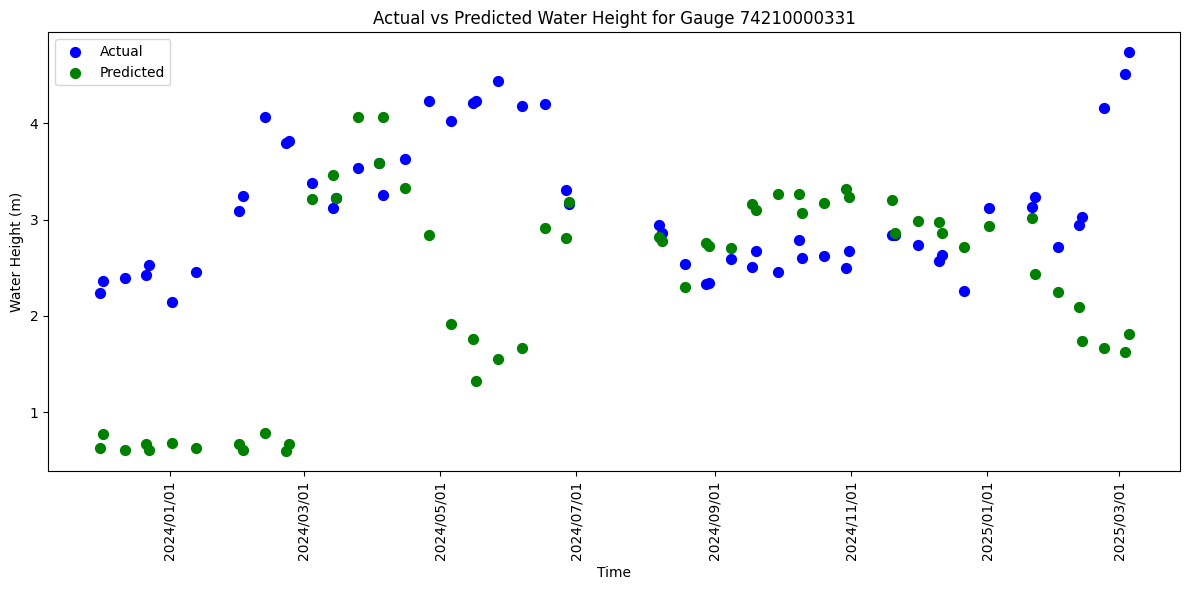

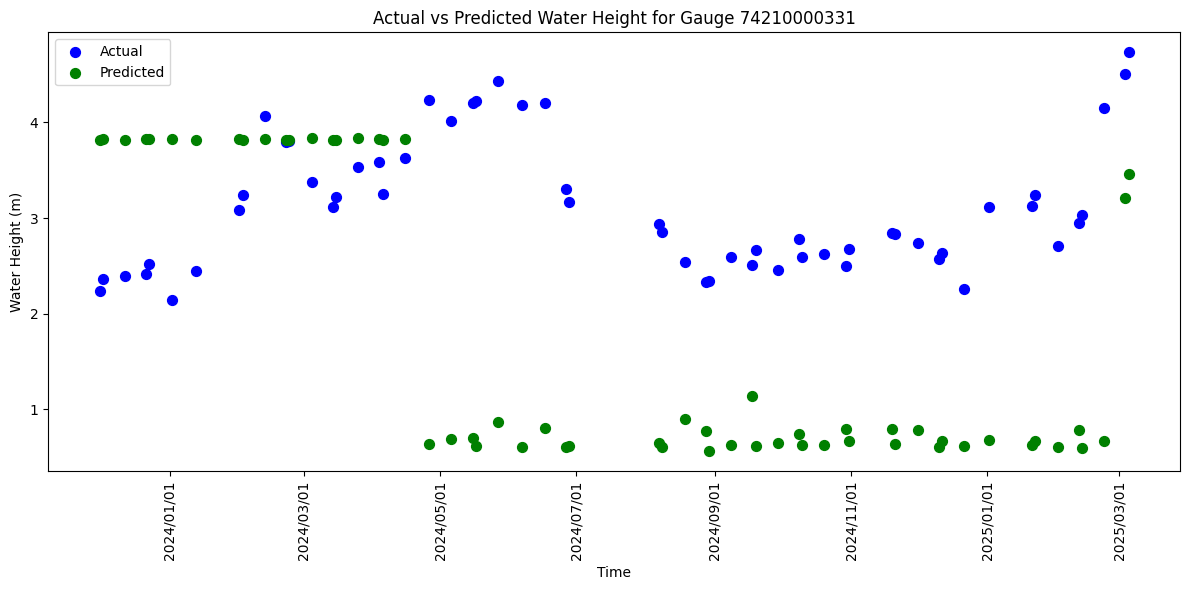

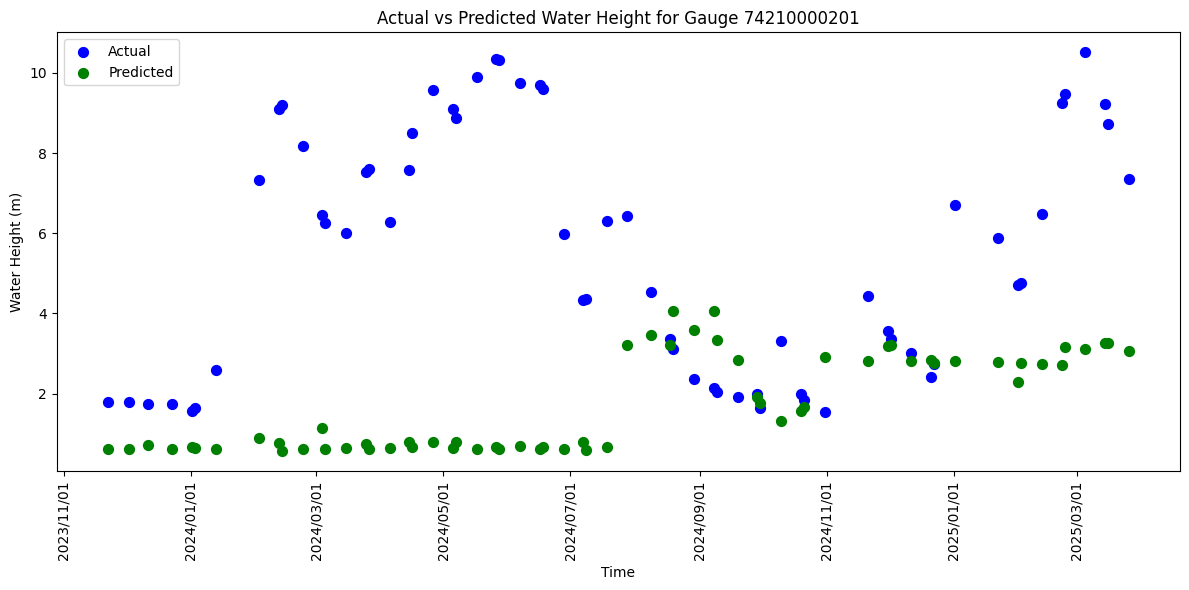

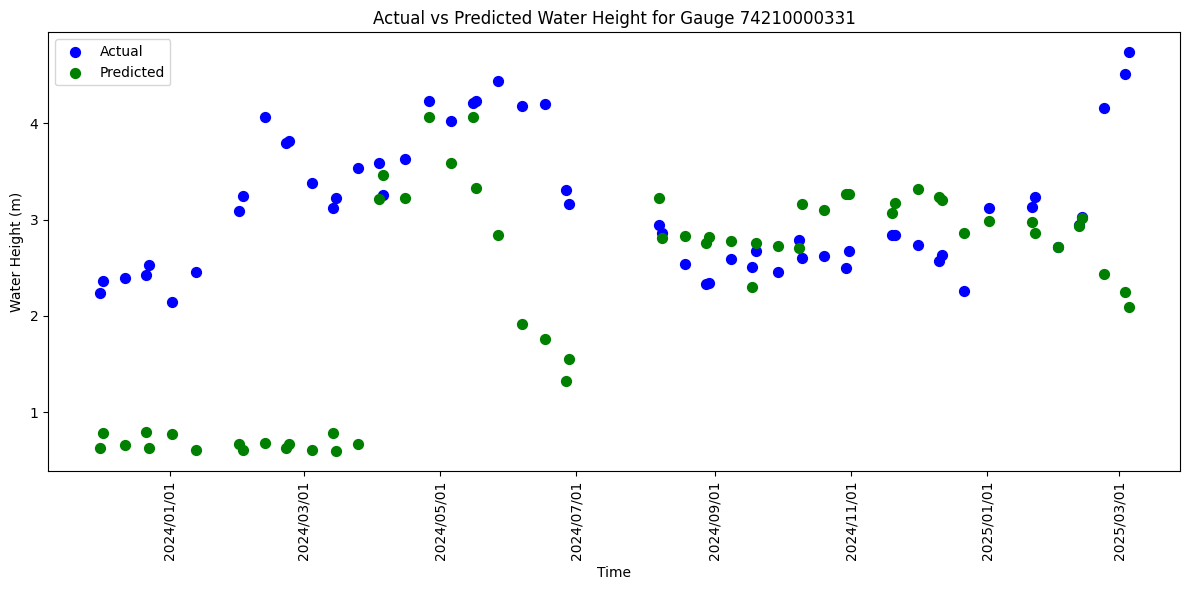

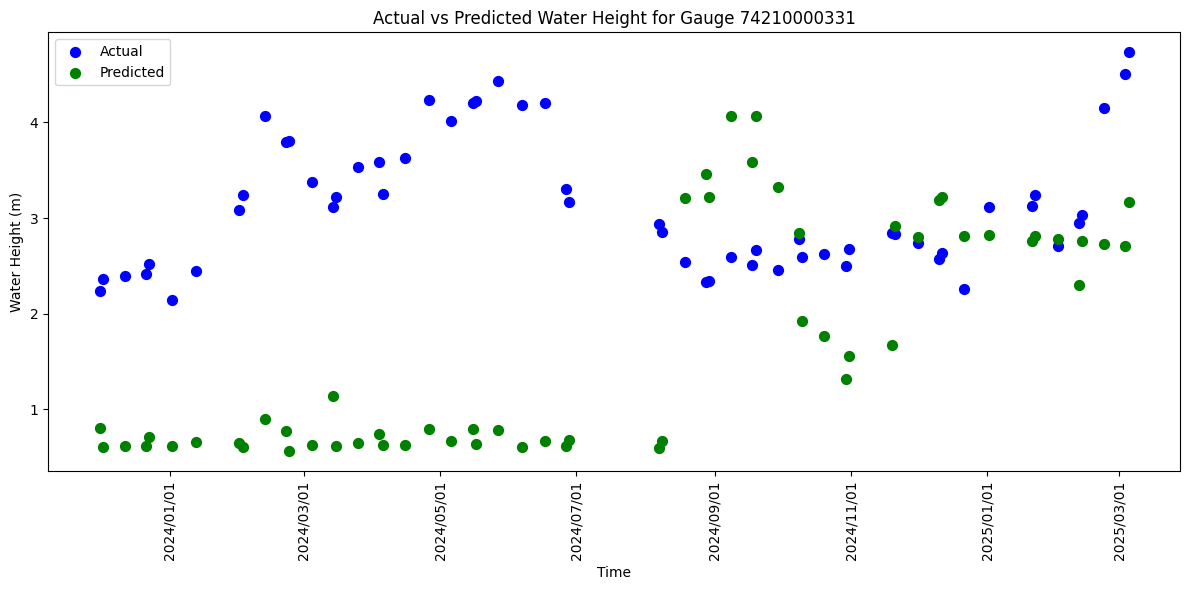

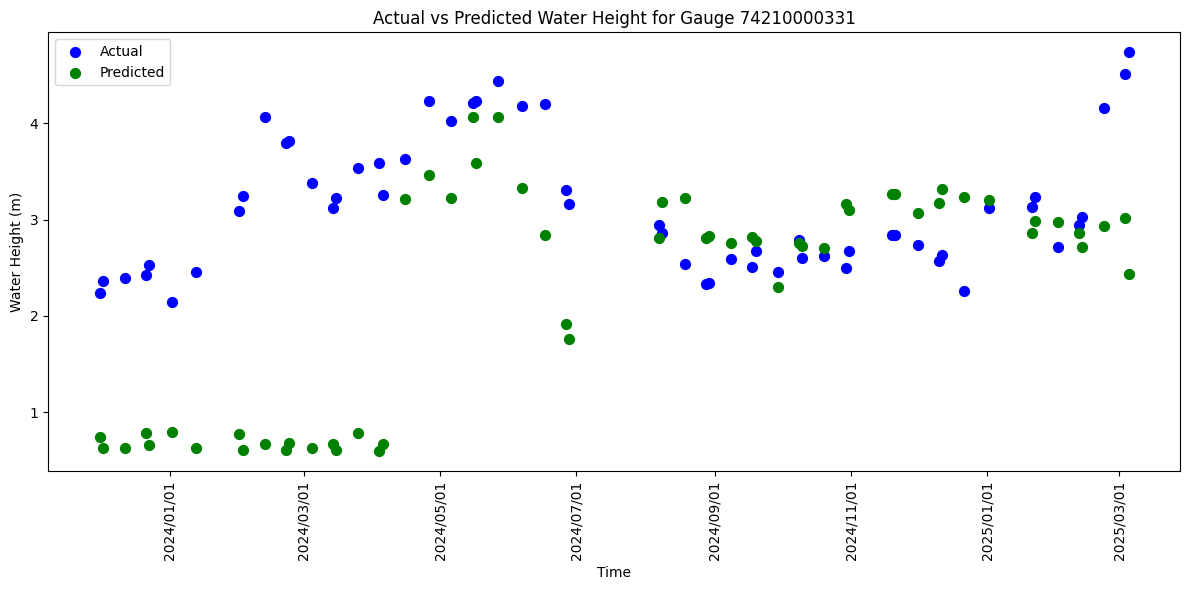

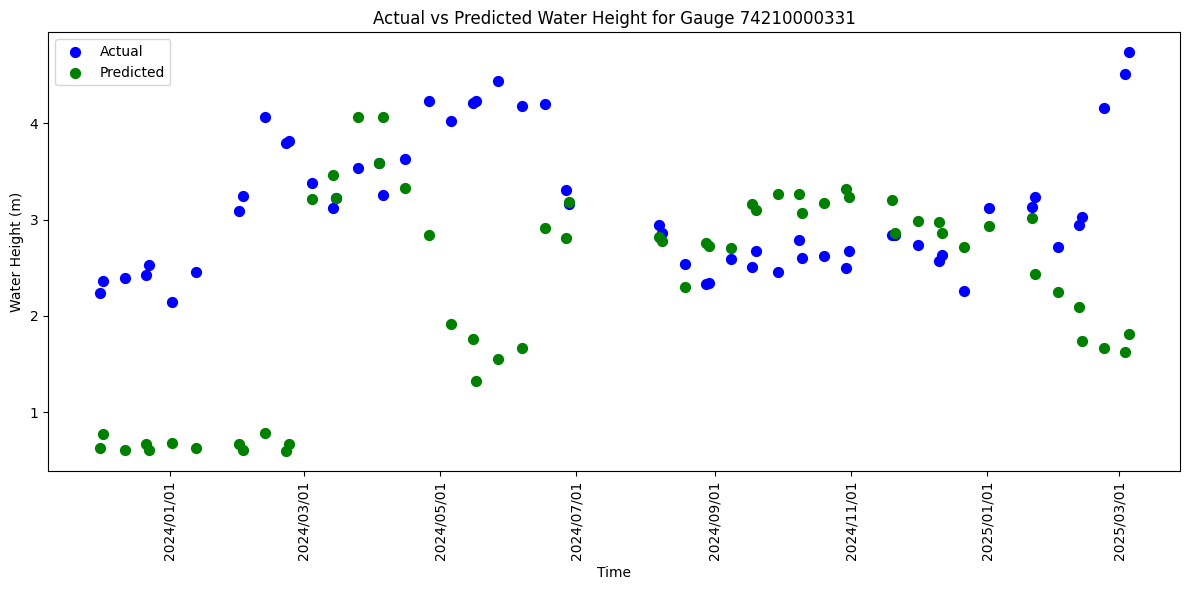

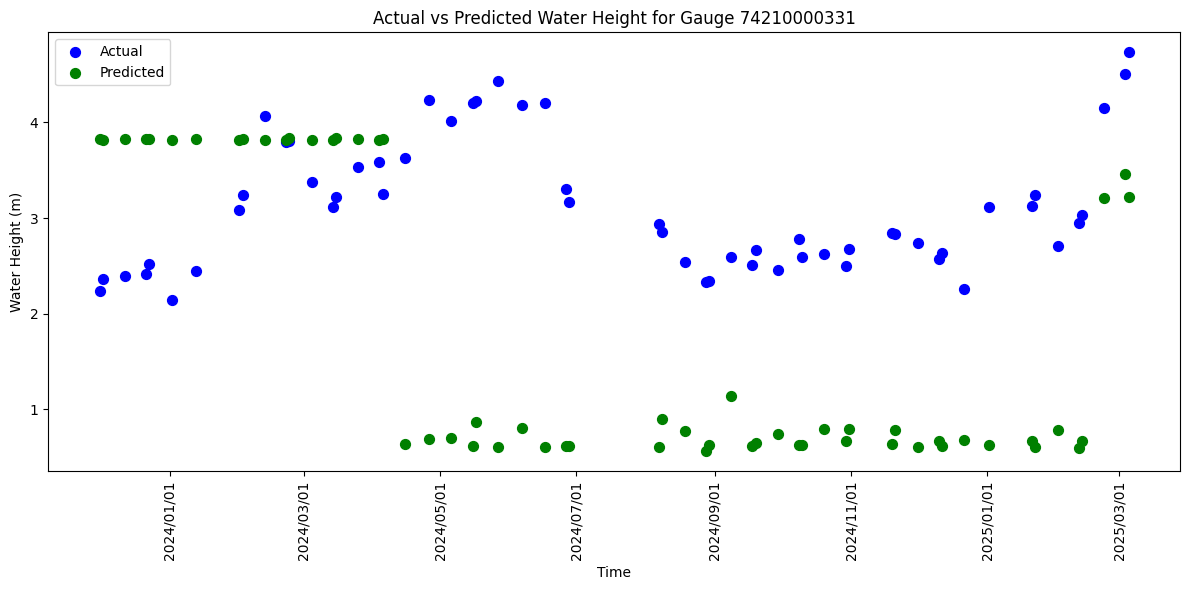

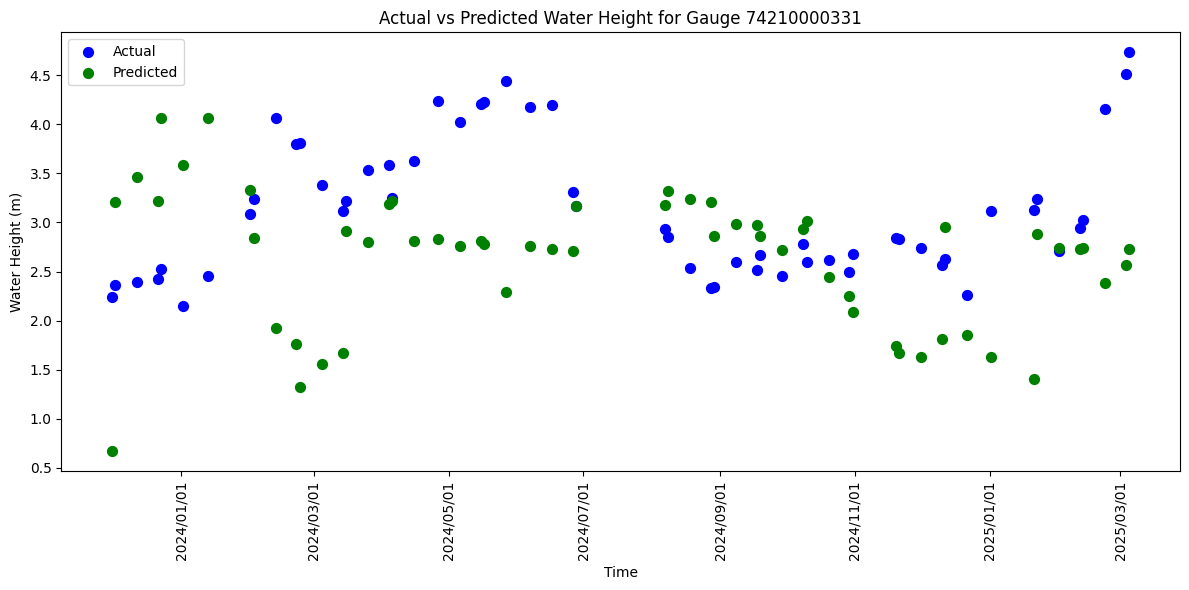

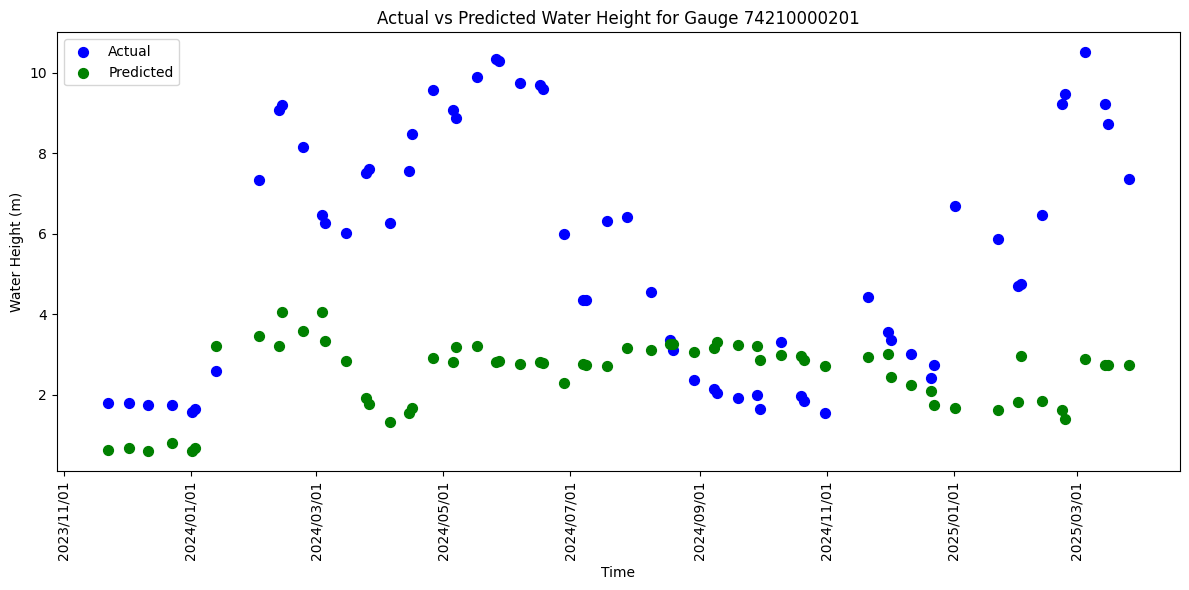

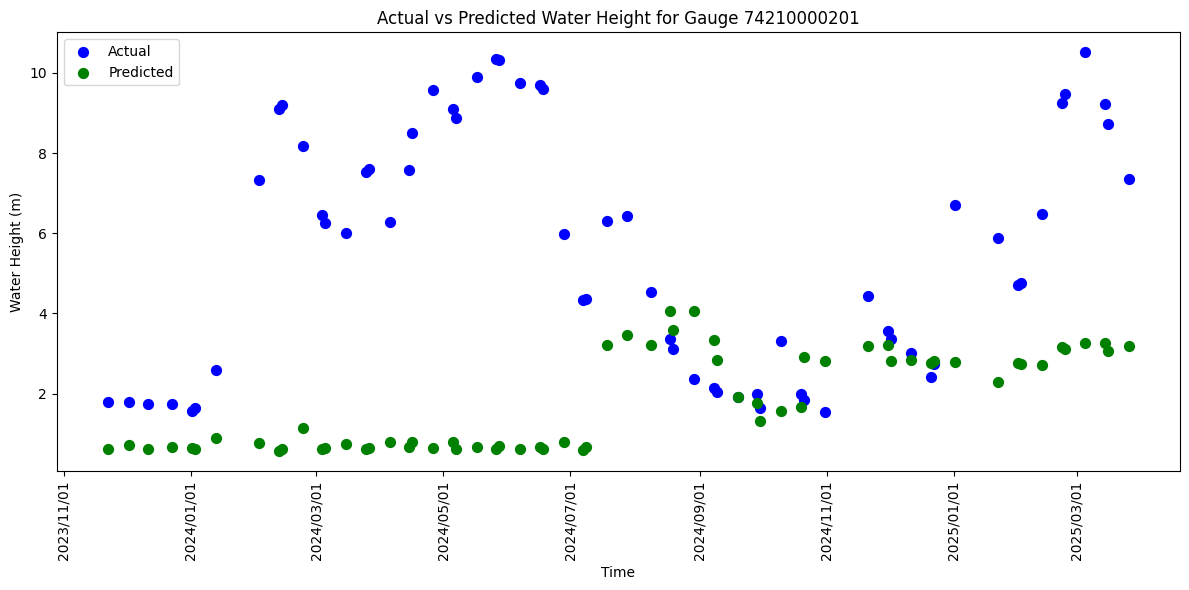

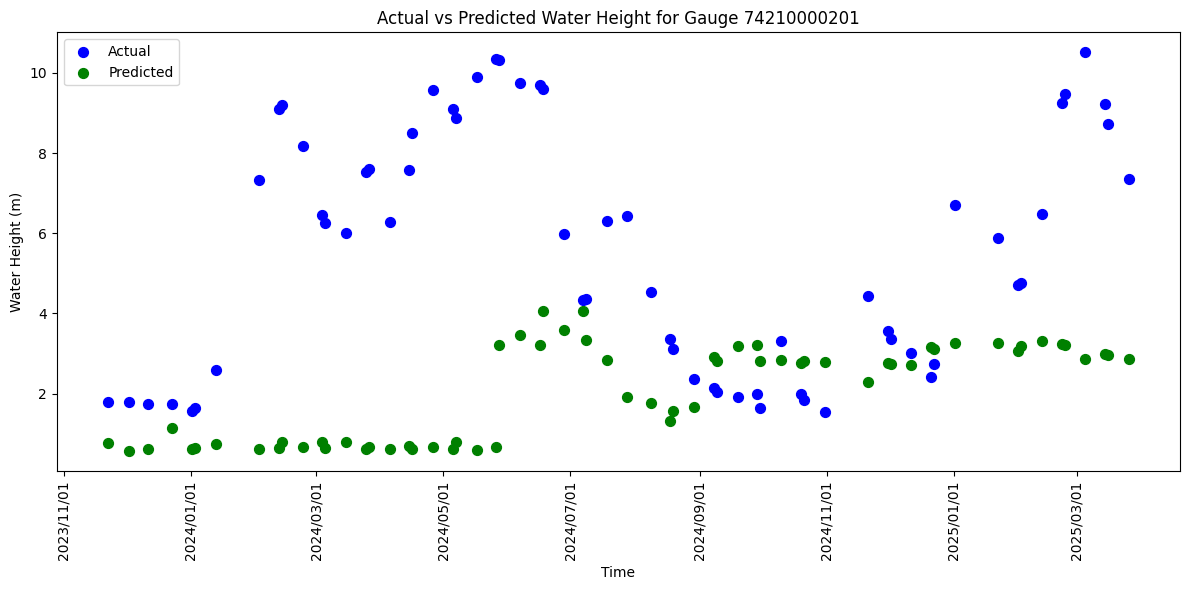

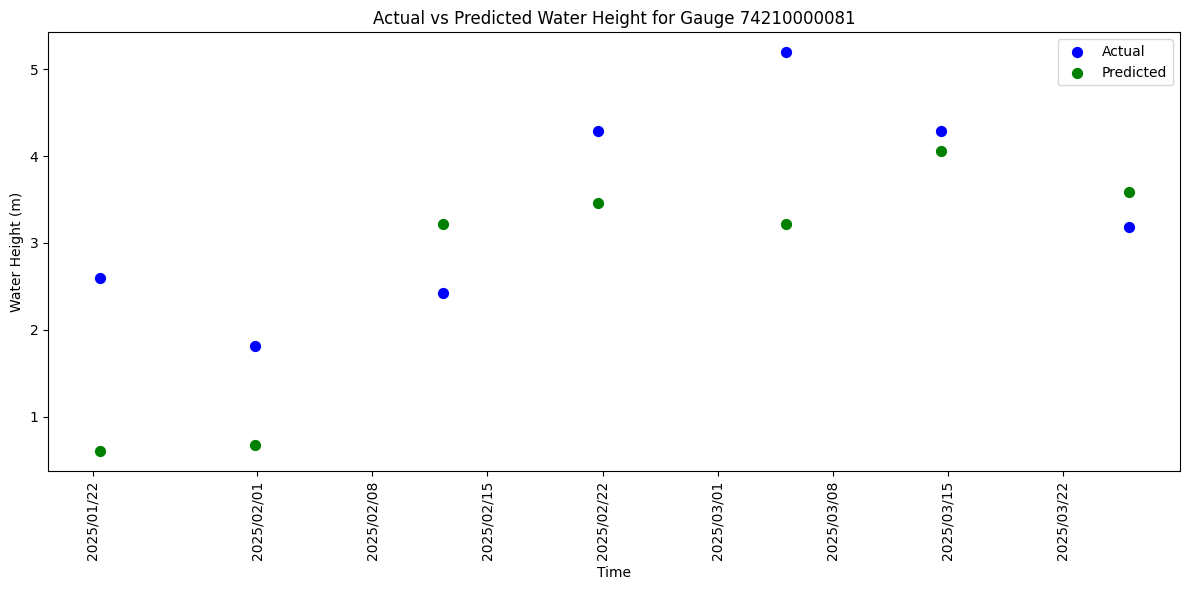

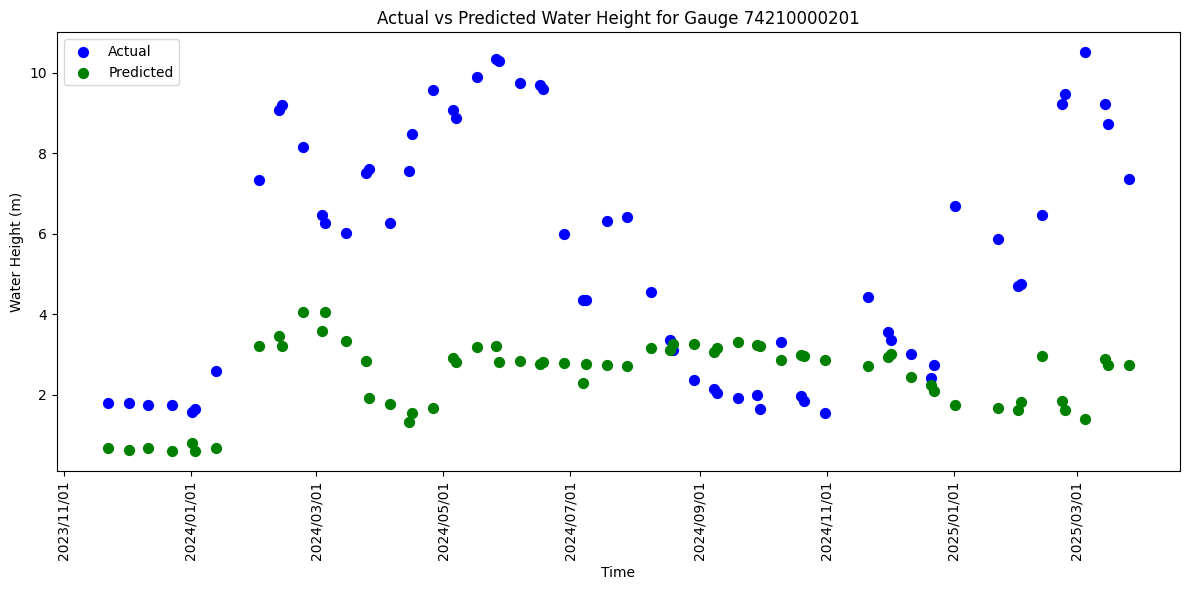

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import numpy as np
import pandas as pd

# Ensure datetime column is correctly parsed
test_data['datetime'] = pd.to_datetime(test_data['datetime'])

random_list = [random.randint(0, len(np.unique(test_data['swot_reach_id'])) - 1) for _ in range(30)]

for i in random_list:
    sample_gauge = test_data['swot_reach_id'].iloc[i]
    gauge_data = test_data[test_data['swot_reach_id'] == sample_gauge]
    gauge_indices = gauge_data.index

    plt.figure(figsize=(12, 6))
    plt.scatter(gauge_data['datetime'], gauge_data['usgs_height_m'], label='Actual', color='blue', s=50)
    plt.scatter(gauge_data['datetime'], y_pred_best[gauge_data.index - test_data.index[i]], label='Predicted', color='green', s=50)

    # Format x-axis for dates
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))
    plt.xticks(rotation=90)

    plt.xlabel('Time')
    plt.ylabel('Water Height (m)')
    plt.title(f'Actual vs Predicted Water Height for Gauge {sample_gauge}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    #plt.savefig(f'time_series_plot_{sample_gauge}.png')
    plt.close()



=== Dropped 477 rows with missing swot_height_m ===
Remaining rows: 11394

=== Statistical Summary ===
       usgs_height_m  swot_height_m         geoid           oht  \
count   10545.000000   11394.000000  11394.000000  11394.000000   
mean     -140.682266     215.472680    -27.355556    253.690434   
std      6635.895216     198.442582      1.081038    218.407345   
min   -304799.695000     -22.651900    -30.335830      1.858330   
25%         0.866000      36.836950    -28.178642     54.296936   
50%         1.743000     187.836200    -27.209359    230.907246   
75%         3.594000     379.264275    -26.597791    408.052047   
max        48.360000     950.281600    -21.451061   1092.648873   

       wse_corrected  terrain_elevation_m  swot_width_m  terrain_slope_deg  
count   11394.000000         11394.000000  11394.000000       11394.000000  
mean      -10.862198           226.694071    121.047459           8.309025  
std        39.077063           201.814393    176.882625      

KeyboardInterrupt: 

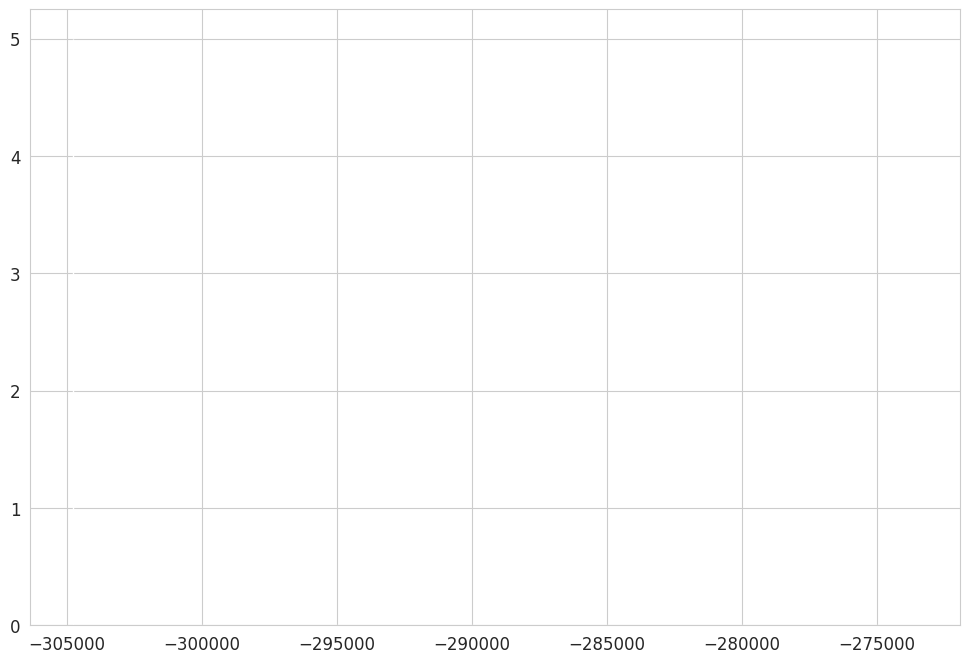

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Set plot style
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# Load the combined dataset
data_path = 'combined_data.csv'
data = pd.read_csv(data_path)

# Convert 'datetime' to datetime format
data['datetime'] = pd.to_datetime(data['datetime'])

# Drop rows where swot_height_m is missing
initial_rows = len(data)
data = data.dropna(subset=['swot_height_m'])


## DAM and Irreqular water height
DAM=['https://waterdata.usgs.gov/monitoring-location/07348000/',
    'https://waterdata.usgs.gov/monitoring-location/07347950/',
    'https://waterdata.usgs.gov/monitoring-location/07331290/',
    'https://waterdata.usgs.gov/monitoring-location/07185080/',
    'https://waterdata.usgs.gov/monitoring-location/08114100/']

data=data[~data['usgs_gage_link'].isin(DAM)]

rows_dropped = initial_rows - len(data)
print(f"\n=== Dropped {rows_dropped} rows with missing swot_height_m ===")
print(f"Remaining rows: {len(data)}")

# Define key numerical features based on your dataset
'''
geoid terrain_slope_deg
wse_corrected
eht -
swot_width_m
oht -
swot_height_m swot-terrain
terrain_elevation_m
deltah
'''


numerical_features = ['usgs_height_m', 'swot_height_m','geoid','oht' ,'wse_corrected','terrain_elevation_m', 'swot-terrain', 'deltah', 'swot_width_m', 'terrain_slope_deg']
# Update features based on actual columns
numerical_features = [col for col in numerical_features if col in data.columns]

# 1. Statistical Summary
print("\n=== Statistical Summary ===")
print(data[numerical_features].describe())

# 2. Missing Values
print("\n=== Missing Values ===")
missing_values = data[numerical_features + ['swot_reach_id', 'datetime']].isnull().sum()
print(missing_values[missing_values > 0])

# 3. Distribution Plots
print("\n=== Distribution Plots ===")
for col in numerical_features:
    plt.figure(figsize=(12, 8))
    sns.histplot(data[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.savefig(f'distribution_{col}.png')
    plt.close()

# Boxplots for outliers
plt.figure(figsize=(12, 8))
data[numerical_features].boxplot()
plt.title('Boxplots of Numerical Features')
plt.xticks(rotation=45)
plt.savefig('boxplots_numerical.png')
plt.close()

# 4. Correlation Analysis
print("\n=== Correlation Analysis ===")
correlation_matrix = data[numerical_features].corr()
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features',fontweight="bold", fontsize=16)
plt.savefig('correlation_heatmap.png')
plt.close()

# 5. Time Series Trends (Sample Gauges)
print("\n=== Time Series Trends ===")
sample_gauges = data['swot_reach_id'].unique()[:3]  # Plot for 3 gauges
for gauge in sample_gauges:
    gauge_data = data[data['swot_reach_id'] == gauge]
    plt.figure(figsize=(12, 6))
    plt.scatter(gauge_data['datetime'], gauge_data['usgs_height_m'], label='USGS Height', color='blue', s=50)
    plt.scatter(gauge_data['datetime'], gauge_data['swot_height_m'], label='SWOT Height', color='orange', s=50)
    plt.xlabel('Time')
    plt.ylabel('Height (m)')
    plt.title(f'Time Series for Gauge {gauge}')
    plt.legend()
    plt.savefig(f'time_series_gauge_{gauge}.png')
    plt.close()

# 6. Spatial Analysis (if latitude/longitude available)
if 'latitude' in data.columns and 'longitude' in data.columns:
    print("\n=== Spatial Distribution ===")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(x='longitude', y='latitude', size='usgs_height_m', hue='usgs_height_m', data=data, alpha=0.8,fontsize=24)
    plt.title('Spatial Distribution of Gauges',fontsize=24)
    plt.savefig('spatial_distribution.png')
    plt.close()

# 7. Test vs. Train Comparison
print("\n=== Test vs. Train Comparison ===")
# Recompute train/test split as per your previous code
data['cumcount'] = data.groupby('swot_reach_id').cumcount()
data['group_size'] = data.groupby('swot_reach_id')['cumcount'].transform('size')
data['train_size'] = (data['group_size'] * 0.7).astype(int)
data['is_train'] = data['cumcount'] < data['train_size']
train_data = data[data['is_train']]
test_data = data[~data['is_train']]

for col in numerical_features:
    plt.figure(figsize=(12, 8))
    sns.kdeplot(train_data[col].dropna(), label='Train', color='blue')
    sns.kdeplot(test_data[col].dropna(), label='Test', color='orange')
    plt.title(f'Distribution of {col}: Train vs. Test')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.savefig(f'train_test_distribution_{col}.png')
    plt.close()

print("\nEDA completed. Plots saved to current directory.")


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
import cartopy.io.shapereader as shpreader
import matplotlib.patheffects as path_effects


# 1. Aggregate & bin as before
df_avg = (
    data
    .groupby(['latitude','longitude'], as_index=False)
    .agg({'usgs_height_m':'mean'})
    .rename(columns={'usgs_height_m':'avg_height_m'})
)
bins = [0, 1, 5, 10, 20, 30, 50]
labels = ['0–1 m', '1–5 m', '5–10 m', '10–20 m', '20–30 m', '30–50 m']
df_avg['height_bin'] = pd.cut(df_avg['avg_height_m'], bins=bins, labels=labels, include_lowest=True)
size_mapping = {'0–1 m':50,'1–5 m':100,'5–10 m':200,'10–20 m':300,'20–30 m':400,'30–50 m':500}
palette = sns.color_palette("viridis", n_colors=len(labels))
color_mapping = dict(zip(labels, palette))

# 2. Load U.S. states shapefile
shp_path = shpreader.natural_earth(resolution='50m',
                                   category='cultural',
                                   name='admin_1_states_provinces')
states = gpd.read_file(shp_path)
us_states = states[states['admin'] == 'United States of America'].copy()

# 3. Filter to just Texas, Oklahoma, and Louisiana
desired = ['Texas', 'Oklahoma', 'Louisiana']
us_states = us_states[us_states['name'].isin(desired)]

# 4. Compute a point for labeling (centroid)
#    For more reliable placement, consider using `representative_point()` instead of `centroid`.
us_states['label_point'] = us_states.geometry.representative_point()

# 5. Convert your averaged points into a GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    df_avg,
    geometry=gpd.points_from_xy(df_avg.longitude, df_avg.latitude),
    crs=us_states.crs
)

# 6. Plot
fig, ax = plt.subplots(figsize=(12, 10))
# a) only those three states
us_states.boundary.plot(ax=ax, linewidth=1, edgecolor='gray')


# c) add state name labels
for _, row in us_states.iterrows():
    x, y = row['label_point'].x, row['label_point'].y
    ax.text(
    x, y, row['name'],
    horizontalalignment='center',
    fontsize=16,
    color='black',
    path_effects=[path_effects.withStroke(linewidth=2, foreground="white")]
)

# b) your binned gauge points
sns.scatterplot(
    x='longitude',
    y='latitude',
    hue='height_bin',
    size='height_bin',
    sizes=size_mapping,
    palette=color_mapping,
    data=df_avg,
    alpha=0.8,
    legend='brief',
    ax=ax
)

# 7. Tidy the legend to show each bin once
handles, legend_labels = ax.get_legend_handles_labels()
unique = []
unique_handles = []
for h, l in zip(handles, legend_labels):
    if l in labels and l not in unique:
        unique.append(l)
        unique_handles.append(h)
ax.legend(unique_handles, unique,
          title='Avg Height Bin',
          fontsize=12, title_fontsize=14,
          labelspacing=1.2,
          loc='upper right',
          frameon=True)

# 8. Final touches
ax.set_title('Spatial Distribution of Gauges (Avg USGS Height)', fontsize=24)
ax.set_xlabel('Longitude', fontsize=18)
ax.set_ylabel('Latitude', fontsize=18)
plt.tight_layout()
plt.savefig('spatial_distribution_TX_OK_LA_labeled.png', dpi=300)
plt.close()


In [ ]:
# 4. Correlation Analysis
print("\n=== Correlation Analysis ===")
correlation_matrix = data[numerical_features].corr()
plt.figure(figsize=(18, 16))  # Slightly larger figure to accommodate text
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1,
    annot_kws={"size": 16},  # Slightly smaller annotation size to fit
    fmt=".2f"  # Two decimal places for clarity
)
plt.title('Correlation Matrix of Numerical Features', fontweight="bold", fontsize=24, pad=15)  # Adjusted fontsize and padding
plt.xticks(fontsize=24, fontweight="bold", rotation=45, ha='right')  # Rotated x-axis labels to prevent overlap
plt.yticks(fontsize=24, fontweight="bold")  # Slightly smaller y-axis labels
plt.tight_layout()  # Adjusts spacing to prevent clipping
plt.savefig('correlation_heatmap.png', bbox_inches='tight')  # Ensure all elements are saved
plt.close()

In [55]:
import seaborn as sns
from IPython.display import display
# Assume gauges are identified by usgs_gage_link
if 'usgs_gage_link' in data.columns:
    gauge_errors = []
    for gauge in data['usgs_gage_link'].unique():
        mask = data['usgs_gage_link'] == gauge
        gauge_data = data[mask]
        X_gauge = gauge_data[features]
        y_gauge = gauge_data[target]
        if len(y_gauge) < 5:  # Skip small samples
            continue
        X_gauge_pre = preprocessor.transform(X_gauge)
        y_pred_gauge = rf.predict(X_gauge_pre)
        mae_gauge = mean_squared_error(y_gauge, y_pred_gauge)
        height_avg_gauge = gauge_data['swot_height_m'].mean()
        gauge_errors.append({'Gauge': gauge, 'MAE': mae_gauge, 'height_avg_gauge': height_avg_gauge})
    
    gauge_df = pd.DataFrame(gauge_errors)
    print("Gauge-Specific Performance:")
    display(gauge_df.sort_values(by='MAE'))

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='height_avg_gauge', y='MAE', size='MAE', hue='Gauge', data=gauge_df, legend=False)
    plt.title('Gauge-Specific MAE vs SWOT-USGS Correlation')
    plt.xlabel('SWOT-USGS Correlation')
    plt.ylabel('Prediction MAE')
    plt.tight_layout()
    plt.show()
else:
    print("No usgs_gage_link column found for gauge-specific analysis")


KeyError: "['swot-terrain'] not in index"

## Split by State (leave one out)

Unique states: ['Louisiana' 'Texas' 'Oklahoma']

Performing LOOCV for state: Louisiana
Epoch 1, Validation Loss: 1.8115
                Feature  Importance
23         swot-terrain    0.176058
14  terrain_elevation_m    0.158567
21           lake_depth    0.143805
17                  eht    0.133776
16                geoid    0.126477
18                  oht    0.091918
20         inv_distance    0.042897
0         swot_height_m    0.029630
19        wse_corrected    0.028584
15    terrain_slope_deg    0.028519
22            lake_area    0.015388
8           swot_slope2    0.008720
3          swot_width_m    0.002933
10      swot_n_good_nod    0.002570
4        swot_width_u_m    0.001988
5            swot_slope    0.001815
9        swot_dark_frac    0.001771
11       swot_reach_q_b    0.001343
13       swot_xtrk_dist    0.000720
6          swot_slope_u    0.000684
7        swot_slope_r_u    0.000565
1       swot_height_u_m    0.000487
2       swot_height_r_u    0.000413
12      swot_xov

/tmp/ipykernel_290/3308710819.py:149: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'state_{state}_best_model.pt'))


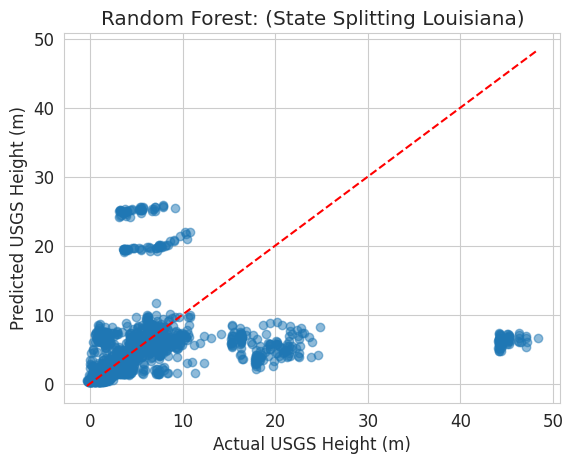


Performing LOOCV for state: Texas
Epoch 1, Validation Loss: 88.5436
                Feature  Importance
20         inv_distance    0.349107
16                geoid    0.279499
21           lake_depth    0.108898
17                  eht    0.054339
14  terrain_elevation_m    0.050191
18                  oht    0.033815
19        wse_corrected    0.029089
22            lake_area    0.026409
15    terrain_slope_deg    0.017080
0         swot_height_m    0.016717
8           swot_slope2    0.012835
23         swot-terrain    0.008893
9        swot_dark_frac    0.003955
5            swot_slope    0.002752
13       swot_xtrk_dist    0.001820
3          swot_width_m    0.001597
4        swot_width_u_m    0.000759
10      swot_n_good_nod    0.000638
2       swot_height_r_u    0.000433
11       swot_reach_q_b    0.000352
12      swot_xovr_cal_q    0.000217
6          swot_slope_u    0.000207
7        swot_slope_r_u    0.000207
1       swot_height_u_m    0.000191


/tmp/ipykernel_290/3308710819.py:149: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'state_{state}_best_model.pt'))


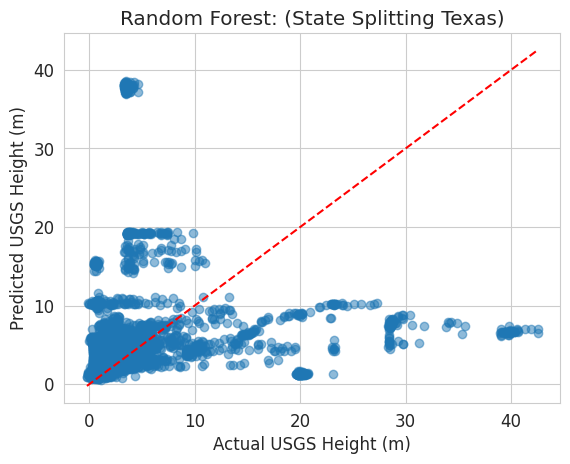


Performing LOOCV for state: Oklahoma
Epoch 1, Validation Loss: 76.1390
                Feature  Importance
14  terrain_elevation_m    0.249465
0         swot_height_m    0.164750
20         inv_distance    0.153471
15    terrain_slope_deg    0.112869
18                  oht    0.111602
21           lake_depth    0.091742
17                  eht    0.040950
23         swot-terrain    0.028326
16                geoid    0.013536
19        wse_corrected    0.010238
22            lake_area    0.010049
10      swot_n_good_nod    0.002211
3          swot_width_m    0.001939
8           swot_slope2    0.001709
11       swot_reach_q_b    0.001577
5            swot_slope    0.001486
13       swot_xtrk_dist    0.000951
9        swot_dark_frac    0.000786
7        swot_slope_r_u    0.000492
1       swot_height_u_m    0.000467
2       swot_height_r_u    0.000446
12      swot_xovr_cal_q    0.000382
6          swot_slope_u    0.000350
4        swot_width_u_m    0.000204


/tmp/ipykernel_290/3308710819.py:149: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'state_{state}_best_model.pt'))


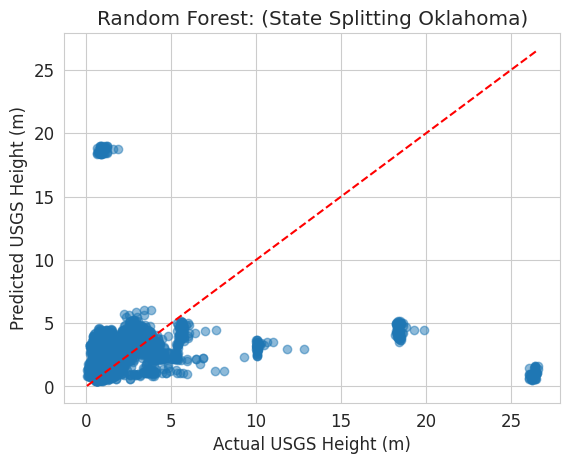


Average Model Performance Across States:
Linear Regression: MSE = 162290.1359, MAE = 7.8023, R² = -3490.4408
Random Forest: MSE = 65.5047, MAE = 3.9350, R² = -0.4636
Gradient Boosting: MSE = 57.6538, MAE = 3.9917, R² = -0.2406
Neural Network (PyTorch): MSE = 1263084.0153, MAE = 13.2933, R² = -27171.4386

State-Specific Model Performance:

State: Louisiana
Linear Regression: MSE = 83.8761, MAE = 5.4960, R² = -0.1020
Random Forest: MSE = 85.3490, MAE = 4.5620, R² = -0.1213
Gradient Boosting: MSE = 85.5720, MAE = 5.0116, R² = -0.1243
Neural Network (PyTorch): MSE = 80.5254, MAE = 5.5703, R² = -0.0580

State: Texas
Linear Regression: MSE = 486763.5757, MAE = 14.7883, R² = -10470.6260
Random Forest: MSE = 92.8525, MAE = 5.2073, R² = -0.9975
Gradient Boosting: MSE = 72.4242, MAE = 5.1051, R² = -0.5580
Neural Network (PyTorch): MSE = 3789156.1809, MAE = 32.4004, R² = -81514.1923

State: Oklahoma
Linear Regression: MSE = 22.9558, MAE = 3.1226, R² = -0.5945
Random Forest: MSE = 18.3127, MAE = 

In [90]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



# Get unique states from the 'state' column
unique_states = data['state'].unique()
print(f"Unique states: {unique_states}")

# Initialize a dictionary to store results for each state
state_results = {}

# Loop through each state for LOOCV
for state in unique_states:
    print(f"\nPerforming LOOCV for state: {state}")
    
    # Split data: train on all states except the current one, test on the current state
    train_data = data[data['state'] != state]
    test_data = data[data['state'] == state]
    
    # Prepare X and y
    X_train = train_data[features]
    y_train = train_data[target]
    X_test = test_data[features]
    y_test = test_data[target]
    
    # Apply preprocessing
    X_train_preprocessed = preprocessor.fit_transform(X_train)
    X_test_preprocessed = preprocessor.transform(X_test)
    
    # Convert to numpy arrays for PyTorch
    X_train_np = X_train_preprocessed
    X_test_np = X_test_preprocessed
    y_train_np = y_train.to_numpy()
    y_test_np = y_test.to_numpy()
    
    # Dictionary to store results for this state
    results = {}
    
    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train_preprocessed, y_train)
    y_pred_lr = lr.predict(X_test_preprocessed)
    results['Linear Regression'] = {
        'MSE': mean_squared_error(y_test, y_pred_lr),
        'MAE': mean_absolute_error(y_test, y_pred_lr),
        'R2': r2_score(y_test, y_pred_lr)
    }
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=20, random_state=42)
    rf.fit(X_train_preprocessed, y_train)
    y_pred_rf = rf.predict(X_test_preprocessed)
    results['Random Forest'] = {
        'MSE': mean_squared_error(y_test, y_pred_rf),
        'MAE': mean_absolute_error(y_test, y_pred_rf),
        'R2': r2_score(y_test, y_pred_rf)
    }
    
    # Gradient Boosting
    gb = GradientBoostingRegressor(n_estimators=20, random_state=42)
    gb.fit(X_train_preprocessed, y_train)
    y_pred_gb = gb.predict(X_test_preprocessed)
    results['Gradient Boosting'] = {
        'MSE': mean_squared_error(y_test, y_pred_gb),
        'MAE': mean_absolute_error(y_test, y_pred_gb),
        'R2': r2_score(y_test, y_pred_gb)
    }
    
    # PyTorch Neural Network
    # Define the Neural Network class (same as your original)
    class Net(nn.Module):
        def __init__(self, input_size):
            super(Net, self).__init__()
            self.fc1 = nn.Linear(input_size, 64)
            self.fc2 = nn.Linear(64, 32)
            self.fc3 = nn.Linear(32, 16)
            self.fc4 = nn.Linear(16, 1)
            self.relu = nn.ReLU()
            
        def forward(self, x):
            x = self.relu(self.fc1(x))
            x = self.relu(self.fc2(x))
            x = self.relu(self.fc3(x))
            x = self.fc4(x)
            return x
    
    # Convert data to tensors
    X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32).reshape(-1, 1)
    X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).reshape(-1, 1)
    
    # Create DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    # Initialize model, loss, optimizer
    model = Net(input_size=X_train_np.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training loop with early stopping
    epochs = 1  # Adjust as needed
    patience = 10
    best_val_loss = float('inf')
    patience_counter = 0
    val_split = 0.2
    n_val = int(len(X_train_tensor) * val_split)
    X_train_sub, X_val = X_train_tensor[n_val:], X_train_tensor[:n_val]
    y_train_sub, y_val = y_train_tensor[n_val:], y_train_tensor[:n_val]
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        
        # Validation loss
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
        
        print(f"Epoch {epoch+1}, Validation Loss: {val_loss.item():.4f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'state_{state}_best_model.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
    
    # Load best model
    model.load_state_dict(torch.load(f'state_{state}_best_model.pt'))
    model.eval()
    with torch.no_grad():
        y_pred_nn = model(X_test_tensor).numpy().flatten()
    results['Neural Network (PyTorch)'] = {
        'MSE': mean_squared_error(y_test_np, y_pred_nn),
        'MAE': mean_absolute_error(y_test_np, y_pred_nn),
        'R2': r2_score(y_test_np, y_pred_nn)
    }

    # Step 8: Feature importance and visualization
    num_feature_names = numerical_features
    #cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_feature_names = list(num_feature_names) 
    importances = rf.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    print(feature_importance_df.sort_values(by='Importance', ascending=False))
    plt.scatter(y_test, y_pred_rf, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual USGS Height (m)')
    plt.ylabel('Predicted USGS Height (m)')
    plt.title(f'Random Forest: (State Splitting {state})')
    plt.savefig('predictedVsactual_state.png')
    plt.show()
    # Store results for this state
    state_results[state] = results

# Analyze Results
# Average performance metrics across all states
average_results = {}
for model in ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Neural Network (PyTorch)']:
    average_results[model] = {
        'MSE': np.mean([state_results[state][model]['MSE'] for state in unique_states]),
        'MAE': np.mean([state_results[state][model]['MAE'] for state in unique_states]),
        'R2': np.mean([state_results[state][model]['R2'] for state in unique_states])
    }

# Display average results
print("\nAverage Model Performance Across States:")
for model, metrics in average_results.items():
    print(f"{model}: MSE = {metrics['MSE']:.4f}, MAE = {metrics['MAE']:.4f}, R² = {metrics['R2']:.4f}")

# Optional: Display state-specific results
print("\nState-Specific Model Performance:")
for state in unique_states:
    print(f"\nState: {state}")
    for model, metrics in state_results[state].items():
        print(f"{model}: MSE = {metrics['MSE']:.4f}, MAE = {metrics['MAE']:.4f}, R² = {metrics['R2']:.4f}")

                Feature  Importance
14  terrain_elevation_m    0.249465
0         swot_height_m    0.164750
20         inv_distance    0.153471
15    terrain_slope_deg    0.112869
18                  oht    0.111602
21           lake_depth    0.091742
17                  eht    0.040950
23         swot-terrain    0.028326
16                geoid    0.013536
19        wse_corrected    0.010238
22            lake_area    0.010049
10      swot_n_good_nod    0.002211
3          swot_width_m    0.001939
8           swot_slope2    0.001709
11       swot_reach_q_b    0.001577
5            swot_slope    0.001486
13       swot_xtrk_dist    0.000951
9        swot_dark_frac    0.000786
7        swot_slope_r_u    0.000492
1       swot_height_u_m    0.000467
2       swot_height_r_u    0.000446
12      swot_xovr_cal_q    0.000382
6          swot_slope_u    0.000350
4        swot_width_u_m    0.000204


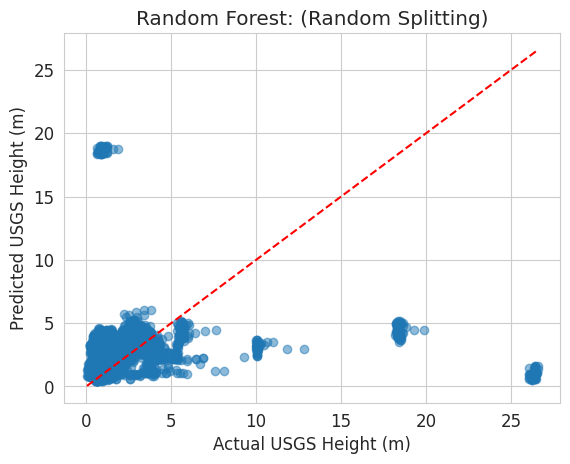

In [93]:

# Step 8: Feature importance and visualization
num_feature_names = numerical_features
#cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(num_feature_names) 
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
print(feature_importance_df.sort_values(by='Importance', ascending=False))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual USGS Height (m)')
plt.ylabel('Predicted USGS Height (m)')
plt.title('Random Forest: (Random Splitting)')
plt.savefig('predictedVsactual_random.png')
plt.show()



In [91]:
import pandas as pd
import numpy as np
import os
import pickle
import torch
from sklearn.compose import ColumnTransformer
from datetime import datetime

# Create directories for saving models and datasets
output_dir = 'experiment_results'
os.makedirs(os.path.join(output_dir, 'models'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'datasets'), exist_ok=True)

# Initialize global DataFrames to store results across all test setups
if 'performance_df' not in globals():
    performance_df = pd.DataFrame(columns=['split_type', 'fold', 'model', 'MSE', 'MAE', 'R2', 'model_path'])
if 'residuals_df' not in globals():
    residuals_df = pd.DataFrame(columns=['split_type', 'fold', 'residual', 'test_data_path'])
if 'feature_importance_df' not in globals():
    feature_importance_df = pd.DataFrame(columns=['split_type', 'fold', 'feature', 'importance'])


def save_results(split_type, results, X_train, X_test, y_train, y_test, y_pred_best, best_model_name, best_model, models, preprocessor, fold=None):
    """
    Save results, models, and train/test splits from a test setup.
    
    Parameters:
    - split_type: str, type of split ('random', 'river', 'time', 'state_loo')
    - results: dict, model performance metrics
    - X_train, X_test: DataFrame or array, raw train/test features
    - y_train, y_test: Series or array, train/test target
    - y_pred_best: array-like, predictions from the best model
    - best_model_name: str, name of the best model
    - best_model: trained model object
    - models: dict, all trained models {'model_name': model_object}
    - preprocessor: fitted ColumnTransformer object
    - fold: str or None, fold identifier (e.g., state name for state_loo)
    """
    global performance_df, residuals_df, feature_importance_df
    
    # Generate a timestamp for unique file naming
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # 1. Save train/test splits
    fold_str = f'_fold_{fold}' if fold else ''
    train_data_path = os.path.join(output_dir, 'datasets', f'{split_type}{fold_str}_train_{timestamp}.csv')
    test_data_path = os.path.join(output_dir, 'datasets', f'{split_type}{fold_str}_test_{timestamp}.csv')
    
    # Combine features and target into DataFrames
    train_df = pd.concat([pd.DataFrame(X_train, columns=X_train.columns), pd.Series(y_train, name='target')], axis=1)
    test_df = pd.concat([pd.DataFrame(X_test, columns=X_test.columns), pd.Series(y_test, name='target')], axis=1)
    
    # Save to CSV
    train_df.to_csv(train_data_path, index=False)
    test_df.to_csv(test_data_path, index=False)
    
    # 2. Save models
    model_paths = {}
    for model_name, model in models.items():
        model_filename = f'{split_type}{fold_str}_{model_name.replace(" ", "_")}_{timestamp}.pkl'
        model_path = os.path.join(output_dir, 'models', model_filename)
        
        if model_name == 'Neural Network (PyTorch)':
            # Save PyTorch model
            torch.save(model.state_dict(), model_path)
        else:
            # Save scikit-learn models
            with open(model_path, 'wb') as f:
                pickle.dump(model, f)
        model_paths[model_name] = model_path
    
    # 3. Save performance metrics
    perf_records = []
    for model, metrics in results.items():
        perf_records.append({
            'split_type': split_type,
            'fold': fold if split_type == 'state_loo' else None,
            'model': model,
            'MSE': metrics['MSE'],
            'MAE': metrics['MAE'],
            'R2': metrics['R2'],
            'model_path':None if model== 'Neural Network (PyTorch)' else model_paths[model]
        })
    performance_df = pd.concat([performance_df, pd.DataFrame(perf_records)], ignore_index=True)
    
    # 4. Save residuals for the best model
    residuals = y_test - y_pred_best
    res_df = pd.DataFrame({
        'split_type': split_type,
        'fold': fold if split_type == 'state_loo' else None,
        'residual': residuals,
        'test_data_path': test_data_path
    })

    
    residuals_df = pd.concat([residuals_df, res_df], ignore_index=True)
    
    # 5. Save feature importance for the best model
    # Get feature names from preprocessor
    numerical_features = preprocessor.transformers_[0][2]  # Assuming num features are first
    #categorical_transformer = preprocessor.named_transformers_['cat']
    #cat_feature_names = categorical_transformer.get_feature_names_out()
    all_feature_names = list(numerical_features) #+ list(cat_feature_names)
    
    if best_model_name in ['Random Forest', 'Gradient Boosting']:
        importances = best_model.feature_importances_
        fi_df = pd.DataFrame({
            'split_type': split_type,
            'fold': fold if split_type == 'state_loo' else None,
            'feature': all_feature_names,
            'importance': importances
        })
    elif best_model_name == 'Linear Regression':
        coefs = best_model.coef_
        fi_df = pd.DataFrame({
            'split_type': split_type,
            'fold': fold if split_type == 'state_loo' else None,
            'feature': all_feature_names,
            'importance': np.abs(coefs)  # Use absolute coefficients
        })
    elif best_model_name == 'Neural Network (PyTorch)':
        fi_df = pd.DataFrame({
            'split_type': split_type,
            'fold': fold if split_type == 'state_loo' else None,
            'feature': ['N/A'],
            'importance': [0]
        })
    else:
        fi_df = pd.DataFrame()
    
    if not fi_df.empty:
        feature_importance_df = pd.concat([feature_importance_df, fi_df], ignore_index=True)


# Example usage:
# For random, river, or time splits:
models = {'Linear Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}

save_results('state_loo', results, X_train, X_test, y_train, y_test, y_pred_best, best_model_name, best_model, models, preprocessor)


# For state_loo:
# for state in unique_states:
#     # Run training/testing
#     # Then call:
#     save_results('state_loo', results, X_train, X_test, y_train, y_test, y_pred_best, best_model_name, best_model, models, preprocessor, fold=state)

# Save all results to CSV files
def save_all_results_to_files():
    performance_df.to_csv(os.path.join(output_dir, 'performance_results.csv'), index=False)
    residuals_df.to_csv(os.path.join(output_dir, 'residuals_results.csv'), index=False)
    feature_importance_df.to_csv(os.path.join(output_dir, 'feature_importance_results.csv'), index=False)

# Call this at the end to save DataFrames
# save_all_results_to_files()

ValueError: operands could not be broadcast together with shapes (4046,) (2108,) 

In [92]:
residuals_df

,split_type,fold,residual,test_data_path
0,random,None,-0.02119,experiment_results/datasets/random_test_202504...
1,random,None,-0.32017,experiment_results/datasets/random_test_202504...
2,random,None,0.00691,experiment_results/datasets/random_test_202504...
3,random,None,0.07031,experiment_results/datasets/random_test_202504...
4,random,None,0.01463,experiment_results/datasets/random_test_202504...
...,...,...,...,...
19099,Time,None,-0.02950,experiment_results/datasets/Time_test_20250430...
19100,Time,None,-0.01020,experiment_results/datasets/Time_test_20250430...
19101,Time,None,-0.19835,experiment_results/datasets/Time_test_20250430...
19102,Time,None,-0.07130,experiment_results/datasets/Time_test_20250430...



Best model (lowest MAE): Gradient Boosting
Percentage of test cases error under 20 cm (SWOT nominal accuracy) is 9.24%


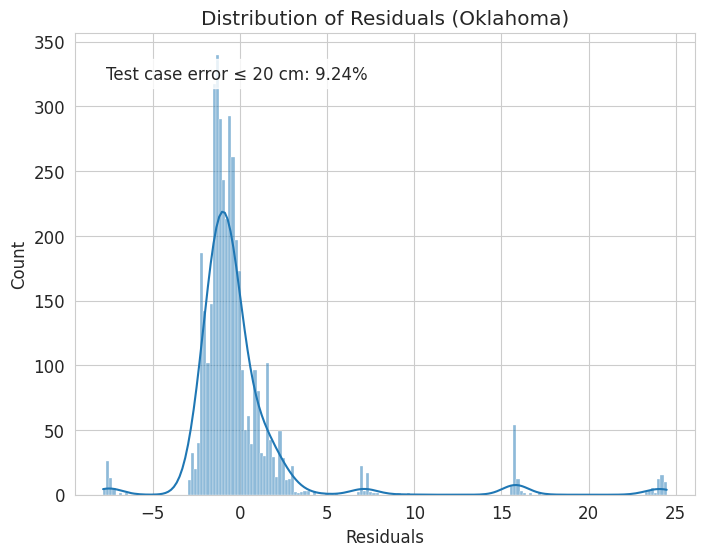

In [99]:
# Best model (lowest MAE)
best_model_name = min(results, key=lambda x: results[x]['MAE'])
print(f"\nBest model (lowest MAE): {best_model_name}")
best_model = {'Linear Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}[best_model_name]
y_pred_best = {'Linear Regression': y_pred_lr, 'Random Forest': y_pred_rf, 'Gradient Boosting': y_pred_gb}[best_model_name]


# 3. Error Distribution
residuals = y_test - y_pred_best
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.title('Distribution of Residuals (Oklahoma)')

# Calculate percentage
error_percentage = round(100 * sum(abs(residuals) <= 0.2) / len(residuals), 2)

# Add text inside the graph (adjust x, y coordinates as needed)
plt.text(x=0.05, y=0.9, s=f'Test case error ≤ 20 cm: {error_percentage}%', 
         transform=plt.gca().transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

print(f'Percentage of test cases error under 20 cm (SWOT nominal accuracy) is {error_percentage}%')
plt.savefig('error_distribution.png')
plt.show()